熟悉了基础框架后，手头的数据也可以作为"敲门砖"，帮你理解一些更高级的概念：

动态因子组合：可以研究像FactorMoE这类框架的思想，它利用专家混合（MoE）和注意力机制，根据市场状态动态调整因子权重，这比静态打分更智能。

时间序列预测：将LSTM或简单的Transformer模型作为因子挖掘的"增强器"之一，看看它们从量价数据中提取的特征，能否为你的多因子模型提供增量信息。

统计套利 (配对交易)：你的数据包含多只股票，这为统计套利提供了可能。你可以对行业内或历史走势高度相关的两只股票，分析它们的价差是否具有均值回归的特性，从而设计多空策略

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from scipy.linalg import eigh
import itertools
import os
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False


# 1.1 原始数据采集
print("\n1.1 原始数据采集...")
df = pd.read_csv('../extracted_data/stk_100.csv')
print(f"原始数据形状: {df.shape}")
print(f"原始数据列名: {df.columns.tolist()}")
print(f"数据日期范围: {df['trade_date'].min()} 至 {df['trade_date'].max()}")
print(f"股票代码数量: {df['ts_code'].nunique()}")
print("\n数据前5行:")
print(df.head())



# 转换日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)


1.1 原始数据采集...
原始数据形状: (24678, 11)
原始数据列名: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount']
数据日期范围: 2024-01-02 至 2025-01-10
股票代码数量: 100

数据前5行:
     ts_code  trade_date  open  high   low  close  pre_close  change  pct_chg  \
0  000005.SZ  2024-01-02  1.08  1.12  1.08   1.12       1.07    0.05   4.6729   
1  000005.SZ  2024-01-03  1.17  1.18  1.13   1.14       1.12    0.02   1.7857   
2  000005.SZ  2024-01-04  1.13  1.18  1.12   1.17       1.14    0.03   2.6316   
3  000005.SZ  2024-01-05  1.16  1.17  1.11   1.11       1.17   -0.06  -5.1282   
4  000005.SZ  2024-01-08  1.09  1.10  1.05   1.07       1.11   -0.04  -3.6036   

         vol     amount  
0   63028.00   6967.071  
1  274455.55  31989.773  
2  189486.02  21868.559  
3  151984.57  17158.063  
4   99076.57  10704.465  


In [2]:
# 剔除ST股票（根据股票代码或名称，这里假设ts_code中包含ST标识）
# 实际中可能需要根据名称判断，这里我们通过pct_chg异常值辅助判断
st_mask = df['ts_code'].str.contains('ST|st', na=False)
if st_mask.any():
    df = df[~st_mask]
    print(f"剔除ST股票后数据量: {len(df)}")
else:
    print("未发现ST股票")

# 剔除涨跌停日 (涨跌幅超过9.9%为涨跌停)
if 'pct_chg' in df.columns:
    limit_mask = (df['pct_chg'] >= 9.9) | (df['pct_chg'] <= -9.5)
    df = df[~limit_mask]
    print(f"剔除涨跌停日后数据量: {len(df)}")

# 剔除成交量或成交额为0的停牌日
if 'volume' in df.columns and 'amount' in df.columns:
    zero_mask = (df['volume'] == 0) | (df['amount'] == 0)
    df = df[~zero_mask]
    print(f"剔除停牌日后数据量: {len(df)}")

print(f"清洗后数据形状: {df.shape}")

未发现ST股票
剔除涨跌停日后数据量: 23979
清洗后数据形状: (23979, 11)


In [3]:
# 1.3 基础衍生指标
print("\n1.3 计算基础衍生指标...")

def calculate_derived_indicators(group):
    group = group.sort_values('trade_date').copy()
    
    # 日收益率（使用前收盘价）
    if 'close' in group.columns and 'pre_close' in group.columns:
        group['daily_return'] = group['close'] / group['pre_close'] - 1
    elif 'close' in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    # 换手率（使用成交量变化率作为换手率代理）
    if 'vol' in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    # 振幅
    if 'high' in group.columns and 'low' in group.columns:
        if 'pre_close' in group.columns:
            group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
        else:
            group['amplitude'] = (group['high'] - group['low']) / group['close'].shift(1)
    
    # 成交额占比
    if 'amount' in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].sum()
    
    return group

# 方法1：使用循环保留 ts_code
print("使用循环方式计算基础衍生指标...")
unique_codes = df['ts_code'].unique().tolist()
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_derived_indicators(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)

print("基础衍生指标计算完成")
print(f"新增指标: daily_return, turnover_rate, amplitude, amount_ratio")

# 检查 ts_code 是否还在
print(f"\n'ts_code' 是否在列名中: {'ts_code' in df.columns}")
print(f"数据列名: {df.columns.tolist()}")


1.3 计算基础衍生指标...
使用循环方式计算基础衍生指标...
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
基础衍生指标计算完成
新增指标: daily_return, turnover_rate, amplitude, amount_ratio

'ts_code' 是否在列名中: True
数据列名: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 'pre_close', 'change', 'pct_chg', 'vol', 'amount', 'daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']


In [4]:
def fill_factor_values(series, fill_method='forward'):
    """
    根据不同因子特性填充缺失值
    fill_method: 'forward' - 前向填充, 'mean' - 均值填充, 
                 'zero' - 零填充, 'median' - 中位数填充, 'ffill_bfill' - 前后填充
    """
    if not isinstance(series, pd.Series):
        raise ValueError(f"Expected pandas Series, got {type(series)}")
    
    if fill_method == 'forward':
        return series.ffill()
    elif fill_method == 'mean':
        return series.fillna(series.mean())
    elif fill_method == 'zero':
        return series.fillna(0)
    elif fill_method == 'median':
        return series.fillna(series.median())
    elif fill_method == 'ffill_bfill':
        return series.ffill().bfill()
    else:
        return series

def calculate_technical_factors(group):
    """计算所有基础技术因子"""
    group = group.sort_values('trade_date').copy()
    
    # 计算基础衍生指标（如果不存在）
    if 'daily_return' not in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    if 'turnover_rate' not in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    if 'amplitude' not in group.columns:
        group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
    
    if 'amount_ratio' not in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].rolling(20).mean()
    
    factor_fill_methods = {}
    
    # ---------- 价格动量类因子 ----------
    def calc_rsi(data, period):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    for p in [6, 12, 24]:
        col = f'rsi_{p}'
        group[col] = calc_rsi(group['close'], p)
        factor_fill_methods[col] = 'forward'
    
    # MACD
    exp1 = group['close'].ewm(span=12, adjust=False).mean()
    exp2 = group['close'].ewm(span=26, adjust=False).mean()
    group['macd'] = exp1 - exp2
    group['macd_signal'] = group['macd'].ewm(span=9, adjust=False).mean()
    group['macd_hist'] = group['macd'] - group['macd_signal']
    factor_fill_methods['macd'] = 'forward'
    factor_fill_methods['macd_signal'] = 'forward'
    factor_fill_methods['macd_hist'] = 'forward'
    
    # MOM
    for p in [5, 10, 20]:
        col = f'mom_{p}'
        group[col] = group['close'] / group['close'].shift(p) - 1
        factor_fill_methods[col] = 'zero'
    
    # 均线偏离度
    for p in [5, 20, 60]:
        col = f'ma_dev_{p}'
        ma = group['close'].rolling(window=p).mean()
        group[col] = (group['close'] - ma) / ma
        factor_fill_methods[col] = 'forward'
    
    # ---------- 波动率类因子 ----------
    # ATR
    high_low = group['high'] - group['low']
    high_close = abs(group['high'] - group['close'].shift())
    low_close = abs(group['low'] - group['close'].shift())
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    group['atr_14'] = tr.rolling(window=14).mean()
    factor_fill_methods['atr_14'] = 'forward'
    
    # 历史波动率
    if 'daily_return' in group.columns:
        for p in [20, 60]:
            col = f'hist_vol_{p}'
            group[col] = group['daily_return'].rolling(window=p).std() * np.sqrt(252)
            factor_fill_methods[col] = 'forward'
    
    # 布林带宽度
    ma20 = group['close'].rolling(window=20).mean()
    std20 = group['close'].rolling(window=20).std()
    group['bollinger_band'] = (group['close'] - ma20) / (2 * std20)
    factor_fill_methods['bollinger_band'] = 'forward'
    
    # ---------- 成交量类因子 ----------
    for p in [5, 10]:
        col = f'vr_{p}'
        group[col] = group['vol'] / group['vol'].rolling(window=p).mean()
        factor_fill_methods[col] = 'forward'
    
    # OBV
    obv = np.zeros(len(group))
    for i in range(1, len(group)):
        if group['close'].iloc[i] > group['close'].iloc[i-1]:
            obv[i] = obv[i-1] + group['vol'].iloc[i]
        elif group['close'].iloc[i] < group['close'].iloc[i-1]:
            obv[i] = obv[i-1] - group['vol'].iloc[i]
        else:
            obv[i] = obv[i-1]
    group['obv'] = obv
    factor_fill_methods['obv'] = 'forward'
    
    # 量价相关系数
    group['volume_price_corr'] = group['vol'].rolling(window=20).corr(group['close'])
    factor_fill_methods['volume_price_corr'] = 'zero'
    
    # ---------- 价格形态类因子 ----------
    high_20 = group['high'].rolling(window=20).max()
    low_20 = group['low'].rolling(window=20).min()
    group['highest_lowest_pos'] = (group['close'] - low_20) / (high_20 - low_20)
    factor_fill_methods['highest_lowest_pos'] = 'forward'
    
    group['upper_shadow'] = (group['high'] - group[['open', 'close']].max(axis=1)) / (group['high'] - group['low'])
    group['lower_shadow'] = (group[['open', 'close']].min(axis=1) - group['low']) / (group['high'] - group['low'])
    factor_fill_methods['upper_shadow'] = 'forward'
    factor_fill_methods['lower_shadow'] = 'forward'
    
    group['body_ratio'] = abs(group['close'] - group['open']) / (group['high'] - group['low'])
    factor_fill_methods['body_ratio'] = 'forward'
    
    # ---------- 流动性类因子 ----------
    group['amihud'] = abs(group['daily_return']) / (group['amount'] * 1e6)
    factor_fill_methods['amihud'] = 'median'
    
    group['log_amount'] = np.log(group['amount'] + 1)
    factor_fill_methods['log_amount'] = 'forward'
    
    # 应用填充策略
    for col, method in factor_fill_methods.items():
        if col in group.columns:
            group[col] = group[col].replace([np.inf, -np.inf], np.nan)
            try:
                group[col] = fill_factor_values(group[col], method)
            except Exception as e:
                group[col] = group[col].ffill().fillna(0)
            if group[col].isna().any():
                group[col] = group[col].ffill().bfill().fillna(0)
    
    return group

print("\n计算基础技术因子...")
# 假设df已存在，这里使用try-except处理
try:
    if 'df' not in locals():
        print("请先加载数据到df变量")
        raise ValueError("df未定义")
except:
    print("请先加载数据")
    raise

unique_codes = df['ts_code'].unique().tolist()
print(f"共 {len(unique_codes)} 只股票")

df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_technical_factors(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print("✅ 基础技术因子计算完成")


计算基础技术因子...
共 100 只股票
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 基础技术因子计算完成


In [5]:


# 在合并自动挖掘因子之前，先保存基础因子列名
base_factor_columns_before_auto = [col for col in df.columns if col not in ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
                                                                           'vol', 'amount', 'pre_close', 'change', 'pct_chg', 
                                                                           'daily_return', 'turnover_rate', 'amplitude', 
                                                                           'amount_ratio']]
print(f"基础技术因子数量（合并自动挖掘前）: {len(base_factor_columns_before_auto)}")

# ==================== 2. 自动因子挖掘 ====================
print("\n" + "="*80)
print("2. 自动因子挖掘")
print("="*80)

def auto_factor_mining(df, lookback_periods=[5, 10, 20, 30, 60]):
    """
    自动挖掘技术因子 - 修复重复列名问题
    """
    print("开始自动挖掘技术因子...")
    
    # 创建一个字典来存储每个因子的值，按原始数据索引对齐
    auto_factors_df = pd.DataFrame(index=df.index)
    
    unique_codes = df['ts_code'].unique()
    print(f"处理 {len(unique_codes)} 只股票...")
    
    for idx, code in enumerate(unique_codes):
        if idx % 20 == 0:
            print(f"  处理进度: {idx}/{len(unique_codes)}")
        
        # 获取该股票的数据
        stock_mask = df['ts_code'] == code
        stock_indices = df[stock_mask].index
        stock_data = df.loc[stock_mask].copy()
        stock_data = stock_data.sort_values('trade_date').reset_index(drop=True)
        
        if len(stock_data) < 60:
            continue
        
        # 计算该股票的因子
        stock_factors = {}
        
        # 1. 价格比率因子
        for col in ['open', 'high', 'low', 'close']:
            if col in stock_data.columns:
                for p in lookback_periods:
                    stock_factors[f'{col}_ratio_{p}'] = stock_data[col] / stock_data[col].shift(p)
                    stock_factors[f'{col}_log_return_{p}'] = np.log(stock_data[col] / stock_data[col].shift(p) + 1e-6)
        
        # 2. 价格范围因子
        stock_factors['high_low_ratio'] = stock_data['high'] / stock_data['low']
        stock_factors['close_open_ratio'] = stock_data['close'] / stock_data['open']
        stock_factors['high_close_ratio'] = stock_data['high'] / stock_data['close']
        stock_factors['low_close_ratio'] = stock_data['low'] / stock_data['close']
        
        # 3. 移动平均及衍生因子
        for p in lookback_periods:
            ma = stock_data['close'].rolling(window=p).mean()
            stock_factors[f'ma_{p}'] = ma
            stock_factors[f'price_ma_ratio_{p}'] = stock_data['close'] / ma - 1
            
            ema = stock_data['close'].ewm(span=p, adjust=False).mean()
            stock_factors[f'price_ema_ratio_{p}'] = stock_data['close'] / ema - 1
            
            if p >= 20:
                ma_short = stock_data['close'].rolling(window=int(p/2)).mean()
                stock_factors[f'ma_cross_{p}'] = ma_short / ma - 1
            
            std = stock_data['close'].rolling(window=p).std()
            stock_factors[f'std_{p}'] = std
            stock_factors[f'std_ratio_{p}'] = std / (ma + 1e-6)
            
            returns = stock_data['close'].pct_change()
            stock_factors[f'volatility_{p}'] = returns.rolling(window=p).std() * np.sqrt(252)
            stock_factors[f'skew_{p}'] = returns.rolling(window=p).skew()
            stock_factors[f'kurtosis_{p}'] = returns.rolling(window=p).kurt()
            
            for q in [0.1, 0.25, 0.75, 0.9]:
                stock_factors[f'quantile_{q}_{p}'] = stock_data['close'].rolling(window=p).quantile(q)
                stock_factors[f'quantile_ratio_{q}_{p}'] = stock_data['close'] / (stock_factors[f'quantile_{q}_{p}'] + 1e-6) - 1
        
        # 4. 成交量相关因子
        for p in lookback_periods:
            vol_ma = stock_data['vol'].rolling(window=p).mean()
            stock_factors[f'volume_ma_{p}'] = vol_ma
            stock_factors[f'volume_ma_ratio_{p}'] = stock_data['vol'] / vol_ma - 1
            stock_factors[f'volume_std_{p}'] = stock_data['vol'].rolling(window=p).std()
            
            amount_ma = stock_data['amount'].rolling(window=p).mean()
            stock_factors[f'amount_ma_{p}'] = amount_ma
            stock_factors[f'amount_ma_ratio_{p}'] = stock_data['amount'] / amount_ma - 1
        
        # 5. 价格形态因子
        stock_factors['upper_shadow_auto'] = (stock_data['high'] - stock_data[['open', 'close']].max(axis=1)) / (stock_data['high'] - stock_data['low'] + 1e-6)
        stock_factors['lower_shadow_auto'] = (stock_data[['open', 'close']].min(axis=1) - stock_data['low']) / (stock_data['high'] - stock_data['low'] + 1e-6)
        stock_factors['body_ratio_auto'] = abs(stock_data['close'] - stock_data['open']) / (stock_data['high'] - stock_data['low'] + 1e-6)
        
        returns = stock_data['close'].pct_change()
        stock_factors['up_days'] = (returns > 0).rolling(window=10).sum()
        stock_factors['down_days'] = (returns < 0).rolling(window=10).sum()
        stock_factors['up_down_ratio'] = stock_factors['up_days'] / (stock_factors['down_days'] + 1e-6)
        
        stock_factors['new_high_20_auto'] = (stock_data['close'] == stock_data['close'].rolling(window=20).max()).astype(int)
        stock_factors['new_low_20_auto'] = (stock_data['close'] == stock_data['close'].rolling(window=20).min()).astype(int)
        
        # 6. 量价关系因子
        for p in [5, 10, 20]:
            stock_factors[f'vol_price_corr_{p}'] = stock_data['vol'].rolling(window=p).corr(stock_data['close'])
        
        # 将因子值放入与原始数据对齐的位置
        for factor_name, factor_values in stock_factors.items():
            if factor_name not in auto_factors_df.columns:
                auto_factors_df[factor_name] = np.nan
            auto_factors_df.loc[stock_indices, factor_name] = factor_values.values
    
    # 处理缺失值
    print("处理缺失值...")
    auto_factors_df = auto_factors_df.replace([np.inf, -np.inf], np.nan)
    auto_factors_df = auto_factors_df.ffill().bfill().fillna(0)
    
    print(f"自动挖掘因子数量: {auto_factors_df.shape[1]}")
    print(f"自动挖掘因子列名 (前20个): {auto_factors_df.columns[:20].tolist()}")
    
    return auto_factors_df

# 执行自动因子挖掘
print("\n执行自动因子挖掘...")
auto_factors_df = auto_factor_mining(df)

# 将自动挖掘的因子合并到原始数据（使用前缀 'auto_'）
print("\n将自动挖掘因子合并到主数据...")
auto_factor_names = []
for col in auto_factors_df.columns:
    new_col_name = f'auto_{col}'
    # 检查是否已存在该列，如果存在则添加后缀
    if new_col_name in df.columns:
        counter = 1
        while f'{new_col_name}_{counter}' in df.columns:
            counter += 1
        new_col_name = f'{new_col_name}_{counter}'
    df[new_col_name] = auto_factors_df[col].values
    auto_factor_names.append(new_col_name)

print(f"合并后数据形状: {df.shape}")

try:
    base_factor_columns = base_factor_columns_before_auto
except NameError:
    # 如果未定义，则从当前df中提取（排除基础列和自动挖掘列）
    base_cols = ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
                 'vol', 'amount', 'pre_close', 'change', 'pct_chg', 
                 'daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']
    base_factor_columns = [col for col in df.columns if col not in base_cols and not col.startswith('auto_')]
    print(f"从当前数据中提取基础因子: {len(base_factor_columns)}个")

# 自动挖掘因子
auto_factor_columns = auto_factor_names

# 所有因子 = 基础因子 + 自动挖掘因子（去重）
all_factor_columns = list(dict.fromkeys(base_factor_columns + auto_factor_columns))

print(f"\n基础技术因子（不含自动挖掘）: {len(base_factor_columns)}个")
print(f"自动挖掘因子: {len(auto_factor_columns)}个")
print(f"总因子数量: {len(all_factor_columns)}个")
print(f"总因子列名 (前30个): {all_factor_columns[:30]}")

# ==================== 3. 因子预处理 ====================
print("\n" + "="*80)
print("3. 因子预处理")
print("="*80)

# 确保没有重复列名
print("检查并移除重复列名...")
# 获取所有列名并去重
all_cols = df.columns.tolist()
unique_cols = list(dict.fromkeys(all_cols))
if len(all_cols) != len(unique_cols):
    print(f"发现重复列名，原列数: {len(all_cols)}，去重后列数: {len(unique_cols)}")
    df = df[unique_cols]

print("提取因子数据...")
factor_data = df[all_factor_columns].copy()

# 确保没有NaN和无穷值
print("处理缺失值和无穷值...")
factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
factor_data = factor_data.ffill().bfill().fillna(0)

# MAD去极值
def mad_winsorize(data, n_sigma=5):
    """MAD去极值 - 使用numpy实现"""
    if isinstance(data, pd.Series):
        values = data.values
    else:
        values = np.array(data)
    
    median = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - median))
    
    upper_bound = median + n_sigma * mad
    lower_bound = median - n_sigma * mad
    
    values_clipped = np.clip(values, lower_bound, upper_bound)
    
    if isinstance(data, pd.Series):
        return pd.Series(values_clipped, index=data.index)
    else:
        return values_clipped

print("进行MAD去极值处理...")
total_cols = len(all_factor_columns)
for idx, col in enumerate(all_factor_columns):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{total_cols}")
    factor_data[col] = mad_winsorize(factor_data[col])

print(f"MAD去极值完成，共处理 {total_cols} 个因子")

# Z-score标准化
print("进行Z-score标准化...")
scaler = StandardScaler()
factor_data_scaled = pd.DataFrame(scaler.fit_transform(factor_data), 
                                  columns=all_factor_columns, 
                                  index=factor_data.index)

print("Z-score标准化完成")

# 规模中性化（使用成交额对数作为规模代理变量）
print("进行规模中性化...")
log_amount = df['log_amount'].values.reshape(-1, 1)
factor_neutralized = pd.DataFrame(index=factor_data.index, columns=all_factor_columns)

print(f"开始规模中性化，共 {len(all_factor_columns)} 个因子...")
for idx, col in enumerate(all_factor_columns):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(all_factor_columns)}")
    try:
        reg = LinearRegression()
        reg.fit(log_amount, factor_data_scaled[col].values.reshape(-1, 1))
        residual = factor_data_scaled[col].values - reg.predict(log_amount).flatten()
        factor_neutralized[col] = residual
    except Exception as e:
        print(f"  处理 {col} 时出错: {e}")
        factor_neutralized[col] = factor_data_scaled[col].values

print("规模中性化完成")

# 将预处理后的因子合并回原始数据
print("将预处理后的因子合并回原始数据...")
for col in all_factor_columns:
    df[f'{col}_processed'] = factor_neutralized[col]

print(f"\n预处理后数据列数: {len(df.columns)}")

# 检查是否有缺失值
print("\n检查预处理后因子是否有缺失值...")
missing_check = factor_neutralized.isna().sum().sum()
if missing_check > 0:
    print(f"警告: 存在 {missing_check} 个缺失值，进行填充...")
    factor_neutralized = factor_neutralized.fillna(0)
    for col in all_factor_columns:
        df[f'{col}_processed'] = factor_neutralized[col]
else:
    print("✅ 所有因子无缺失值")

print("\n因子预处理完成")



基础技术因子数量（合并自动挖掘前）: 26

2. 自动因子挖掘

执行自动因子挖掘...
开始自动挖掘技术因子...
处理 100 只股票...
  处理进度: 0/100
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
处理缺失值...
自动挖掘因子数量: 163
自动挖掘因子列名 (前20个): ['open_ratio_5', 'open_log_return_5', 'open_ratio_10', 'open_log_return_10', 'open_ratio_20', 'open_log_return_20', 'open_ratio_30', 'open_log_return_30', 'open_ratio_60', 'open_log_return_60', 'high_ratio_5', 'high_log_return_5', 'high_ratio_10', 'high_log_return_10', 'high_ratio_20', 'high_log_return_20', 'high_ratio_30', 'high_log_return_30', 'high_ratio_60', 'high_log_return_60']

将自动挖掘因子合并到主数据...
合并后数据形状: (23979, 204)

基础技术因子（不含自动挖掘）: 26个
自动挖掘因子: 163个
总因子数量: 189个
总因子列名 (前30个): ['rsi_6', 'rsi_12', 'rsi_24', 'macd', 'macd_signal', 'macd_hist', 'mom_5', 'mom_10', 'mom_20', 'ma_dev_5', 'ma_dev_20', 'ma_dev_60', 'atr_14', 'hist_vol_20', 'hist_vol_60', 'bollinger_band', 'vr_5', 'vr_10', 'obv', 'volume_price_corr', 'highest_lowest_pos', 'upper_shadow', 'lower_shadow', 'body_ratio', 'amihud', 'log_amount


计算未来5日收益...
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 未来5日收益计算完成

5. IC/IR分析
待检验因子数量: 189
因子列名示例 (前10个): ['rsi_6_processed', 'rsi_12_processed', 'rsi_24_processed', 'macd_processed', 'macd_signal_processed', 'macd_hist_processed', 'mom_5_processed', 'mom_10_processed', 'mom_20_processed', 'ma_dev_5_processed']

检查因子数据质量...
  rsi_6_processed: NaN=0
  rsi_12_processed: NaN=0
  rsi_24_processed: NaN=0
  macd_processed: NaN=0
  macd_signal_processed: NaN=0

计算IC值...
  处理进度: 0/189
  处理进度: 50/189
  处理进度: 100/189
  处理进度: 150/189

📊 因子IC值排名 (Top 30):
                                   factor        ic    ic_abs       p_value  \
108          auto_volatility_20_processed  0.084388  0.084388  2.256018e-38   
14                  hist_vol_60_processed -0.073062  0.073062  3.658895e-29   
13                  hist_vol_20_processed  0.072586  0.072586  8.347747e-29   
110            auto_kurto

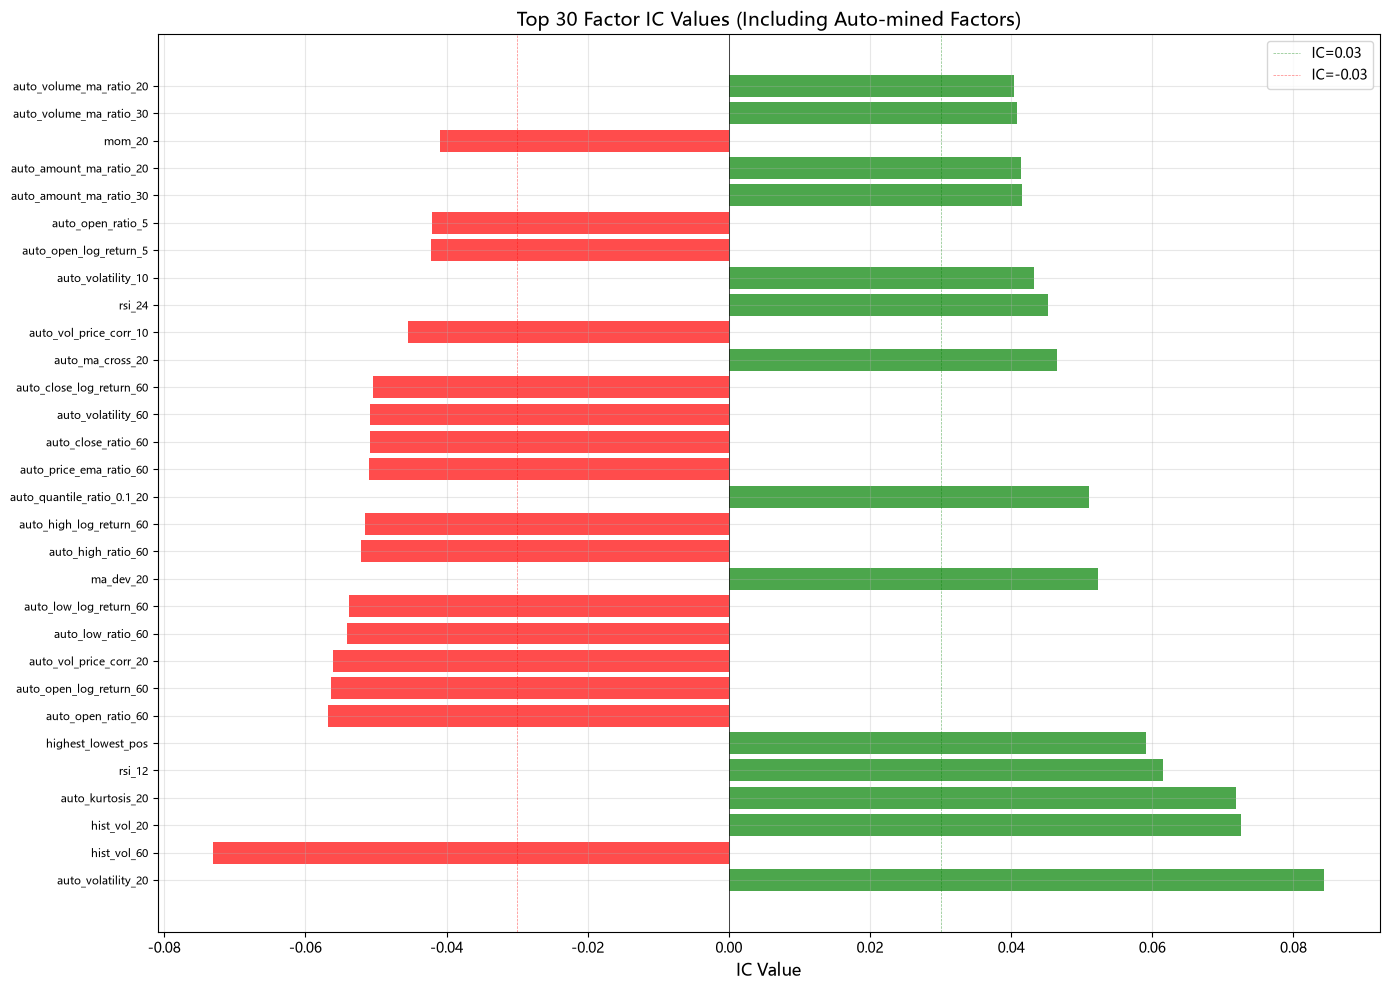

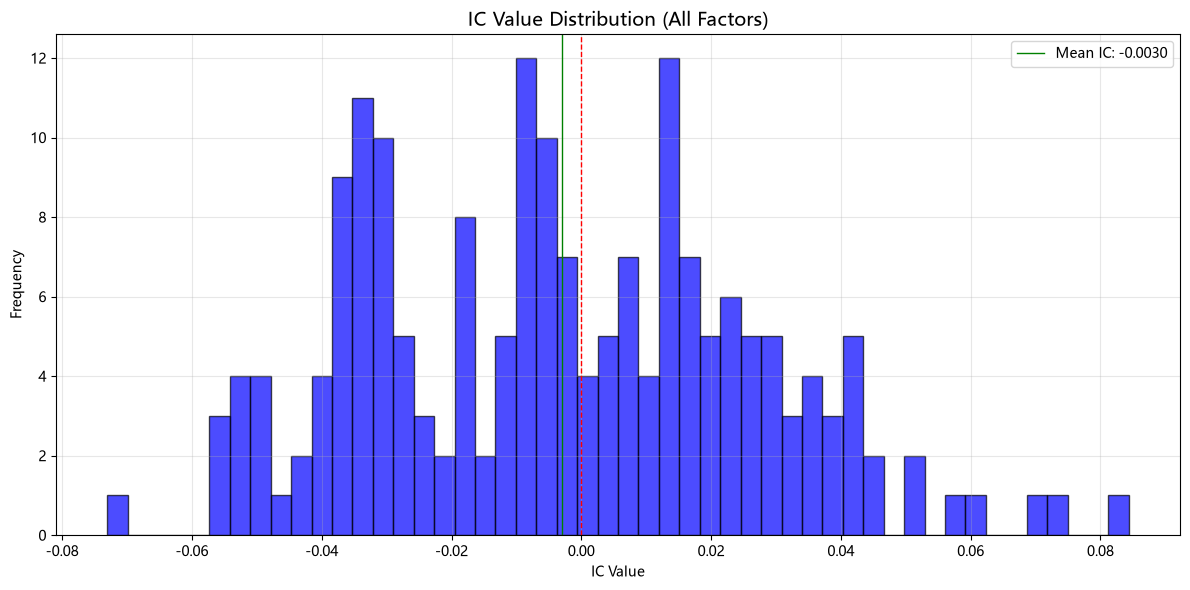


IC统计:
  IC > 0.03: 24 个因子
  IC < -0.03: 47 个因子
  IC均值: -0.0030
  IC标准差: 0.0300


In [6]:
# ==================== 4. 计算未来5日收益 ====================
def calculate_future_returns(group):
    group = group.sort_values('trade_date').copy()
    group['future_5d_return'] = group['close'].shift(-5) / group['close'] - 1
    return group

print("\n计算未来5日收益...")
unique_codes = df['ts_code'].unique().tolist()
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_future_returns(group)
    df_list.append(group)
df = pd.concat(df_list, ignore_index=True)
print("✅ 未来5日收益计算完成")

# ==================== 5. IC/IR分析 ====================
print("\n" + "="*80)
print("5. IC/IR分析")
print("="*80)

# 获取所有预处理后的因子列（包括自动挖掘的）
# 方法1：直接查找所有以 '_processed' 结尾的列
factor_cols_processed = [col for col in df.columns if col.endswith('_processed')]

# 方法2：或者从 all_factor_columns 构建
# factor_cols_processed = [f'{col}_processed' for col in all_factor_columns if f'{col}_processed' in df.columns]

print(f"待检验因子数量: {len(factor_cols_processed)}")
print(f"因子列名示例 (前10个): {factor_cols_processed[:10]}")

# 检查是否有缺失值
print("\n检查因子数据质量...")
for col in factor_cols_processed[:5]:
    nan_count = df[col].isna().sum()
    print(f"  {col}: NaN={nan_count}")

ic_results = []
print("\n计算IC值...")
for idx, col in enumerate(factor_cols_processed):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(factor_cols_processed)}")
    
    # 计算Spearman相关系数
    valid_data = df[[col, 'future_5d_return']].dropna()
    if len(valid_data) > 20:
        try:
            ic = stats.spearmanr(valid_data[col], valid_data['future_5d_return'])[0]
            if not np.isnan(ic):
                # 计算IC的p值
                p_value = stats.spearmanr(valid_data[col], valid_data['future_5d_return'])[1]
                ic_results.append({
                    'factor': col,
                    'ic': ic,
                    'ic_abs': abs(ic),
                    'p_value': p_value,
                    'n_obs': len(valid_data)
                })
        except Exception as e:
            print(f"  计算 {col} IC时出错: {e}")
            continue

if len(ic_results) > 0:
    ic_df = pd.DataFrame(ic_results).sort_values('ic_abs', ascending=False)
    print("\n📊 因子IC值排名 (Top 30):")
    print(ic_df.head(30))
    
    # # 保存完整IC结果到CSV
    # ic_df.to_csv(os.path.join(output_dir, 'factor_ic_analysis_full.csv'), index=False)
    # print(f"完整IC分析结果已保存到: {output_dir}/factor_ic_analysis_full.csv")
    
    # # 保存Top 20 IC结果
    # ic_df.head(20).to_csv(os.path.join(output_dir, 'factor_ic_analysis_top20.csv'), index=False)
    # print(f"Top 20 IC分析结果已保存到: {output_dir}/factor_ic_analysis_top20.csv")
    
    # 绘制IC值分布 - Top 30
    fig, ax = plt.subplots(figsize=(14, 10))
    top_ic = ic_df.head(30)
    colors = ['green' if x > 0 else 'red' for x in top_ic['ic']]
    
    # 简化因子名称显示
    factor_names = [f.replace('_processed', '')[:40] for f in top_ic['factor']]
    
    bars = ax.barh(range(len(top_ic)), top_ic['ic'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_ic)))
    ax.set_yticklabels(factor_names, fontsize=8)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=0.03, color='green', linestyle='--', linewidth=0.5, alpha=0.5, label='IC=0.03')
    ax.axvline(x=-0.03, color='red', linestyle='--', linewidth=0.5, alpha=0.5, label='IC=-0.03')
    ax.set_xlabel('IC Value', fontsize=12)
    ax.set_title('Top 30 Factor IC Values (Including Auto-mined Factors)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, 'factor_ic_values_top30.png'), dpi=300, bbox_inches='tight')
    plt.show()
    # print(f"因子IC值图已保存到: {output_dir}/factor_ic_values_top30.png")
    
    # 绘制IC值分布直方图
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.hist(ic_df['ic'], bins=50, alpha=0.7, color='blue', edgecolor='black')
    ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    ax.axvline(x=ic_df['ic'].mean(), color='green', linestyle='-', linewidth=1, label=f'Mean IC: {ic_df["ic"].mean():.4f}')
    ax.set_xlabel('IC Value')
    ax.set_ylabel('Frequency')
    ax.set_title('IC Value Distribution (All Factors)', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, 'ic_distribution_all_factors.png'), dpi=300, bbox_inches='tight')
    plt.show()
    # print(f"IC分布图已保存到: {output_dir}/ic_distribution_all_factors.png")
    
    # 统计IC>0.03的因子数量
    positive_ic_count = len(ic_df[ic_df['ic'] > 0.03])
    negative_ic_count = len(ic_df[ic_df['ic'] < -0.03])
    print(f"\nIC统计:")
    print(f"  IC > 0.03: {positive_ic_count} 个因子")
    print(f"  IC < -0.03: {negative_ic_count} 个因子")
    print(f"  IC均值: {ic_df['ic'].mean():.4f}")
    print(f"  IC标准差: {ic_df['ic'].std():.4f}")
    
else:
    print("❌ 没有有效的IC计算结果")
    ic_df = pd.DataFrame()


6. 分组单调性测试
测试因子单调性...
  处理进度: 0/50
  处理进度: 10/50
  处理进度: 20/50
  处理进度: 30/50
  处理进度: 40/50

📊 因子单调性测试结果 (Top 20):
                                  factor  monotonicity  is_monotonic        ic
4                       rsi_12_processed           1.0          True  0.061580
3             auto_kurtosis_20_processed           1.0          True  0.071792
11                   ma_dev_20_processed           1.0          True  0.052310
26     auto_amount_ma_ratio_20_processed           1.0          True  0.041358
29     auto_volume_ma_ratio_20_processed           1.0          True  0.040465
28     auto_volume_ma_ratio_30_processed           1.0          True  0.040870
43     auto_volume_ma_ratio_60_processed           1.0          True  0.036114
5           highest_lowest_pos_processed           0.9          True  0.059101
14  auto_quantile_ratio_0.1_20_processed           0.9          True  0.051076
34                      amihud_processed           0.9          True  0.039276
47            au

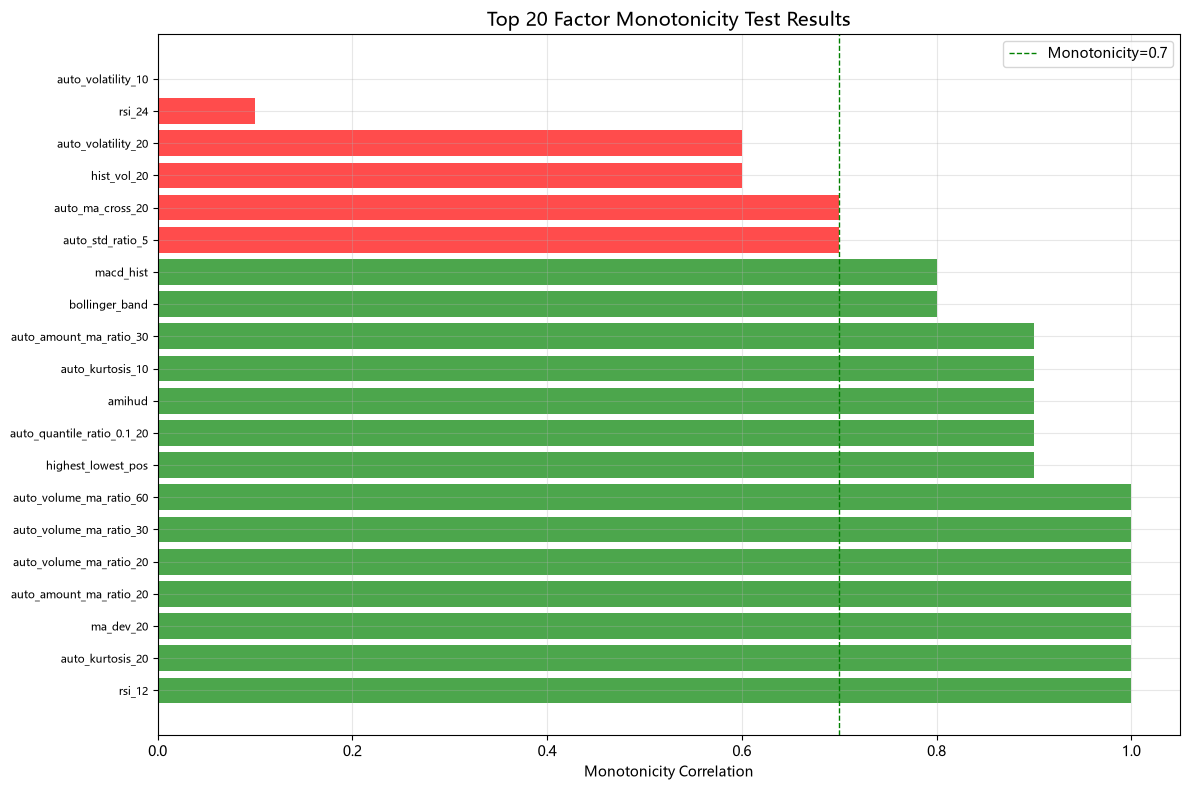


单调性统计:
  单调因子数量 (|monotonicity| > 0.7): 33
  单调性均值: -0.0860


In [7]:
# ==================== 6. 分组单调性测试 ====================
print("\n" + "="*80)
print("6. 分组单调性测试")
print("="*80)

def test_monotonicity(factor_col):
    """测试因子分组的单调性"""
    valid_data = df[[factor_col, 'future_5d_return']].dropna()
    if len(valid_data) < 50:
        return None
    
    try:
        # 分成5组
        valid_data['group'] = pd.qcut(valid_data[factor_col], q=5, labels=False, duplicates='drop')
        if len(valid_data['group'].unique()) < 3:
            return None
        group_returns = valid_data.groupby('group')['future_5d_return'].mean()
        
        # 检查是否单调（使用Spearman相关系数）
        if len(group_returns) >= 3:
            monotonic_corr = stats.spearmanr(range(len(group_returns)), group_returns.values)[0]
            return monotonic_corr
    except Exception as e:
        return None
    return None

monotonic_results = []
print("测试因子单调性...")
# 选择IC绝对值最高的前50个因子进行测试
test_factor_cols = ic_df.nlargest(50, 'ic_abs')['factor'].tolist() if len(ic_df) > 0 else factor_cols_processed[:50]

for idx, col in enumerate(test_factor_cols):
    if idx % 10 == 0:
        print(f"  处理进度: {idx}/{len(test_factor_cols)}")
    mono_corr = test_monotonicity(col)
    if mono_corr is not None and not np.isnan(mono_corr):
        # 获取对应的IC值
        ic_value = ic_df[ic_df['factor'] == col]['ic'].values[0] if len(ic_df) > 0 else np.nan
        monotonic_results.append({
            'factor': col,
            'monotonicity': mono_corr,
            'is_monotonic': abs(mono_corr) > 0.7,
            'ic': ic_value
        })

if len(monotonic_results) > 0:
    monotonic_df = pd.DataFrame(monotonic_results).sort_values('monotonicity', ascending=False)
    print("\n📊 因子单调性测试结果 (Top 20):")
    print(monotonic_df.head(20))
    
    # 保存单调性结果到CSV
    # monotonic_df.to_csv(os.path.join(output_dir, 'factor_monotonicity_full.csv'), index=False)
    # print(f"完整单调性测试结果已保存到: {output_dir}/factor_monotonicity_full.csv")
    
    # 绘制单调性结果
    fig, ax = plt.subplots(figsize=(12, 8))
    top_mono = monotonic_df.head(20)
    colors = ['green' if x else 'red' for x in top_mono['is_monotonic']]
    factor_names = [f.replace('_processed', '')[:40] for f in top_mono['factor']]
    
    bars = ax.barh(range(len(top_mono)), top_mono['monotonicity'], color=colors, alpha=0.7)
    ax.set_yticks(range(len(top_mono)))
    ax.set_yticklabels(factor_names, fontsize=8)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.axvline(x=0.7, color='green', linestyle='--', linewidth=1, label='Monotonicity=0.7')
    ax.set_xlabel('Monotonicity Correlation')
    ax.set_title('Top 20 Factor Monotonicity Test Results', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, 'factor_monotonicity_top20.png'), dpi=300, bbox_inches='tight')
    plt.show()
    # print(f"因子单调性图已保存到: {output_dir}/factor_monotonicity_top20.png")
    
    # 统计单调因子
    monotonic_count = len(monotonic_df[monotonic_df['is_monotonic']])
    print(f"\n单调性统计:")
    print(f"  单调因子数量 (|monotonicity| > 0.7): {monotonic_count}")
    print(f"  单调性均值: {monotonic_df['monotonicity'].mean():.4f}")
    
else:
    print("❌ 没有有效的单调性测试结果")


7. 因子综合筛选（IC + IR + 单调性 + 相关性）
计算因子综合指标...
  处理进度: 0/187
  处理进度: 20/187
  处理进度: 40/187
  处理进度: 60/187
  处理进度: 80/187
  处理进度: 100/187
  处理进度: 120/187
  处理进度: 140/187
  处理进度: 160/187
  处理进度: 180/187
覆盖率过滤后剩余: 187 个因子
IC绝对值过滤后剩余: 101 个因子

📊 因子综合评分排名 (Top 30):
                               factor        ic        ir  monotonicity  ic_win_rate  composite_score
3          auto_kurtosis_20_processed  0.071792  0.090900           1.0       0.4875         0.831081
1               hist_vol_60_processed -0.073062  0.017730          -0.9       0.6500         0.830226
0        auto_volatility_20_processed  0.084388  0.205274           0.6       0.5000         0.818452
2               hist_vol_20_processed  0.072586  0.180633           0.6       0.7625         0.807992
17       auto_volatility_60_processed -0.050866  0.107987          -0.9       0.6500         0.755590
31              auto_std_60_processed -0.039786  0.230801          -0.9       0.6750         0.732948
49        auto_amount_ma_30_

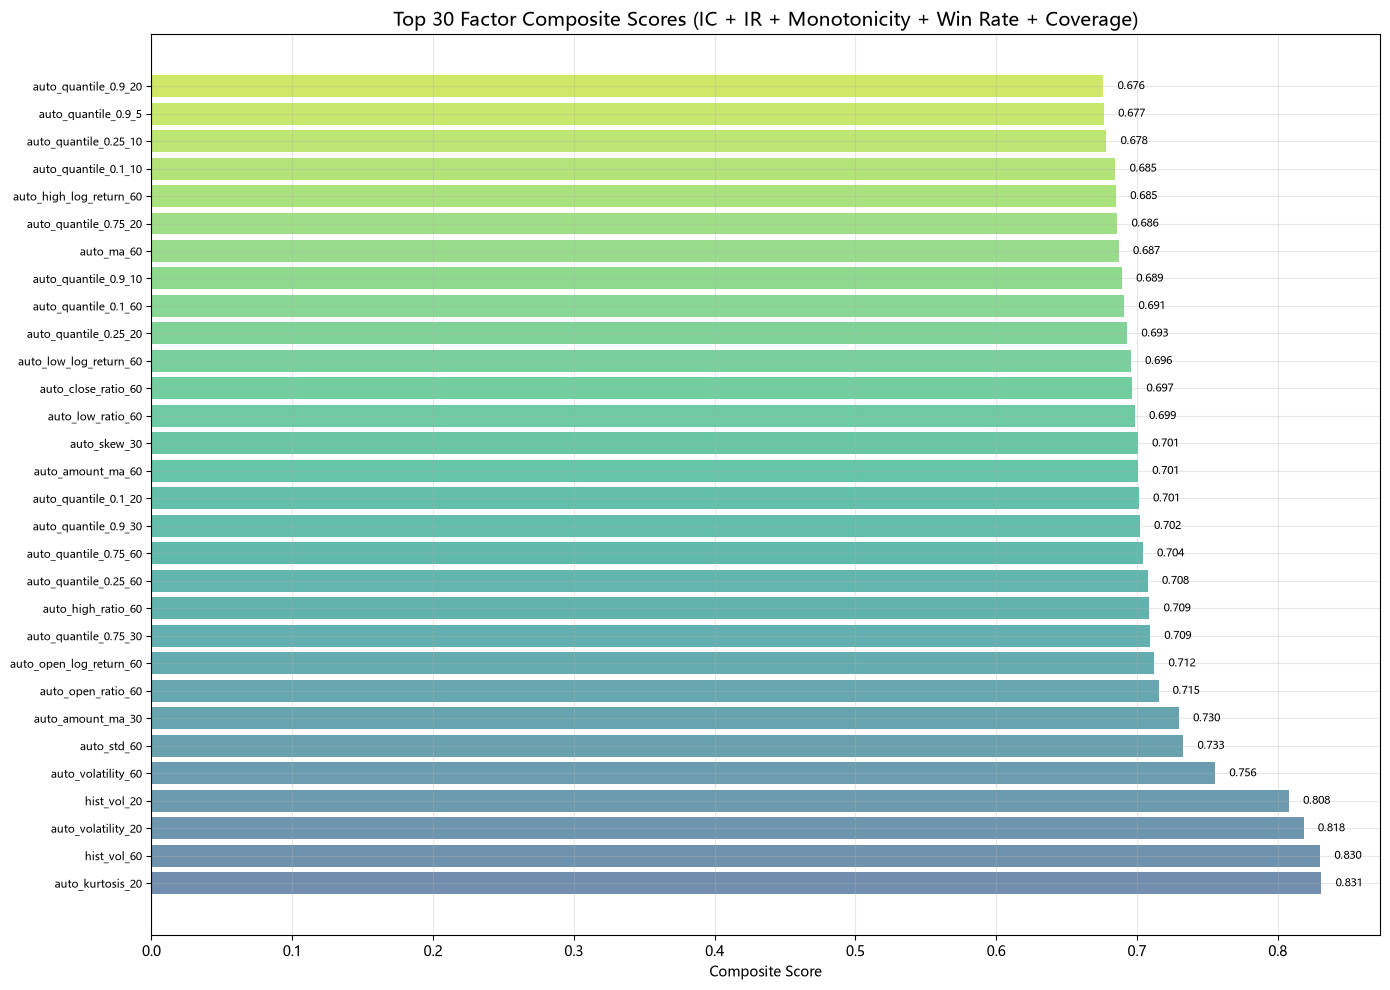


8. 选择Top因子并剔除相关性冗余

从综合评分前 50 个因子中选择，目标保留 25 个因子


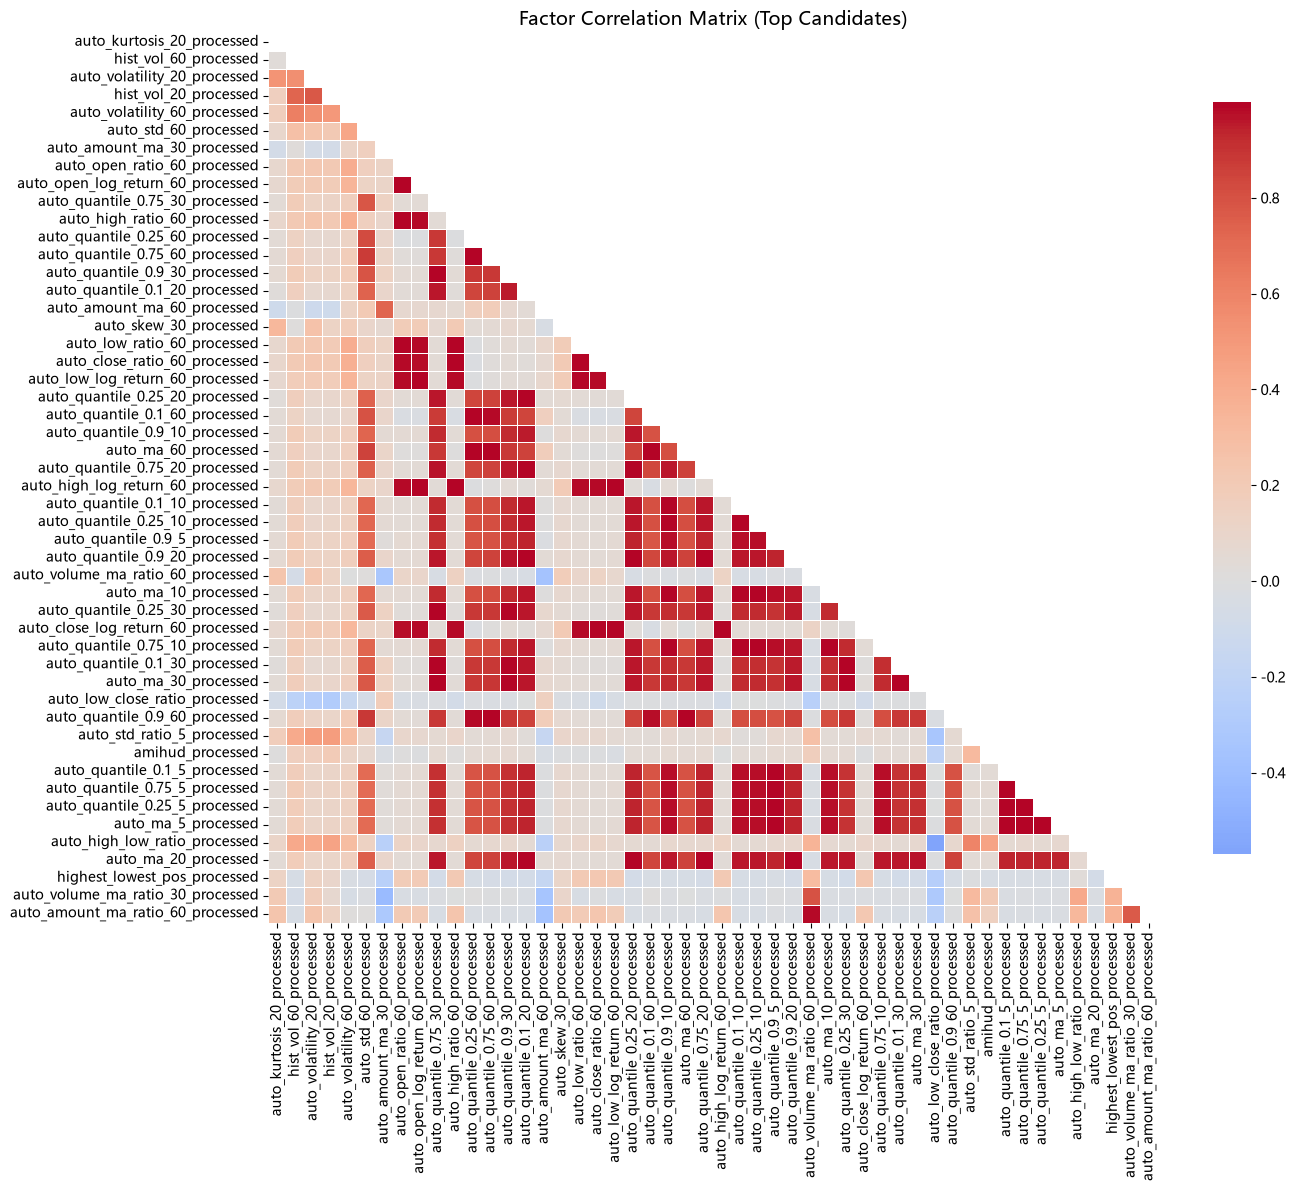


从 50 个候选因子中，通过聚类选择了 25 个代表性因子

仍有 18 对高相关因子 (>0.8)，进行微调...
剔除 8 个因子，当前共 17 个因子

🎯 最终选择的因子: 17个
最终因子列表:
   1. auto_kurtosis_20                                   | IC: 0.0718 | IR: 0.0909 | Mono: 1.0000 | Score: 0.8311
   2. hist_vol_60                                        | IC: -0.0731 | IR: 0.0177 | Mono: -0.9000 | Score: 0.8302
   3. auto_volatility_20                                 | IC: 0.0844 | IR: 0.2053 | Mono: 0.6000 | Score: 0.8185
   4. hist_vol_20                                        | IC: 0.0726 | IR: 0.1806 | Mono: 0.6000 | Score: 0.8080
   5. auto_volatility_60                                 | IC: -0.0509 | IR: 0.1080 | Mono: -0.9000 | Score: 0.7556
   6. auto_std_60                                        | IC: -0.0398 | IR: 0.2308 | Mono: -0.9000 | Score: 0.7329
   7. auto_amount_ma_30                                  | IC: -0.0349 | IR: 0.3455 | Mono: -0.9000 | Score: 0.7298
   8. auto_open_ratio_60                                 | IC: -0.0568 | IR: -0.3750 | Mon

In [8]:
# ==================== 7. 因子综合筛选（多维度评分） ====================
print("\n" + "="*80)
print("7. 因子综合筛选（IC + IR + 单调性 + 相关性）")
print("="*80)

def calculate_ir(factor_col, window=20):
    """计算因子的IR"""
    valid_data = df[[factor_col, 'future_5d_return']].dropna()
    if len(valid_data) < window:
        return 0
    
    ic_series = []
    for i in range(window, len(valid_data)):
        sub_data = valid_data.iloc[i-window:i]
        if len(sub_data) > 10:
            ic = stats.spearmanr(sub_data[factor_col], sub_data['future_5d_return'])[0]
            if not np.isnan(ic):
                ic_series.append(ic)
    
    if len(ic_series) > 0:
        ir = np.mean(ic_series) / (np.std(ic_series) + 1e-6)
        return ir
    return 0

def test_monotonicity_single(factor_col):
    """测试单个因子的单调性"""
    valid_data = df[[factor_col, 'future_5d_return']].dropna()
    if len(valid_data) < 50:
        return None
    
    try:
        valid_data['group'] = pd.qcut(valid_data[factor_col], q=5, labels=False, duplicates='drop')
        if len(valid_data['group'].unique()) < 3:
            return None
        group_returns = valid_data.groupby('group')['future_5d_return'].mean()
        if len(group_returns) >= 3:
            monotonic_corr = stats.spearmanr(range(len(group_returns)), group_returns.values)[0]
            return monotonic_corr
    except:
        return None
    return None

print("计算因子综合指标...")
factor_metrics = []

# 对IC绝对值排名前200的因子进行综合评估
candidate_factors = ic_df.nlargest(200, 'ic_abs')['factor'].tolist() if len(ic_df) > 0 else factor_cols_processed[:200]

for idx, col in enumerate(candidate_factors):
    if idx % 20 == 0:
        print(f"  处理进度: {idx}/{len(candidate_factors)}")
    
    # 计算IC
    ic_info = ic_df[ic_df['factor'] == col]
    ic_value = ic_info['ic'].values[0] if len(ic_info) > 0 else 0
    ic_abs = abs(ic_value)
    
    # 计算IR
    ir = calculate_ir(col)
    
    # 计算单调性
    mono = test_monotonicity_single(col)
    
    # 计算因子覆盖率
    coverage = df[col].notna().mean()
    
    # 计算IC胜率（IC为正的比例）
    valid_data = df[[col, 'future_5d_return']].dropna()
    if len(valid_data) > 20:
        ic_positive = 0
        total_windows = 0
        for i in range(20, min(len(valid_data), 100)):
            sub_data = valid_data.iloc[i-20:i]
            if len(sub_data) > 10:
                ic = stats.spearmanr(sub_data[col], sub_data['future_5d_return'])[0]
                if not np.isnan(ic):
                    if ic > 0:
                        ic_positive += 1
                    total_windows += 1
        ic_win_rate = ic_positive / (total_windows + 1e-6) if total_windows > 0 else 0.5
    else:
        ic_win_rate = 0.5
    
    factor_metrics.append({
        'factor': col,
        'ic': ic_value,
        'ic_abs': ic_abs,
        'ir': ir,
        'monotonicity': mono if mono is not None else 0,
        'ic_win_rate': ic_win_rate,
        'coverage': coverage,
        'n_obs': ic_info['n_obs'].values[0] if len(ic_info) > 0 and 'n_obs' in ic_info.columns else 0
    })

# 转换为DataFrame
factor_metrics_df = pd.DataFrame(factor_metrics)

# 过滤掉覆盖率低于40%的因子
factor_metrics_df = factor_metrics_df[factor_metrics_df['coverage'] > 0.4]
print(f"覆盖率过滤后剩余: {len(factor_metrics_df)} 个因子")

# 过滤掉IC绝对值太低的因子 (< 0.02)
factor_metrics_df = factor_metrics_df[factor_metrics_df['ic_abs'] > 0.02]
print(f"IC绝对值过滤后剩余: {len(factor_metrics_df)} 个因子")

# 计算综合得分（归一化后加权）
factor_metrics_df['ic_score'] = (factor_metrics_df['ic_abs'] - factor_metrics_df['ic_abs'].min()) / (factor_metrics_df['ic_abs'].max() - factor_metrics_df['ic_abs'].min() + 1e-6)
factor_metrics_df['ir_score'] = (factor_metrics_df['ir'] - factor_metrics_df['ir'].min()) / (factor_metrics_df['ir'].max() - factor_metrics_df['ir'].min() + 1e-6)
factor_metrics_df['mono_score'] = (factor_metrics_df['monotonicity'].abs() - factor_metrics_df['monotonicity'].abs().min()) / (factor_metrics_df['monotonicity'].abs().max() - factor_metrics_df['monotonicity'].abs().min() + 1e-6)
factor_metrics_df['win_rate_score'] = factor_metrics_df['ic_win_rate']
factor_metrics_df['coverage_score'] = factor_metrics_df['coverage']

# 综合得分
factor_metrics_df['composite_score'] = (factor_metrics_df['ic_score'] * 0.25 + 
                                        factor_metrics_df['ir_score'] * 0.25 + 
                                        factor_metrics_df['mono_score'] * 0.20 + 
                                        factor_metrics_df['win_rate_score'] * 0.15 + 
                                        factor_metrics_df['coverage_score'] * 0.15)

# 按综合得分排序
factor_metrics_df = factor_metrics_df.sort_values('composite_score', ascending=False)

print(f"\n📊 因子综合评分排名 (Top 30):")
display_cols = ['factor', 'ic', 'ir', 'monotonicity', 'ic_win_rate', 'composite_score']
print(factor_metrics_df[display_cols].head(30).to_string())

# 保存综合评分结果
# factor_metrics_df.to_csv(os.path.join(output_dir, 'factor_composite_scores.csv'), index=False)
# print(f"因子综合评分已保存到: {output_dir}/factor_composite_scores.csv")

# 绘制综合评分图
fig, ax = plt.subplots(figsize=(14, 10))
top_factors = factor_metrics_df.head(30)
factor_names = [f.replace('_processed', '')[:40] for f in top_factors['factor']]

bars = ax.barh(range(len(top_factors)), top_factors['composite_score'], alpha=0.7, 
               color=plt.cm.viridis(np.linspace(0.3, 0.9, len(top_factors))))
ax.set_yticks(range(len(top_factors)))
ax.set_yticklabels(factor_names, fontsize=8)
ax.set_xlabel('Composite Score')
ax.set_title('Top 30 Factor Composite Scores (IC + IR + Monotonicity + Win Rate + Coverage)', fontsize=14)
ax.grid(True, alpha=0.3)

# 添加数值标签
for i, (bar, score) in enumerate(zip(bars, top_factors['composite_score'])):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{score:.3f}', va='center', fontsize=8)

plt.tight_layout()
# plt.savefig(os.path.join(output_dir, 'factor_composite_scores.png'), dpi=300, bbox_inches='tight')
plt.show()
# print(f"因子综合评分图已保存到: {output_dir}/factor_composite_scores.png")

# ==================== 8. 选择Top因子并剔除相关性冗余 ====================
print("\n" + "="*80)
print("8. 选择Top因子并剔除相关性冗余")
print("="*80)

# 目标保留因子数量
TARGET_FACTORS = 25

# 选择综合得分最高的前N个因子（2倍目标，为后续筛选留空间）
selected_top = factor_metrics_df.head(TARGET_FACTORS * 2)['factor'].tolist()
print(f"\n从综合评分前 {len(selected_top)} 个因子中选择，目标保留 {TARGET_FACTORS} 个因子")

if len(selected_top) > 1:
    # 提取因子数据
    factor_data_for_corr = df[selected_top].copy()
    
    # 计算相关性矩阵
    factor_corr = factor_data_for_corr.corr()
    
    # 保存相关性矩阵
    # factor_corr.to_csv(os.path.join(output_dir, 'factor_correlation_top.csv'))
    # print(f"相关性矩阵已保存到: {output_dir}/factor_correlation_top.csv")
    
    # 绘制相关性热力图
    fig, ax = plt.subplots(figsize=(14, 12))
    mask = np.triu(np.ones_like(factor_corr, dtype=bool))
    sns.heatmap(factor_corr, mask=mask, annot=False, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title('Factor Correlation Matrix (Top Candidates)', fontsize=14)
    plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, 'factor_correlation_top.png'), dpi=300, bbox_inches='tight')
    plt.show()
    # print(f"相关性热力图已保存到: {output_dir}/factor_correlation_top.png")
    
    # 使用层次聚类选择代表性因子
    from scipy.cluster.hierarchy import linkage, fcluster
    
    # 计算距离矩阵 (1 - 相关系数)
    distance_matrix = 1 - factor_corr.abs()
    
    # 层次聚类
    linkage_matrix = linkage(distance_matrix, method='average')
    
    # 设定聚类数量为目标因子数
    n_clusters = min(TARGET_FACTORS, len(selected_top) // 2)
    clusters = fcluster(linkage_matrix, t=n_clusters, criterion='maxclust')
    
    # 在每个聚类中选择综合得分最高的因子
    selected_factors_final = []
    cluster_to_factors = {}
    
    for factor, cluster_id in zip(selected_top, clusters):
        if cluster_id not in cluster_to_factors:
            cluster_to_factors[cluster_id] = []
        score = factor_metrics_df[factor_metrics_df['factor'] == factor]['composite_score'].values
        if len(score) > 0:
            cluster_to_factors[cluster_id].append((factor, score[0]))
    
    # 从每个聚类中选择得分最高的因子
    for cluster_id, factors in cluster_to_factors.items():
        factors_sorted = sorted(factors, key=lambda x: x[1], reverse=True)
        selected_factors_final.append(factors_sorted[0][0])
    
    print(f"\n从 {len(selected_top)} 个候选因子中，通过聚类选择了 {len(selected_factors_final)} 个代表性因子")
    
    # 如果选择的因子数量不够目标，从剩余候选中补充
    if len(selected_factors_final) < TARGET_FACTORS:
        remaining = [f for f in selected_top if f not in selected_factors_final]
        remaining_sorted = factor_metrics_df[factor_metrics_df['factor'].isin(remaining)].sort_values('composite_score', ascending=False)
        additional = remaining_sorted.head(TARGET_FACTORS - len(selected_factors_final))['factor'].tolist()
        selected_factors_final.extend(additional)
        print(f"补充了 {len(additional)} 个因子，当前共 {len(selected_factors_final)} 个因子")
    
    # 如果因子太多，保留综合得分最高的
    if len(selected_factors_final) > TARGET_FACTORS + 5:
        final_scores = []
        for f in selected_factors_final:
            score = factor_metrics_df[factor_metrics_df['factor'] == f]['composite_score'].values
            final_scores.append(score[0] if len(score) > 0 else 0)
        sorted_indices = np.argsort(final_scores)[::-1]
        selected_factors_final = [selected_factors_final[i] for i in sorted_indices[:TARGET_FACTORS]]
        print(f"截断到 {len(selected_factors_final)} 个因子")
    
    # 最终检查：如果还有高相关的因子对 (>0.8)，进行微调
    if len(selected_factors_final) > 1:
        final_data = df[selected_factors_final].copy()
        final_corr = final_data.corr()
        
        high_corr_pairs_final = []
        for i in range(len(selected_factors_final)):
            for j in range(i+1, len(selected_factors_final)):
                if abs(final_corr.iloc[i, j]) > 0.8:
                    high_corr_pairs_final.append((selected_factors_final[i], selected_factors_final[j], final_corr.iloc[i, j]))
        
        if high_corr_pairs_final:
            print(f"\n仍有 {len(high_corr_pairs_final)} 对高相关因子 (>0.8)，进行微调...")
            to_remove_final = set()
            for f1, f2, corr in high_corr_pairs_final:
                score1 = factor_metrics_df[factor_metrics_df['factor'] == f1]['composite_score'].values
                score2 = factor_metrics_df[factor_metrics_df['factor'] == f2]['composite_score'].values
                if len(score1) > 0 and len(score2) > 0:
                    if score1[0] < score2[0]:
                        to_remove_final.add(f1)
                    else:
                        to_remove_final.add(f2)
            
            selected_factors_final = [f for f in selected_factors_final if f not in to_remove_final]
            print(f"剔除 {len(to_remove_final)} 个因子，当前共 {len(selected_factors_final)} 个因子")
            
            # 如果剔除后太少，补充一些
            if len(selected_factors_final) < 15:
                remaining_all = [f for f in factor_metrics_df['factor'].tolist() if f not in selected_factors_final]
                additional = factor_metrics_df[factor_metrics_df['factor'].isin(remaining_all)].head(20 - len(selected_factors_final))['factor'].tolist()
                selected_factors_final.extend(additional)
                print(f"补充后共 {len(selected_factors_final)} 个因子")
    
    final_factors = selected_factors_final
    
else:
    print("因子数量不足，使用全部候选因子")
    final_factors = selected_top

# 确保至少有15个因子
if len(final_factors) < 15:
    print(f"\n当前因子数量 {len(final_factors)} 少于15，从候选中补充...")
    remaining_all = [f for f in factor_metrics_df['factor'].tolist() if f not in final_factors]
    additional = factor_metrics_df[factor_metrics_df['factor'].isin(remaining_all)].head(20 - len(final_factors))['factor'].tolist()
    final_factors.extend(additional)
    print(f"补充后共 {len(final_factors)} 个因子")

print(f"\n🎯 最终选择的因子: {len(final_factors)}个")
print(f"最终因子列表:")
for i, f in enumerate(final_factors, 1):
    info = factor_metrics_df[factor_metrics_df['factor'] == f]
    if len(info) > 0:
        ic_val = info['ic'].values[0]
        ir_val = info['ir'].values[0]
        mono_val = info['monotonicity'].values[0]
        score_val = info['composite_score'].values[0]
        print(f"  {i:2d}. {f.replace('_processed', '')[:50]:<50} | IC: {ic_val:.4f} | IR: {ir_val:.4f} | Mono: {mono_val:.4f} | Score: {score_val:.4f}")

# 保存最终因子列表（包含详细信息）
final_factors_detail = []
for f in final_factors:
    info = factor_metrics_df[factor_metrics_df['factor'] == f]
    if len(info) > 0:
        final_factors_detail.append({
            'factor_name': f,
            'ic': info['ic'].values[0],
            'ic_abs': info['ic_abs'].values[0],
            'ir': info['ir'].values[0],
            'monotonicity': info['monotonicity'].values[0],
            'ic_win_rate': info['ic_win_rate'].values[0],
            'composite_score': info['composite_score'].values[0],
            'coverage': info['coverage'].values[0],
            'rank': len(final_factors_detail) + 1
        })

final_factors_df = pd.DataFrame(final_factors_detail)
# final_factors_df.to_csv(os.path.join(output_dir, 'final_selected_factors_with_metrics.csv'), index=False)
# print(f"\n最终因子详细信息已保存到: {output_dir}/final_selected_factors_with_metrics.csv")

# 保存简单列表
# pd.DataFrame({
#     'factor_name': final_factors,
#     'rank': range(1, len(final_factors) + 1),
#     'is_selected': 1
# }).to_csv(os.path.join(output_dir, 'final_selected_factors_list.csv'), index=False)
# print(f"最终因子列表已保存到: {output_dir}/final_selected_factors_list.csv")

print(f"\n✅ 最终筛选完成，保留 {len(final_factors)} 个因子")

# ==================== 9. 保存筛选后的因子数据 ====================
print("\n" + "="*80)
print("9. 保存筛选后的因子数据")
print("="*80)

# 提取筛选后的因子值（原始值，非预处理值）
original_factor_names = [f.replace('_processed', '') for f in final_factors]
original_factor_names = [f for f in original_factor_names if f in df.columns]

# 如果原始因子列不存在，使用预处理后的列
if len(original_factor_names) == 0:
    print("原始因子列不存在，使用预处理后的因子列")
    original_factor_names = final_factors

print(f"提取 {len(original_factor_names)} 个因子的数据...")

# 构建输出数据
output_df = pd.DataFrame()
output_df['ts_code'] = df['ts_code']
output_df['trade_date'] = df['trade_date']

# 添加基础价格数据
base_cols = ['open', 'high', 'low', 'close', 'vol', 'amount', 'pre_close', 'pct_chg']
for col in base_cols:
    if col in df.columns:
        output_df[col] = df[col]

# 添加基础衍生指标
derived_cols = ['daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']
for col in derived_cols:
    if col in df.columns:
        output_df[col] = df[col]

# 添加因子数据
for factor in original_factor_names:
    if factor in df.columns:
        output_df[factor] = df[factor]
    else:
        processed_factor = f'{factor}_processed'
        if processed_factor in df.columns:
            output_df[factor] = df[processed_factor]
        else:
            print(f"警告: 因子 {factor} 不存在于数据中")

# 添加未来5日收益
if 'future_5d_return' in df.columns:
    output_df['future_5d_return'] = df['future_5d_return']

# 添加月份标识
output_df['year_month'] = df['trade_date'].dt.to_period('M')

# ==================== 保存到 ../extracted_data/ 目录 ====================
# extracted_data_dir = os.path.join(os.path.dirname(os.path.abspath('.')), 'extracted_data')
# if not os.path.exists(extracted_data_dir):
#     os.makedirs(extracted_data_dir)
#     print(f"创建目录: {extracted_data_dir}")

# output_file = os.path.join(extracted_data_dir, 'selected_factors_with_data1.csv')
# output_df.to_csv(output_file, index=False)
# print(f"✅ 筛选后的因子数据已保存到: {output_file}")
# print(f"   数据形状: {output_df.shape}")
# print(f"   包含因子数量: {len(original_factor_names)}")
# print(f"   时间范围: {output_df['trade_date'].min()} 至 {output_df['trade_date'].max()}")

# # 同时也在output_dir保存一份备份
# backup_file = os.path.join(output_dir, 'selected_factors_with_data_backup.csv')
# output_df.to_csv(backup_file, index=False)
# print(f"✅ 备份数据已保存到: {backup_file}")

# ==================== 10. 保存因子统计信息 ====================
print("\n" + "="*80)
print("10. 保存因子统计信息")
print("="*80)

factor_stats = []
for factor in original_factor_names:
    if factor in output_df.columns:
        factor_stats.append({
            'factor_name': factor,
            'mean': output_df[factor].mean(),
            'std': output_df[factor].std(),
            'min': output_df[factor].min(),
            'max': output_df[factor].max(),
            'skew': output_df[factor].skew(),
            'kurtosis': output_df[factor].kurt(),
            'coverage': output_df[factor].notna().mean()
        })

if factor_stats:
    factor_stats_df = pd.DataFrame(factor_stats)
    # factor_stats_df.to_csv(os.path.join(output_dir, 'selected_factors_statistics.csv'), index=False)
    # print(f"因子统计信息已保存到: {output_dir}/selected_factors_statistics.csv")



In [9]:
# 获取最终因子的原始列名
final_factor_original = [f.replace('_processed', '') for f in final_factors]
# 只保留存在于df中的因子
final_factor_original = [f for f in final_factor_original if f in df.columns]

print(f"用于加权计算的因子数量: {len(final_factor_original)}")

# 提取因子数据（原始值）
factor_data_raw = df[final_factor_original].copy()

# 处理缺失值和异常值
factor_data_raw = factor_data_raw.replace([np.inf, -np.inf], np.nan)
factor_data_raw = factor_data_raw.ffill().bfill().fillna(0)

# 获取每个因子的IC值和IR值（从factor_metrics_df中获取）
factor_weights_info = []
has_ir_info = False

for f in final_factor_original:
    # 查找对应的processed因子名
    processed_name = f'{f}_processed'
    
    # 从factor_metrics_df获取信息
    info = factor_metrics_df[factor_metrics_df['factor'] == processed_name]
    
    if len(info) > 0:
        ic_val = info['ic'].values[0]
        ir_val = info['ir'].values[0]
        if ir_val != 0:
            has_ir_info = True
    else:
        # 如果找不到，尝试从ic_df获取
        ic_info = ic_df[ic_df['factor'] == processed_name]
        ic_val = ic_info['ic'].values[0] if len(ic_info) > 0 else 0
        ir_val = 0
    
    factor_weights_info.append({
        'factor': f,
        'ic': ic_val,
        'ir': ir_val,
        'ic_abs': abs(ic_val)
    })

factor_weights_df = pd.DataFrame(factor_weights_info)
print("\n因子权重信息:")
print(factor_weights_df)

# 12.1 确定加权方式
print("\n12.1 确定加权方式...")

# 检查是否有有效的IR信息
if has_ir_info:
    print("检测到IR信息，使用IR加权")
    use_ir_weighting = True
else:
    print("未检测到IR信息，使用IC加权")
    use_ir_weighting = False

# 12.2 计算权重
print("\n12.2 计算权重...")

if use_ir_weighting:
    # IR加权
    weights = factor_weights_df['ir'].values
    weight_type = 'IR'
    # 处理负值：如果IR为负，取绝对值
    weights = np.maximum(weights, 0)
else:
    # IC加权（使用IC绝对值）
    weights = factor_weights_df['ic_abs'].values
    weight_type = 'IC'
    # IC权重直接使用绝对值

# 检查权重是否全为0
if weights.sum() > 0:
    weights = weights / weights.sum()
else:
    # 如果所有权重都为0，使用等权
    weights = np.ones(len(factor_weights_df)) / len(factor_weights_df)
    print(f"{weight_type}权重全为0，使用等权替代")

# 创建权重字典
weight_dict = dict(zip(factor_weights_df['factor'], weights))

print(f"\n{weight_type}加权权重:")
for f, w in zip(factor_weights_df['factor'], weights):
    print(f"  {f}: {w:.4f}")

# 12.3 等权
print("\n12.3 等权计算...")
equal_weights = np.ones(len(factor_weights_df)) / len(factor_weights_df)
equal_weight_dict = dict(zip(factor_weights_df['factor'], equal_weights))

print("等权权重:")
for f, w in zip(factor_weights_df['factor'], equal_weights):
    print(f"  {f}: {w:.4f}")

# # 保存权重信息
# weights_df = pd.DataFrame({
#     'factor': factor_weights_df['factor'],
#     'ic': factor_weights_df['ic'],
#     'ir': factor_weights_df['ir'],
#     f'{weight_type}_weight': weights,
#     'equal_weight': equal_weights,
#     'weight_type': weight_type if use_ir_weighting else 'IC'
# })
# weights_df.to_csv(os.path.join(output_dir, 'factor_weights.csv'), index=False)
# print(f"\n权重信息已保存到: {output_dir}/factor_weights.csv")

用于加权计算的因子数量: 17

因子权重信息:
                     factor        ic        ir    ic_abs
0          auto_kurtosis_20  0.071792  0.090900  0.071792
1               hist_vol_60 -0.073062  0.017730  0.073062
2        auto_volatility_20  0.084388  0.205274  0.084388
3               hist_vol_20  0.072586  0.180633  0.072586
4        auto_volatility_60 -0.050866  0.107987  0.050866
5               auto_std_60 -0.039786  0.230801  0.039786
6         auto_amount_ma_30 -0.034919  0.345466  0.034919
7        auto_open_ratio_60 -0.056831 -0.374962  0.056831
8     auto_quantile_0.75_30 -0.032921  0.255205  0.032921
9         auto_amount_ma_60 -0.025766  0.395240  0.025766
10             auto_skew_30  0.033589  0.214689  0.033589
11  auto_volume_ma_ratio_60  0.036114 -0.221119  0.036114
12     auto_low_close_ratio -0.028528  0.336263  0.028528
13         auto_std_ratio_5  0.039636  0.210401  0.039636
14                   amihud  0.039276  0.049672  0.039276
15      auto_high_low_ratio  0.028870  0.126126


12.4 计算综合因子得分...

综合因子得分统计 (IR_Weighted):
count    2.397900e+04
mean     8.913268e-16
std      4.342642e-01
min     -8.491997e-01
25%     -2.882202e-01
50%     -1.097678e-01
75%      1.597650e-01
max      2.849458e+00
Name: composite_score_weighted, dtype: float64

综合因子得分统计 (Equal Weighted):
count    2.397900e+04
mean     4.432929e-16
std      4.129253e-01
min     -8.284822e-01
25%     -2.828732e-01
50%     -7.678225e-02
75%      1.907852e-01
max      4.021741e+00
Name: composite_score_equal, dtype: float64


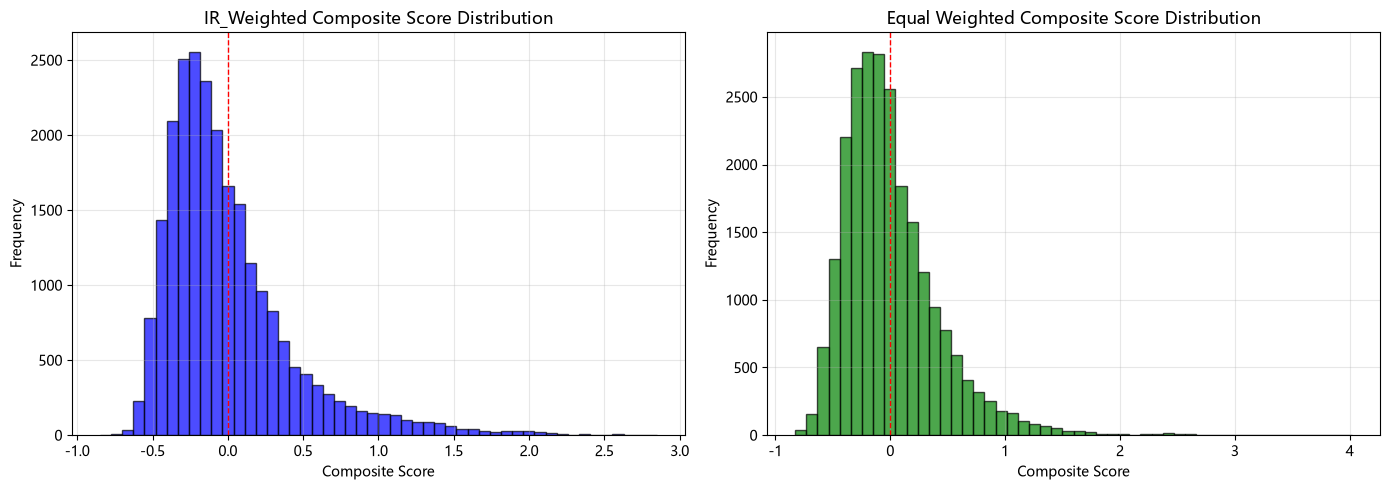

In [10]:
print("\n12.4 计算综合因子得分...")

def calculate_composite_score(factor_data, weights_dict):
    """计算综合因子得分"""
    score = np.zeros(len(factor_data))
    for factor, weight in weights_dict.items():
        if factor in factor_data.columns:
            # 对每个因子进行Z-score标准化后再加权
            factor_values = factor_data[factor].values
            if factor_values.std() > 0:
                factor_std = (factor_values - factor_values.mean()) / (factor_values.std() + 1e-6)
                score += factor_std * weight
            else:
                score += factor_values * weight
    return score

# 计算加权综合得分（使用IR或IC）
df['composite_score_weighted'] = calculate_composite_score(factor_data_raw, weight_dict)
strategy_name = f'{weight_type}_Weighted'

# 计算等权综合得分
df['composite_score_equal'] = calculate_composite_score(factor_data_raw, equal_weight_dict)

print(f"\n综合因子得分统计 ({strategy_name}):")
print(df['composite_score_weighted'].describe())
print(f"\n综合因子得分统计 (Equal Weighted):")
print(df['composite_score_equal'].describe())

# 绘制综合得分分布对比
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['composite_score_weighted'].dropna(), bins=50, alpha=0.7, color='blue', edgecolor='black')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Composite Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'{strategy_name} Composite Score Distribution')
axes[0].grid(True, alpha=0.3)

axes[1].hist(df['composite_score_equal'].dropna(), bins=50, alpha=0.7, color='green', edgecolor='black')
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Composite Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Equal Weighted Composite Score Distribution')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
# plt.savefig(os.path.join(output_dir, 'composite_score_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()
# print(f"综合得分分布图已保存到: {output_dir}/composite_score_distribution.png")

聚类特征: ['daily_return', 'turnover_rate', 'amplitude', 'amount_ratio', 'log_amount']

使用肘部法则确定最优聚类数...


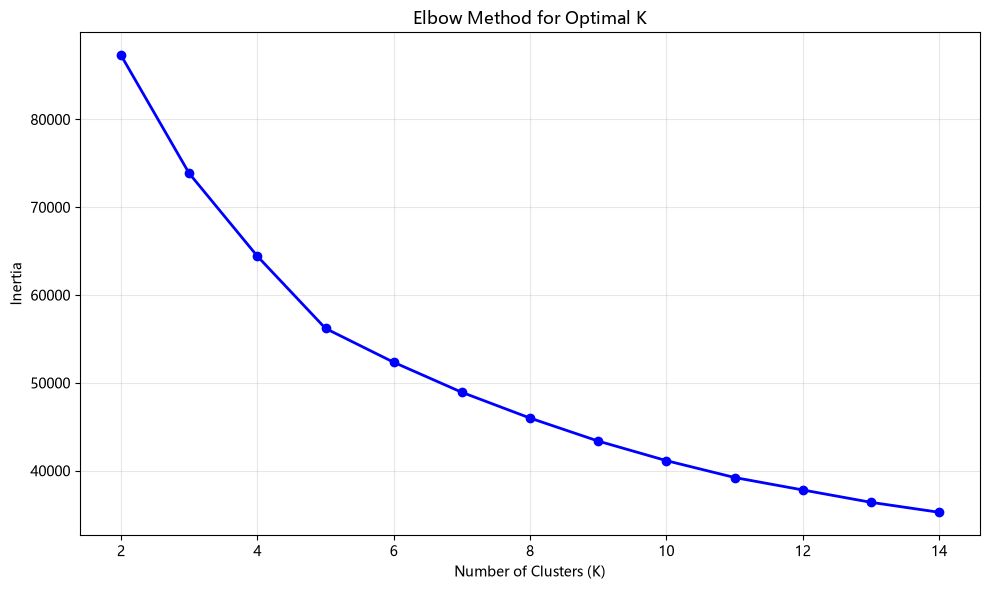


选择聚类数: 8

各聚类样本分布:
cluster
0    7496
1     958
2    2769
3    3323
4    4998
5     125
6    3273
7    1037
Name: count, dtype: int64


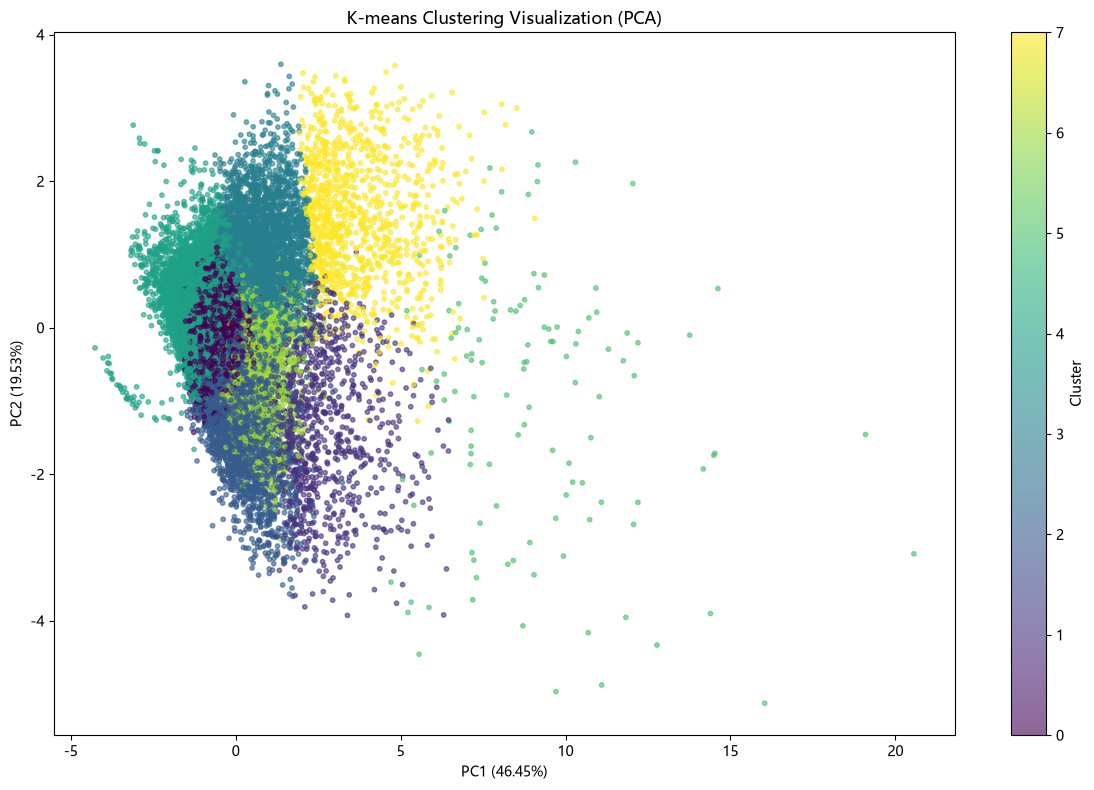


各聚类股票数量:
cluster
0     94
1    100
2     96
3     99
4     73
5     54
6     76
7    100
Name: ts_code, dtype: int64


In [11]:
# ==================== 13. K-means聚类（基于量价特征） ====================

# 选择聚类特征
cluster_features = ['daily_return', 'turnover_rate', 'amplitude', 'amount_ratio', 'log_amount']
# 检查哪些特征存在
cluster_features = [f for f in cluster_features if f in df.columns]

print(f"聚类特征: {cluster_features}")

# 提取聚类数据
cluster_data = df[cluster_features].copy()

# 处理缺失值和无穷值
cluster_data = cluster_data.replace([np.inf, -np.inf], np.nan)
cluster_data = cluster_data.ffill().bfill().fillna(0)

# 标准化
cluster_scaler = StandardScaler()
cluster_data_scaled = cluster_scaler.fit_transform(cluster_data)

# 确定聚类数量（使用肘部法则）
print("\n使用肘部法则确定最优聚类数...")
inertias = []
K_range = range(2, min(15, df['ts_code'].nunique() // 5 + 2))

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(cluster_data_scaled)
    inertias.append(kmeans_temp.inertia_)

# 绘制肘部图
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, 'bo-', linewidth=2)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia')
ax.set_title('Elbow Method for Optimal K')
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig(os.path.join(output_dir, 'elbow_method.png'), dpi=300, bbox_inches='tight')
plt.show()
# print(f"肘部图已保存到: {output_dir}/elbow_method.png")

# 选择聚类数（根据肘部法则或固定值）
n_clusters = min(8, max(2, df['ts_code'].nunique() // 5))
print(f"\n选择聚类数: {n_clusters}")

# 执行K-means聚类
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_data_scaled)

print(f"\n各聚类样本分布:")
cluster_dist = df['cluster'].value_counts().sort_index()
print(cluster_dist)

# 可视化聚类结果（使用PCA降维到2D）
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
cluster_data_pca = pca.fit_transform(cluster_data_scaled)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(cluster_data_pca[:, 0], cluster_data_pca[:, 1], 
                     c=df['cluster'], cmap='viridis', alpha=0.6, s=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
ax.set_title('K-means Clustering Visualization (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
# plt.savefig(os.path.join(output_dir, 'cluster_visualization.png'), dpi=300, bbox_inches='tight')
plt.show()
# print(f"聚类可视化图已保存到: {output_dir}/cluster_visualization.png")

# 统计每个聚类的股票数量
cluster_stock_count = df.groupby('cluster')['ts_code'].nunique()
print(f"\n各聚类股票数量:")
print(cluster_stock_count)

In [12]:
# ==================== 14. 初始多因子选股回测 ====================
print("\n" + "="*80)
print("14. 初始多因子选股回测")
print("="*80)

def backtest_strategy(df, score_col, strategy_name, top_n=30, cluster_limit_ratio=0.3):
    """
    多因子选股回测
    """
    print(f"\n回测策略: {strategy_name}")
    
    # 初始化结果
    df[f'selected_{strategy_name}'] = 0
    daily_returns = []
    daily_dates = []
    selected_counts = []
    
    # 按月份分组进行调仓
    df['year_month'] = df['trade_date'].dt.to_period('M')
    
    print("开始选股回测...")
    for month, group in df.groupby('year_month'):
        if len(group) < top_n:
            continue
        
        # 限制每个聚类最多30%
        cluster_limit = max(1, int(cluster_limit_ratio * top_n))
        
        selected_stocks = []
        
        # 在每个聚类中选择得分最高的股票
        for cluster in group['cluster'].unique():
            cluster_group = group[group['cluster'] == cluster]
            if len(cluster_group) > 0:
                top_n_cluster = min(cluster_limit, len(cluster_group))
                top_stocks = cluster_group.nlargest(top_n_cluster, score_col)
                selected_stocks.extend(top_stocks.index.tolist())
        
        # 如果选股不足top_n，从剩余股票中补充
        if len(selected_stocks) < top_n:
            remaining = group[~group.index.isin(selected_stocks)]
            if len(remaining) > 0:
                additional = remaining.nlargest(top_n - len(selected_stocks), score_col)
                selected_stocks.extend(additional.index.tolist())
        
        # 标记选中的股票
        if len(selected_stocks) > 0:
            df.loc[selected_stocks, f'selected_{strategy_name}'] = 1
        
        selected_counts.append(len(selected_stocks))
    
    print(f"选股完成，平均选股数量: {np.mean(selected_counts):.1f}")
    
    # 计算每日组合收益
    print("计算组合收益...")
    daily_returns = []
    dates = []
    
    for date in df['trade_date'].unique():
        day_data = df[df['trade_date'] == date]
        selected = day_data[day_data[f'selected_{strategy_name}'] == 1]
        
        if len(selected) > 0:
            # 等权组合收益
            avg_return = selected['daily_return'].mean()
            if not np.isnan(avg_return):
                daily_returns.append(avg_return)
                dates.append(date)
    
    if len(daily_returns) == 0:
        print(f"{strategy_name} 没有交易记录")
        return None, None, None
    
    # 转换为时间序列
    returns_series = pd.Series(daily_returns, index=pd.to_datetime(dates))
    returns_series = returns_series.sort_index()
    
    # 计算累积收益
    cumulative_returns = (1 + returns_series).cumprod()
    
    # 计算绩效指标
    total_return = cumulative_returns.iloc[-1] - 1 if len(cumulative_returns) > 0 else 0
    annual_return = (1 + total_return) ** (252 / len(returns_series)) - 1 if len(returns_series) > 0 else 0
    volatility = returns_series.std() * np.sqrt(252) if len(returns_series) > 0 else 0
    sharpe_ratio = annual_return / volatility if volatility > 0 else 0
    
    # 最大回撤
    rolling_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min()
    
    # 胜率
    win_rate = (returns_series > 0).sum() / len(returns_series) if len(returns_series) > 0 else 0
    
    print(f"\n{strategy_name} 绩效指标:")
    print(f"  总收益率: {total_return:.2%}")
    print(f"  年化收益率: {annual_return:.2%}")
    print(f"  年化波动率: {volatility:.2%}")
    print(f"  夏普比率: {sharpe_ratio:.4f}")
    print(f"  最大回撤: {max_drawdown:.2%}")
    print(f"  胜率: {win_rate:.2%}")
    print(f"  交易天数: {len(returns_series)}")
    
    return returns_series, cumulative_returns, {
        'total_return': total_return,
        'annual_return': annual_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'n_days': len(returns_series)
    }

# 回测加权策略（IR或IC）
print("\n" + "="*60)
print(f"回测{strategy_name}策略")
print("="*60)
returns_weighted, cum_weighted, metrics_weighted = backtest_strategy(
    df, 'composite_score_weighted', strategy_name, top_n=30, cluster_limit_ratio=0.3
)

# 回测等权策略
print("\n" + "="*60)
print("回测等权策略")
print("="*60)
returns_equal, cum_equal, metrics_equal = backtest_strategy(
    df, 'composite_score_equal', 'Equal_Weighted', top_n=30, cluster_limit_ratio=0.3
)



14. 初始多因子选股回测

回测IR_Weighted策略

回测策略: IR_Weighted
开始选股回测...
选股完成，平均选股数量: 68.4
计算组合收益...

IR_Weighted 绩效指标:
  总收益率: -45.60%
  年化收益率: -46.27%
  年化波动率: 44.89%
  夏普比率: -1.0308
  最大回撤: -60.87%
  胜率: 41.70%
  交易天数: 247

回测等权策略

回测策略: Equal_Weighted
开始选股回测...
选股完成，平均选股数量: 68.4
计算组合收益...

Equal_Weighted 绩效指标:
  总收益率: -46.91%
  年化收益率: -48.00%
  年化波动率: 44.71%
  夏普比率: -1.0736
  最大回撤: -52.77%
  胜率: 43.03%
  交易天数: 244



策略绩效对比:
         strategy  total_return  annual_return  sharpe_ratio  max_drawdown  win_rate
0     IR_Weighted     -0.456041      -0.462705     -1.030820     -0.608731  0.417004
1  Equal_Weighted     -0.469134      -0.480042     -1.073564     -0.527743  0.430328


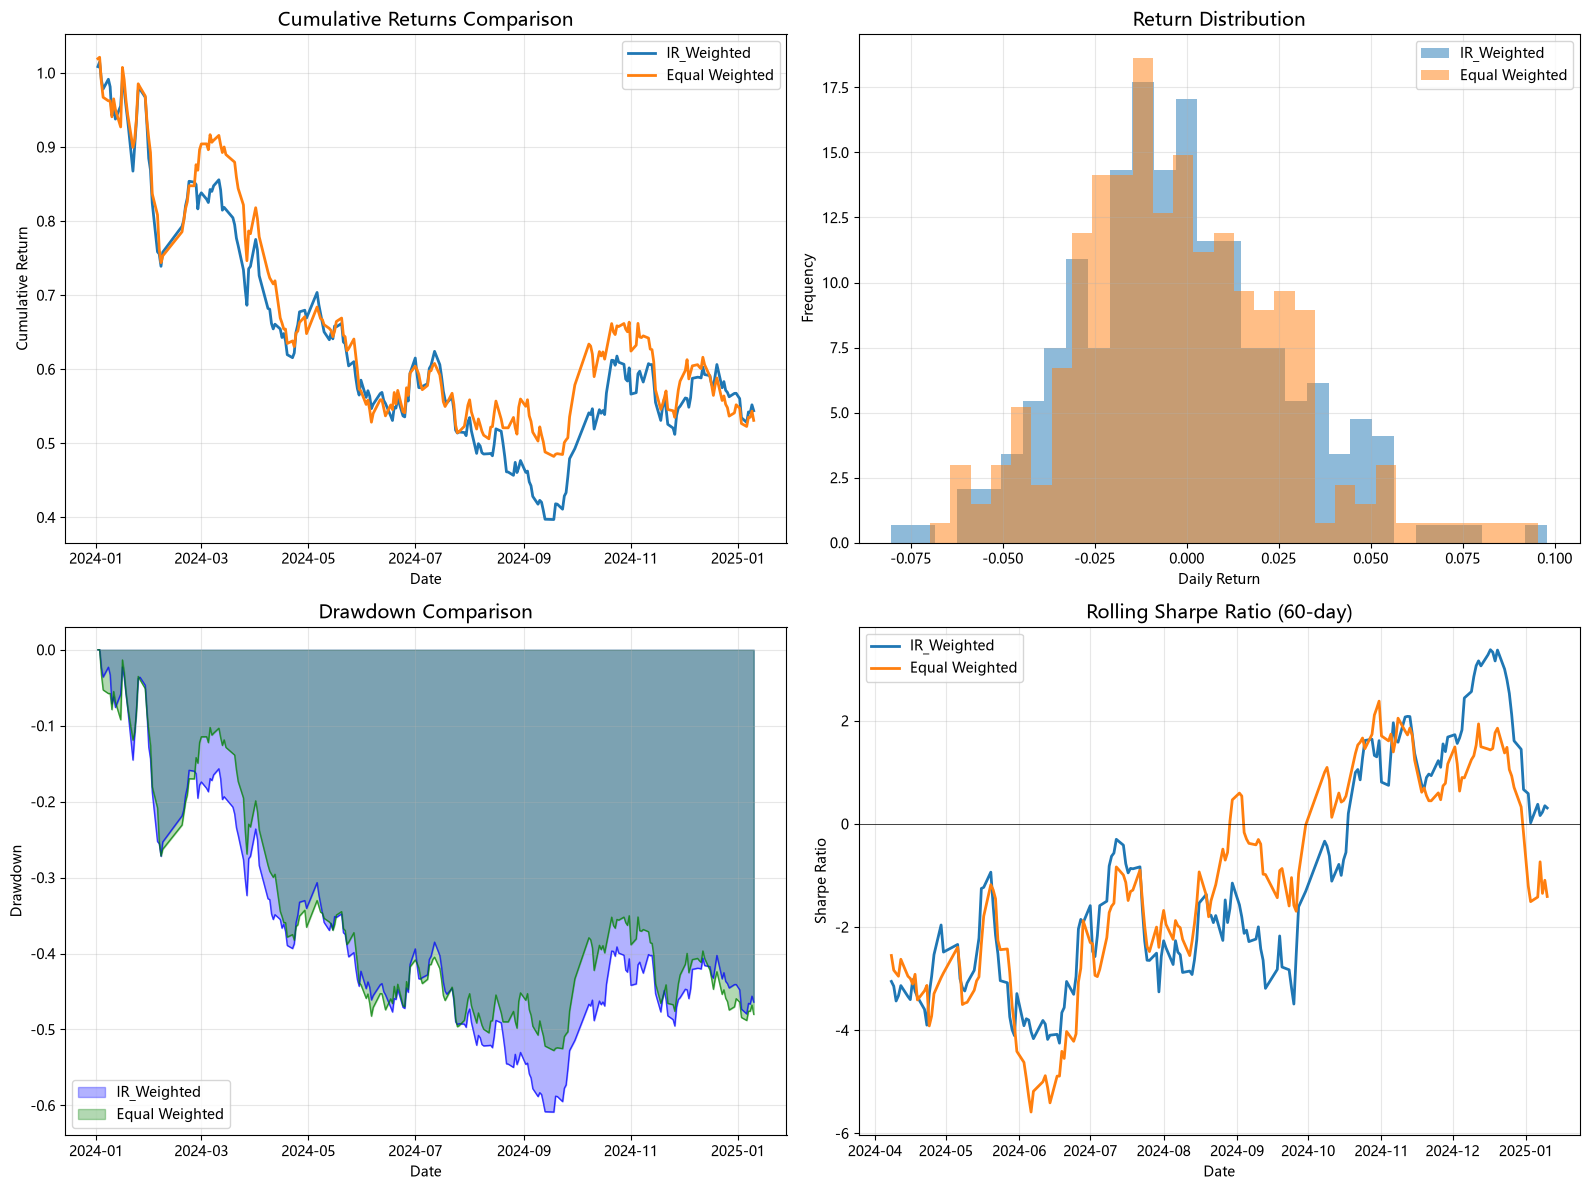

In [13]:
# 保存绩效指标
performance_results = []
if metrics_weighted:
    perf_weighted = metrics_weighted.copy()
    perf_weighted['strategy'] = strategy_name
    performance_results.append(perf_weighted)
if metrics_equal:
    perf_equal = metrics_equal.copy()
    perf_equal['strategy'] = 'Equal_Weighted'
    performance_results.append(perf_equal)

if performance_results:
    perf_df = pd.DataFrame(performance_results)
    # perf_df.to_csv(os.path.join(output_dir, 'initial_backtest_performance.csv'), index=False)
    # print(f"绩效指标已保存到: {output_dir}/initial_backtest_performance.csv")
    print("\n策略绩效对比:")
    print(perf_df[['strategy', 'total_return', 'annual_return', 'sharpe_ratio', 'max_drawdown', 'win_rate']].to_string())

# 绘制回测结果对比图
if returns_weighted is not None or returns_equal is not None:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 累积收益对比
    ax1 = axes[0, 0]
    if cum_weighted is not None:
        ax1.plot(cum_weighted.index, cum_weighted, label=strategy_name, linewidth=2)
    if cum_equal is not None:
        ax1.plot(cum_equal.index, cum_equal, label='Equal Weighted', linewidth=2)
    ax1.set_title('Cumulative Returns Comparison', fontsize=14)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 收益分布
    ax2 = axes[0, 1]
    if returns_weighted is not None:
        ax2.hist(returns_weighted.dropna(), bins=30, alpha=0.5, label=strategy_name, density=True)
    if returns_equal is not None:
        ax2.hist(returns_equal.dropna(), bins=30, alpha=0.5, label='Equal Weighted', density=True)
    ax2.set_title('Return Distribution', fontsize=14)
    ax2.set_xlabel('Daily Return')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # 回撤对比
    ax3 = axes[1, 0]
    if cum_weighted is not None:
        rolling_max_weighted = cum_weighted.expanding().max()
        drawdown_weighted = (cum_weighted - rolling_max_weighted) / rolling_max_weighted
        ax3.fill_between(drawdown_weighted.index, drawdown_weighted, 0, alpha=0.3, label=strategy_name, color='blue')
        ax3.plot(drawdown_weighted.index, drawdown_weighted, linewidth=1, color='blue', alpha=0.7)
    
    if cum_equal is not None:
        rolling_max_equal = cum_equal.expanding().max()
        drawdown_equal = (cum_equal - rolling_max_equal) / rolling_max_equal
        ax3.fill_between(drawdown_equal.index, drawdown_equal, 0, alpha=0.3, label='Equal Weighted', color='green')
        ax3.plot(drawdown_equal.index, drawdown_equal, linewidth=1, color='green', alpha=0.7)
    
    ax3.set_title('Drawdown Comparison', fontsize=14)
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Drawdown')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 滚动夏普比率
    ax4 = axes[1, 1]
    if returns_weighted is not None:
        rolling_sharpe_weighted = returns_weighted.rolling(60).apply(lambda x: x.mean() / (x.std() + 1e-6)) * np.sqrt(252)
        ax4.plot(rolling_sharpe_weighted.index, rolling_sharpe_weighted, label=strategy_name, linewidth=2)
    
    if returns_equal is not None:
        rolling_sharpe_equal = returns_equal.rolling(60).apply(lambda x: x.mean() / (x.std() + 1e-6)) * np.sqrt(252)
        ax4.plot(rolling_sharpe_equal.index, rolling_sharpe_equal, label='Equal Weighted', linewidth=2)
    
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax4.set_title('Rolling Sharpe Ratio (60-day)', fontsize=14)
    ax4.set_xlabel('Date')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # plt.savefig(os.path.join(output_dir, 'initial_backtest_results.png'), dpi=300, bbox_inches='tight')
    plt.show()
    # print(f"回测结果图已保存到: {output_dir}/initial_backtest_results.png")

In [14]:
print("\n" + "="*80)
print("15. 深度学习因子增强器 (LSTM + Transformer)")
print("="*80)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 检查GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 15.1 准备序列数据
print("\n15.1 准备序列数据...")

def prepare_sequence_data(df, seq_length=20, feature_cols=None):
    """
    准备序列数据用于深度学习模型
    """
    if feature_cols is None:
        # 使用基础量价特征
        feature_cols = ['open', 'high', 'low', 'close', 'vol', 'amount', 
                       'daily_return', 'turnover_rate', 'amplitude']
        feature_cols = [f for f in feature_cols if f in df.columns]
    
    print(f"使用特征: {feature_cols}")
    
    # 按股票分组提取序列
    sequences = []
    targets = []
    stock_codes = []
    trade_dates = []
    
    for ts_code in df['ts_code'].unique():
        stock_data = df[df['ts_code'] == ts_code].sort_values('trade_date')
        
        # 提取特征数据
        feature_data = stock_data[feature_cols].values
        
        # 提取目标（未来5日收益）
        target_data = stock_data['future_5d_return'].values
        
        # 创建序列
        for i in range(seq_length, len(stock_data) - 1):
            seq = feature_data[i-seq_length:i]
            target = target_data[i]
            
            # 检查是否有NaN
            if not np.isnan(seq).any() and not np.isnan(target):
                sequences.append(seq)
                targets.append(target)
                stock_codes.append(ts_code)
                trade_dates.append(stock_data.iloc[i]['trade_date'])
    
    print(f"生成序列数量: {len(sequences)}")
    
    # 转换为numpy数组
    X = np.array(sequences, dtype=np.float32)
    y = np.array(targets, dtype=np.float32)
    
    print(f"X形状: {X.shape}, y形状: {y.shape}")
    
    return X, y, stock_codes, trade_dates, feature_cols

# 准备数据
SEQ_LENGTH = 20
X, y, stock_codes, trade_dates, feature_cols = prepare_sequence_data(
    df, seq_length=SEQ_LENGTH
)

print(f"\n序列数据准备完成:")
print(f"  X形状: {X.shape}")
print(f"  y形状: {y.shape}")


15. 深度学习因子增强器 (LSTM + Transformer)
使用设备: cpu

15.1 准备序列数据...
使用特征: ['open', 'high', 'low', 'close', 'vol', 'amount', 'daily_return', 'turnover_rate', 'amplitude']
生成序列数量: 19583
X形状: (19583, 20, 9), y形状: (19583,)

序列数据准备完成:
  X形状: (19583, 20, 9)
  y形状: (19583,)


In [15]:
# 15.2 划分训练集和测试集
print("\n15.2 划分训练集和测试集...")

# 按时间划分（前80%训练，后20%测试）
split_idx = int(len(X) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
stock_codes_test = stock_codes[split_idx:]
trade_dates_test = trade_dates[split_idx:]

print(f"训练集: {X_train.shape[0]} 样本")
print(f"测试集: {X_test.shape[0]} 样本")

# 标准化
scaler_X = StandardScaler()
X_train_flat = X_train.reshape(-1, X_train.shape[-1])
X_train_scaled = scaler_X.fit_transform(X_train_flat).reshape(X_train.shape)

X_test_flat = X_test.reshape(-1, X_test.shape[-1])
X_test_scaled = scaler_X.transform(X_test_flat).reshape(X_test.shape)

# 目标值标准化
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print("数据标准化完成")

# 转换为PyTorch张量
X_train_tensor = torch.FloatTensor(X_train_scaled).to(device)
y_train_tensor = torch.FloatTensor(y_train_scaled).to(device)
X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
y_test_tensor = torch.FloatTensor(y_test_scaled).to(device)


15.2 划分训练集和测试集...
训练集: 15666 样本
测试集: 3917 样本
数据标准化完成


In [16]:
# 15.3 定义LSTM模型
print("\n15.3 定义LSTM模型...")

class LSTMFactorExtractor(nn.Module):
    """LSTM因子提取器"""
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super(LSTMFactorExtractor, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, 
                           batch_first=True, dropout=dropout)
        self.fc1 = nn.Linear(hidden_size, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # LSTM
        lstm_out, (h_n, c_n) = self.lstm(x)
        # 使用最后一个时间步的隐藏状态
        last_hidden = lstm_out[:, -1, :]
        # 全连接层
        out = self.dropout(self.relu(self.fc1(last_hidden)))
        out = self.fc2(out)
        return out, last_hidden  # 返回预测和特征向量


15.3 定义LSTM模型...


In [17]:
# 15.4 定义Transformer模型
print("\n15.4 定义Transformer模型...")

class TransformerFactorExtractor(nn.Module):
    """Transformer因子提取器"""
    def __init__(self, input_size, d_model=64, nhead=4, num_layers=2, dropout=0.2):
        super(TransformerFactorExtractor, self).__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, 
                                                   dropout=dropout, batch_first=True)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc1 = nn.Linear(d_model, 32)
        self.fc2 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # 投影到d_model维度
        x = self.input_proj(x)
        # 位置编码
        x = self.pos_encoder(x)
        # Transformer
        x = self.transformer(x)
        # 使用最后时间步
        last_hidden = x[:, -1, :]
        # 全连接层
        out = self.dropout(self.relu(self.fc1(last_hidden)))
        out = self.fc2(out)
        return out, last_hidden

class PositionalEncoding(nn.Module):
    """位置编码"""
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                           (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


15.4 定义Transformer模型...


In [18]:
# 15.5 训练模型
print("\n15.5 训练深度学习模型...")

def train_model(model, train_loader, val_loader, epochs=100, lr=0.001):
    """训练模型"""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
    
    best_val_loss = float('inf')
    train_losses = []
    val_losses = []
    
    for epoch in range(epochs):
        # 训练
        model.train()
        train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            pred, _ = model(batch_X)
            loss = criterion(pred.squeeze(), batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        
        # 验证
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                pred, _ = model(batch_X)
                loss = criterion(pred.squeeze(), batch_y)
                val_loss += loss.item()
        
        train_loss /= len(train_loader)
        val_loss /= len(val_loader)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            # 保存最佳模型
            best_model_state = model.state_dict()
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
    
    # 加载最佳模型
    model.load_state_dict(best_model_state)
    return model, train_losses, val_losses


15.5 训练深度学习模型...


In [19]:
# 创建数据加载器
batch_size = 256
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

# 训练LSTM
print("\n训练LSTM模型...")
lstm_model = LSTMFactorExtractor(input_size=len(feature_cols), hidden_size=64, num_layers=2)
lstm_model = lstm_model.to(device)
lstm_model, lstm_train_loss, lstm_val_loss = train_model(
    lstm_model, train_loader, val_loader, epochs=100, lr=0.001
)

# 训练Transformer
print("\n训练Transformer模型...")
transformer_model = TransformerFactorExtractor(input_size=len(feature_cols), d_model=64, nhead=4, num_layers=2)
transformer_model = transformer_model.to(device)
transformer_model, trans_train_loss, trans_val_loss = train_model(
    transformer_model, train_loader, val_loader, epochs=100, lr=0.001
)


训练LSTM模型...
Epoch 20/100, Train Loss: 0.744670, Val Loss: 1.194624
Epoch 40/100, Train Loss: 0.623786, Val Loss: 1.216536
Epoch 60/100, Train Loss: 0.581402, Val Loss: 1.255273
Epoch 80/100, Train Loss: 0.573328, Val Loss: 1.278187
Epoch 100/100, Train Loss: 0.570651, Val Loss: 1.279902

训练Transformer模型...
Epoch 20/100, Train Loss: 0.956475, Val Loss: 1.099599
Epoch 40/100, Train Loss: 0.892680, Val Loss: 1.099448
Epoch 60/100, Train Loss: 0.833423, Val Loss: 1.107675
Epoch 80/100, Train Loss: 0.828286, Val Loss: 1.108353
Epoch 100/100, Train Loss: 0.842433, Val Loss: 1.107816


In [20]:
# 15.6 提取深度学习特征作为因子
print("\n15.6 提取深度学习特征作为因子...")

def extract_deep_features(model, data_loader, model_name):
    """提取深度学习模型的特征向量"""
    model.eval()
    features = []
    predictions = []
    
    with torch.no_grad():
        for batch_X, _ in data_loader:
            pred, feat = model(batch_X)
            features.append(feat.cpu().numpy())
            predictions.append(pred.cpu().numpy())
    
    features = np.vstack(features)
    predictions = np.vstack(predictions).flatten()
    
    print(f"{model_name} 特征形状: {features.shape}")
    
    return features, predictions

# 提取训练集和测试集的特征
train_dataset_full = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset_full = TensorDataset(X_test_tensor, y_test_tensor)
train_loader_full = DataLoader(train_dataset_full, batch_size=256, shuffle=False)
test_loader_full = DataLoader(test_dataset_full, batch_size=256, shuffle=False)

# LSTM特征
print("提取LSTM特征...")
lstm_features_train, lstm_pred_train = extract_deep_features(lstm_model, train_loader_full, "LSTM")
lstm_features_test, lstm_pred_test = extract_deep_features(lstm_model, test_loader_full, "LSTM")

# Transformer特征
print("提取Transformer特征...")
trans_features_train, trans_pred_train = extract_deep_features(transformer_model, train_loader_full, "Transformer")
trans_features_test, trans_pred_test = extract_deep_features(transformer_model, test_loader_full, "Transformer")


15.6 提取深度学习特征作为因子...
提取LSTM特征...
LSTM 特征形状: (15666, 64)
LSTM 特征形状: (3917, 64)
提取Transformer特征...
Transformer 特征形状: (15666, 64)
Transformer 特征形状: (3917, 64)


In [21]:
# 15.7 将特征添加到原始数据中
print("\n15.7 将深度学习特征添加到原始数据...")

def add_deep_features_to_df(df, features, preds, stock_codes, trade_dates, suffix):
    """将深度学习特征添加到DataFrame"""
    df_copy = df.copy()
    
    # 创建特征DataFrame
    feature_df = pd.DataFrame({
        'ts_code': stock_codes,
        'trade_date': trade_dates,
        f'deep_pred_{suffix}': preds
    })
    
    # 添加PCA降维后的特征（取前5个主成分）
    from sklearn.decomposition import PCA
    pca = PCA(n_components=5)
    features_pca = pca.fit_transform(features)
    
    for i in range(5):
        feature_df[f'deep_feature_{suffix}_{i+1}'] = features_pca[:, i]
    
    # 合并到原数据
    df_copy = df_copy.merge(feature_df, on=['ts_code', 'trade_date'], how='left')
    
    return df_copy

# 添加LSTM特征
df = add_deep_features_to_df(
    df, lstm_features_train, lstm_pred_train, 
    stock_codes[:len(lstm_pred_train)], trade_dates[:len(lstm_pred_train)], 
    'lstm'
)
df = add_deep_features_to_df(
    df, lstm_features_test, lstm_pred_test, 
    stock_codes_test, trade_dates_test, 
    'lstm'
)

# 添加Transformer特征
df = add_deep_features_to_df(
    df, trans_features_train, trans_pred_train, 
    stock_codes[:len(trans_pred_train)], trade_dates[:len(trans_pred_train)], 
    'trans'
)
df = add_deep_features_to_df(
    df, trans_features_test, trans_pred_test, 
    stock_codes_test, trade_dates_test, 
    'trans'
)

print(f"添加深度特征后数据形状: {df.shape}")
print("新增深度特征列:", [col for col in df.columns if 'deep_' in col])


15.7 将深度学习特征添加到原始数据...
添加深度特征后数据形状: (23979, 424)
新增深度特征列: ['deep_pred_lstm_x', 'deep_feature_lstm_1_x', 'deep_feature_lstm_2_x', 'deep_feature_lstm_3_x', 'deep_feature_lstm_4_x', 'deep_feature_lstm_5_x', 'deep_pred_lstm_y', 'deep_feature_lstm_1_y', 'deep_feature_lstm_2_y', 'deep_feature_lstm_3_y', 'deep_feature_lstm_4_y', 'deep_feature_lstm_5_y', 'deep_pred_trans_x', 'deep_feature_trans_1_x', 'deep_feature_trans_2_x', 'deep_feature_trans_3_x', 'deep_feature_trans_4_x', 'deep_feature_trans_5_x', 'deep_pred_trans_y', 'deep_feature_trans_1_y', 'deep_feature_trans_2_y', 'deep_feature_trans_3_y', 'deep_feature_trans_4_y', 'deep_feature_trans_5_y']


In [22]:
# 15.8 验证深度特征的有效性
print("\n15.8 验证深度特征的有效性...")

# 检查深度特征与未来收益的相关性
deep_feature_cols = [col for col in df.columns if 'deep_' in col]
deep_ic_results = []

for col in deep_feature_cols:
    valid_data = df[[col, 'future_5d_return']].dropna()
    if len(valid_data) > 50:
        ic = stats.spearmanr(valid_data[col], valid_data['future_5d_return'])[0]
        if not np.isnan(ic):
            deep_ic_results.append({
                'feature': col,
                'ic': ic,
                'ic_abs': abs(ic),
                'n_obs': len(valid_data)
            })

if deep_ic_results:
    deep_ic_df = pd.DataFrame(deep_ic_results).sort_values('ic_abs', ascending=False)
    print("\n深度特征IC值:")
    print(deep_ic_df)
else:
    print("警告: 深度特征与未来收益相关性计算失败")


15.8 验证深度特征的有效性...

深度特征IC值:
                   feature        ic    ic_abs  n_obs
0         deep_pred_lstm_x  0.464735  0.464735  15666
3    deep_feature_lstm_3_x -0.264620  0.264620  15666
12       deep_pred_trans_x  0.193795  0.193795  15666
13  deep_feature_trans_1_x -0.193121  0.193121  15666
6         deep_pred_lstm_y  0.165046  0.165046   3917
4    deep_feature_lstm_4_x  0.138710  0.138710  15666
10   deep_feature_lstm_4_y  0.109018  0.109018   3917
19  deep_feature_trans_1_y -0.103914  0.103914   3917
18       deep_pred_trans_y  0.103568  0.103568   3917
7    deep_feature_lstm_1_y  0.097450  0.097450   3917
20  deep_feature_trans_2_y -0.088143  0.088143   3917
2    deep_feature_lstm_2_x  0.046618  0.046618  15666
23  deep_feature_trans_5_y  0.042866  0.042866   3917
14  deep_feature_trans_2_x  0.030762  0.030762  15666
22  deep_feature_trans_4_y -0.029392  0.029392   3917
16  deep_feature_trans_4_x  0.028090  0.028090  15666
9    deep_feature_lstm_3_y  0.022079  0.022079   391

In [23]:
# 15.9 将深度特征纳入因子池
print("\n15.9 将深度特征纳入因子池...")

# 选择有效的深度特征（IC绝对值>0.01）
valid_deep_features = deep_ic_df[deep_ic_df['ic_abs'] > 0.02]['feature'].tolist() if deep_ic_results else []

if valid_deep_features:
    print(f"有效深度特征: {valid_deep_features}")
    
    # 获取当前已有的因子列表
    existing_factors = []
    # 从final_factors获取
    if 'final_factors' in locals():
        existing_factors.extend(final_factors)
    # 从factor_metrics_df获取
    if 'factor_metrics_df' in locals() and len(factor_metrics_df) > 0:
        existing_factors.extend(factor_metrics_df['factor'].tolist())
    # 去重
    existing_factors = list(dict.fromkeys(existing_factors))
    
    # 添加到因子列表
    for f in valid_deep_features:
        if f not in existing_factors:
            # 添加到final_factors
            if 'final_factors' in locals():
                final_factors.append(f)
            else:
                final_factors = [f]
            print(f"  新增深度特征: {f}")
    
    print(f"新增 {len(valid_deep_features)} 个深度特征到因子池")
    print(f"当前总因子数量: {len(final_factors)}")
else:
    print("没有有效的深度特征可加入")


15.9 将深度特征纳入因子池...
有效深度特征: ['deep_pred_lstm_x', 'deep_feature_lstm_3_x', 'deep_pred_trans_x', 'deep_feature_trans_1_x', 'deep_pred_lstm_y', 'deep_feature_lstm_4_x', 'deep_feature_lstm_4_y', 'deep_feature_trans_1_y', 'deep_pred_trans_y', 'deep_feature_lstm_1_y', 'deep_feature_trans_2_y', 'deep_feature_lstm_2_x', 'deep_feature_trans_5_y', 'deep_feature_trans_2_x', 'deep_feature_trans_4_y', 'deep_feature_trans_4_x', 'deep_feature_lstm_3_y']
  新增深度特征: deep_pred_lstm_x
  新增深度特征: deep_feature_lstm_3_x
  新增深度特征: deep_pred_trans_x
  新增深度特征: deep_feature_trans_1_x
  新增深度特征: deep_pred_lstm_y
  新增深度特征: deep_feature_lstm_4_x
  新增深度特征: deep_feature_lstm_4_y
  新增深度特征: deep_feature_trans_1_y
  新增深度特征: deep_pred_trans_y
  新增深度特征: deep_feature_lstm_1_y
  新增深度特征: deep_feature_trans_2_y
  新增深度特征: deep_feature_lstm_2_x
  新增深度特征: deep_feature_trans_5_y
  新增深度特征: deep_feature_trans_2_x
  新增深度特征: deep_feature_trans_4_y
  新增深度特征: deep_feature_trans_4_x
  新增深度特征: deep_feature_lstm_3_y
新增 17 个深度特征到因子池
当前总因子数量:


15.10 更新综合得分（包含深度特征）...
更新后的因子数量: 34

更新后的综合得分统计:
count    2.397900e+04
mean    -6.840892e-09
std      2.220260e-01
min     -5.260234e-01
25%     -1.651657e-01
50%     -2.992750e-02
75%      1.401486e-01
max      1.596298e+00
Name: composite_score_updated, dtype: float64


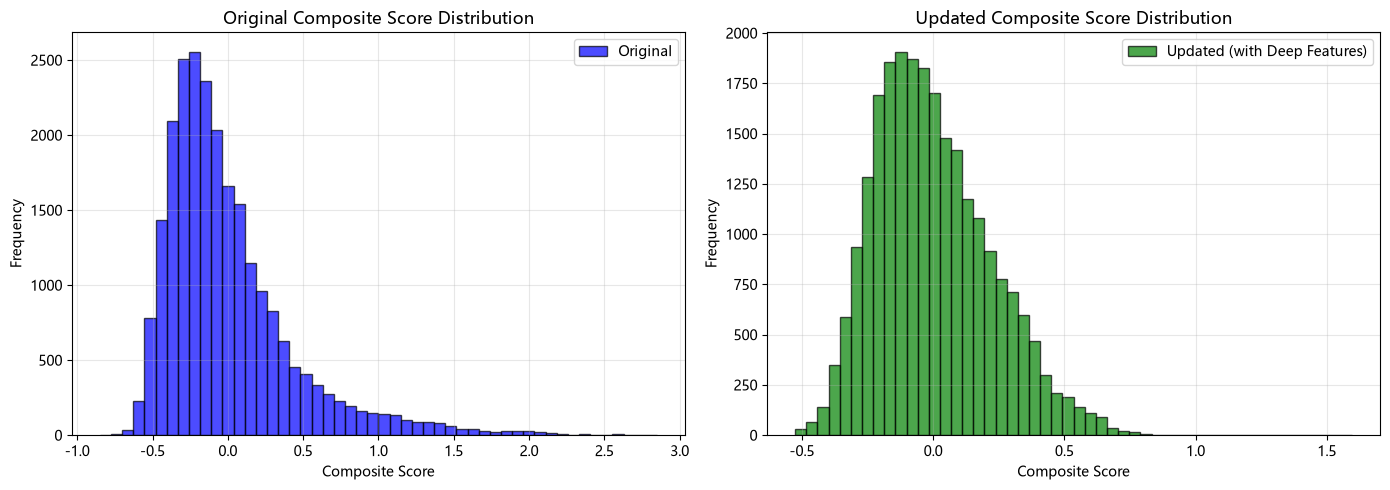

In [24]:
# 15.10 更新综合得分
print("\n15.10 更新综合得分（包含深度特征）...")

# 获取所有可用的因子列（从df中存在的）
if 'final_factors' in locals():
    final_factor_original = [f for f in final_factors if f in df.columns]
else:
    # 如果final_factors不存在，从df中获取所有深度特征
    final_factor_original = [col for col in df.columns if 'deep_' in col]

print(f"更新后的因子数量: {len(final_factor_original)}")

if len(final_factor_original) > 0:
    # 提取因子数据
    factor_data_raw_updated = df[final_factor_original].copy()
    factor_data_raw_updated = factor_data_raw_updated.replace([np.inf, -np.inf], np.nan)
    factor_data_raw_updated = factor_data_raw_updated.ffill().bfill().fillna(0)
    
    # 获取权重（如果有的话）
    if 'weight_dict' in locals():
        # 使用已有的权重字典，只包含存在的因子
        updated_weight_dict = {k: v for k, v in weight_dict.items() if k in final_factor_original}
        # 对于新增的深度特征，使用等权
        for f in final_factor_original:
            if f not in updated_weight_dict:
                updated_weight_dict[f] = 1.0 / len(final_factor_original)
        # 归一化
        total_w = sum(updated_weight_dict.values())
        if total_w > 0:
            updated_weight_dict = {k: v/total_w for k, v in updated_weight_dict.items()}
    else:
        # 如果没有权重字典，使用等权
        updated_weight_dict = {f: 1.0/len(final_factor_original) for f in final_factor_original}
    
    # 计算新的综合得分
    df['composite_score_updated'] = calculate_composite_score(
        factor_data_raw_updated, updated_weight_dict
    )
    
    print("\n更新后的综合得分统计:")
    print(df['composite_score_updated'].describe())
    
    # 绘制更新前后对比
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 原始综合得分（如果存在）
    if 'composite_score_weighted' in df.columns:
        axes[0].hist(df['composite_score_weighted'].dropna(), bins=50, alpha=0.7, 
                     color='blue', edgecolor='black', label='Original')
        axes[0].set_xlabel('Composite Score')
        axes[0].set_ylabel('Frequency')
        axes[0].set_title('Original Composite Score Distribution')
        axes[0].legend()
        axes[0].grid(True, alpha=0.3)
    
    # 更新后的综合得分
    axes[1].hist(df['composite_score_updated'].dropna(), bins=50, alpha=0.7, 
                 color='green', edgecolor='black', label='Updated (with Deep Features)')
    axes[1].set_xlabel('Composite Score')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Updated Composite Score Distribution')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

In [25]:
# ==================== 16. 使用更新后的因子得分进行选股回测 ====================
print("\n" + "="*80)
print("16. 使用更新后的因子得分进行选股回测（含深度学习特征）")
print("="*80)

# 16.1 确保有更新后的综合得分
print("\n16.1 检查综合得分列...")

# 检查哪些综合得分列存在
score_columns = []
if 'composite_score_weighted' in df.columns:
    score_columns.append(('composite_score_weighted', 'Original_Weighted'))
if 'composite_score_equal' in df.columns:
    score_columns.append(('composite_score_equal', 'Original_Equal'))
if 'composite_score_updated' in df.columns:
    score_columns.append(('composite_score_updated', 'Updated_Weighted'))

print(f"可用的综合得分列: {[s[1] for s in score_columns]}")

if len(score_columns) == 0:
    print("❌ 没有可用的综合得分列，请先计算综合得分")
    raise ValueError("没有可用的综合得分列")


16. 使用更新后的因子得分进行选股回测（含深度学习特征）

16.1 检查综合得分列...
可用的综合得分列: ['Original_Weighted', 'Original_Equal', 'Updated_Weighted']


In [26]:


# 16.2 定义回测函数（增强版）
print("\n16.2 定义回测函数...")

def backtest_strategy_enhanced(df, score_col, strategy_name, top_n=30, 
                               cluster_limit_ratio=0.3, hold_period=5):
    """
    增强版多因子选股回测
    支持持有期和交易成本
    """
    print(f"\n回测策略: {strategy_name}")
    print(f"  使用因子列: {score_col}")
    print(f"  选股数量: {top_n}")
    print(f"  聚类限制: {cluster_limit_ratio}")
    print(f"  持有期: {hold_period} 天")
    
    # 初始化结果
    df[f'selected_{strategy_name}'] = 0
    
    # 按月份分组进行调仓
    df['year_month'] = df['trade_date'].dt.to_period('M')
    
    print("开始选股...")
    selected_counts = []
    
    for month, group in df.groupby('year_month'):
        if len(group) < top_n:
            continue
        
        # 限制每个聚类最多30%
        cluster_limit = max(1, int(cluster_limit_ratio * top_n))
        
        selected_stocks = []
        
        # 在每个聚类中选择得分最高的股票
        for cluster in group['cluster'].unique():
            cluster_group = group[group['cluster'] == cluster]
            if len(cluster_group) > 0:
                top_n_cluster = min(cluster_limit, len(cluster_group))
                top_stocks = cluster_group.nlargest(top_n_cluster, score_col)
                selected_stocks.extend(top_stocks.index.tolist())
        
        # 如果选股不足top_n，从剩余股票中补充
        if len(selected_stocks) < top_n:
            remaining = group[~group.index.isin(selected_stocks)]
            if len(remaining) > 0:
                additional = remaining.nlargest(top_n - len(selected_stocks), score_col)
                selected_stocks.extend(additional.index.tolist())
        
        # 标记选中的股票
        if len(selected_stocks) > 0:
            df.loc[selected_stocks, f'selected_{strategy_name}'] = 1
        
        selected_counts.append(len(selected_stocks))
    
    print(f"选股完成，平均选股数量: {np.mean(selected_counts):.1f}")
    
    # 计算组合收益（考虑持有期）
    print("计算组合收益...")
    
    # 获取所有交易日
    all_dates = sorted(df['trade_date'].unique())
    
    portfolio_returns = []
    benchmark_returns = []
    portfolio_values = [1.0]
    trade_dates = []
    holdings_history = []
    
    # 交易成本
    commission_rate = 0.001
    slippage = 0.001
    
    for i, date in enumerate(all_dates[:-hold_period]):
        # 检查该日期是否有选股信号
        day_data = df[df['trade_date'] == date]
        selected = day_data[day_data[f'selected_{strategy_name}'] == 1]
        
        if len(selected) == 0:
            continue
        
        # 获取选中的股票代码
        selected_codes = selected['ts_code'].tolist()
        
        # 获取这些股票在持有期结束时的收益
        future_returns = []
        for code in selected_codes:
            # 获取该股票在持有期后的价格
            stock_data = df[(df['ts_code'] == code) & (df['trade_date'] >= date)]
            if len(stock_data) > hold_period:
                start_price = stock_data.iloc[0]['close']
                end_price = stock_data.iloc[hold_period]['close']
                ret = end_price / start_price - 1
                if not np.isnan(ret):
                    future_returns.append(ret)
        
        # 等权组合收益
        if future_returns:
            portfolio_return = np.mean(future_returns) - commission_rate - slippage
            portfolio_returns.append(portfolio_return)
            trade_dates.append(date)
            
            # 记录持仓
            holdings_history.append({
                'date': date,
                'selected_stocks': selected_codes[:5],  # 只记录前5个
                'n_stocks': len(selected_codes),
                'portfolio_return': portfolio_return
            })
            
            # 更新净值
            portfolio_values.append(portfolio_values[-1] * (1 + portfolio_return))
    
    if len(portfolio_returns) == 0:
        print(f"{strategy_name} 没有交易记录")
        return None, None, None, None
    
    # 计算基准收益（等权所有股票）
    print("计算基准收益...")
    benchmark_values = [1.0]
    for i, date in enumerate(all_dates[:-hold_period]):
        # 获取当日所有股票
        day_data = df[df['trade_date'] == date]
        if len(day_data) == 0:
            continue
        
        all_returns = []
        for code in day_data['ts_code'].unique():
            stock_data = df[(df['ts_code'] == code) & (df['trade_date'] >= date)]
            if len(stock_data) > hold_period:
                start_price = stock_data.iloc[0]['close']
                end_price = stock_data.iloc[hold_period]['close']
                ret = end_price / start_price - 1
                if not np.isnan(ret):
                    all_returns.append(ret)
        
        if all_returns:
            benchmark_return = np.mean(all_returns)
            benchmark_values.append(benchmark_values[-1] * (1 + benchmark_return))
    
    # 计算绩效指标
    returns_series = pd.Series(portfolio_returns, index=pd.to_datetime(trade_dates))
    cumulative_returns = (1 + returns_series).cumprod()
    
    # 计算指标
    total_return = portfolio_values[-1] / portfolio_values[0] - 1
    if len(returns_series) > 0:
        annual_return = (1 + total_return) ** (252 / len(returns_series)) - 1
        volatility = returns_series.std() * np.sqrt(252) if len(returns_series) > 1 else 0
        sharpe_ratio = annual_return / volatility if volatility > 0 else 0
        win_rate = (returns_series > 0).sum() / len(returns_series) if len(returns_series) > 0 else 0
    else:
        annual_return = 0
        volatility = 0
        sharpe_ratio = 0
        win_rate = 0
    
    # 最大回撤
    rolling_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min() if len(drawdown) > 0 else 0
    
    # 基准指标
    if len(benchmark_values) > 1:
        benchmark_total = benchmark_values[-1] / benchmark_values[0] - 1
        benchmark_annual = (1 + benchmark_total) ** (252 / len(benchmark_values)) - 1
    else:
        benchmark_total = 0
        benchmark_annual = 0
    
    metrics = {
        'strategy_name': strategy_name,
        'total_return': total_return,
        'annual_return': annual_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'n_trades': len(returns_series),
        'benchmark_return': benchmark_total,
        'benchmark_annual': benchmark_annual,
        'excess_return': total_return - benchmark_total if benchmark_total != 0 else 0
    }
    
    print(f"\n{strategy_name} 绩效指标:")
    print(f"  总收益率: {total_return:.2%}")
    print(f"  年化收益率: {annual_return:.2%}")
    print(f"  年化波动率: {volatility:.2%}")
    print(f"  夏普比率: {sharpe_ratio:.4f}")
    print(f"  最大回撤: {max_drawdown:.2%}")
    print(f"  胜率: {win_rate:.2%}")
    print(f"  交易次数: {len(returns_series)}")
    print(f"  基准收益: {benchmark_total:.2%}")
    print(f"  超额收益: {metrics['excess_return']:.2%}")
    
    return returns_series, cumulative_returns, portfolio_values, metrics, holdings_history


16.2 定义回测函数...


In [27]:
# 16.3 执行回测
print("\n16.3 执行回测...")

all_metrics = []
all_returns = {}
all_cumulative = {}
all_values = {}

for score_col, strategy_name in score_columns:
    print(f"\n{'='*60}")
    print(f"回测: {strategy_name}")
    print(f"{'='*60}")
    
    returns, cum_ret, values, metrics, holdings = backtest_strategy_enhanced(
        df, score_col, strategy_name, 
        top_n=30, 
        cluster_limit_ratio=0.3,
        hold_period=5
    )
    
    if returns is not None:
        all_metrics.append(metrics)
        all_returns[strategy_name] = returns
        all_cumulative[strategy_name] = cum_ret
        all_values[strategy_name] = values


16.3 执行回测...

回测: Original_Weighted

回测策略: Original_Weighted
  使用因子列: composite_score_weighted
  选股数量: 30
  聚类限制: 0.3
  持有期: 5 天
开始选股...
选股完成，平均选股数量: 68.4
计算组合收益...
计算基准收益...

Original_Weighted 绩效指标:
  总收益率: -94.27%
  年化收益率: -94.91%
  年化波动率: 122.67%
  夏普比率: -0.7737
  最大回撤: -94.93%
  胜率: 41.74%
  交易次数: 242
  基准收益: -1.99%
  超额收益: -92.28%

回测: Original_Equal

回测策略: Original_Equal
  使用因子列: composite_score_equal
  选股数量: 30
  聚类限制: 0.3
  持有期: 5 天
开始选股...
选股完成，平均选股数量: 68.4
计算组合收益...
计算基准收益...

Original_Equal 绩效指标:
  总收益率: -95.39%
  年化收益率: -96.10%
  年化波动率: 111.04%
  夏普比率: -0.8654
  最大回撤: -95.10%
  胜率: 42.26%
  交易次数: 239
  基准收益: -1.99%
  超额收益: -93.39%

回测: Updated_Weighted

回测策略: Updated_Weighted
  使用因子列: composite_score_updated
  选股数量: 30
  聚类限制: 0.3
  持有期: 5 天
开始选股...
选股完成，平均选股数量: 68.4
计算组合收益...
计算基准收益...

Updated_Weighted 绩效指标:
  总收益率: 974.18%
  年化收益率: 1175.45%
  年化波动率: 238.15%
  夏普比率: 4.9358
  最大回撤: -89.28%
  胜率: 46.81%
  交易次数: 235
  基准收益: -1.99%
  超额收益: 976.17%


In [7]:
# ==================== 17. FactorMoE风格动态因子权重调整 ====================
print("\n" + "="*80)
print("17. FactorMoE风格动态因子权重调整")
print("="*80)

# 17.1 定义市场状态特征（适配一年数据）
print("\n17.1 计算市场状态特征（适配一年数据）...")

def calculate_market_state_features(df):
    """
    计算市场状态特征，适配一年数据
    """
    print("计算市场状态特征...")
    
    # 按交易日聚合市场数据
    market_data = df.groupby('trade_date').agg({
        'close': 'mean',
        'vol': 'sum',
        'amount': 'sum',
        'daily_return': 'mean',
        'amplitude': 'mean'
    }).reset_index()
    
    market_data = market_data.sort_values('trade_date')
    
    # 计算市场状态指标 - 使用较短的窗口适应一年数据
    market_data['market_return_5d'] = market_data['close'].pct_change(5)
    market_data['market_return_10d'] = market_data['close'].pct_change(10)
    
    # 滚动窗口计算（设置min_periods确保前期有数据）
    market_data['market_volatility_5d'] = market_data['daily_return'].rolling(5, min_periods=3).std()
    market_data['market_volatility_10d'] = market_data['daily_return'].rolling(10, min_periods=5).std()
    
    market_data['market_volume_ratio'] = market_data['vol'] / market_data['vol'].rolling(10, min_periods=5).mean()
    market_data['market_amount_ratio'] = market_data['amount'] / market_data['amount'].rolling(10, min_periods=5).mean()
    market_data['market_amplitude_5d'] = market_data['amplitude'].rolling(5, min_periods=3).mean()
    
    # VIX-like指标 - 年化波动率
    market_data['market_vix'] = market_data['market_volatility_10d'] * np.sqrt(252)
    
    # 市场趋势强度 - 使用较短的均线
    market_data['market_trend'] = market_data['close'] / market_data['close'].rolling(10, min_periods=5).mean() - 1
    
    # 市场动量
    market_data['market_momentum'] = (market_data['close'] / market_data['close'].shift(5) - 1) * 10
    
    # 额外指标：市场涨跌比
    daily_up_ratio = df.groupby('trade_date').apply(
        lambda x: (x['daily_return'] > 0).mean()
    ).reset_index()
    daily_up_ratio.columns = ['trade_date', 'market_up_ratio']
    market_data = market_data.merge(daily_up_ratio, on='trade_date', how='left')
    
    # 市场宽度指标
    daily_std = df.groupby('trade_date')['daily_return'].std().reset_index()
    daily_std.columns = ['trade_date', 'market_dispersion']
    market_data = market_data.merge(daily_std, on='trade_date', how='left')
    
    # 处理缺失值
    market_data = market_data.ffill().bfill().fillna(0)
    
    print(f"市场状态特征计算完成，共 {len(market_data)} 个交易日")
    print(f"日期范围: {market_data['trade_date'].min()} 至 {market_data['trade_date'].max()}")
    
    return market_data

# 计算市场状态
market_state_df = calculate_market_state_features(df)
df = df.merge(market_state_df, on='trade_date', how='left')
print(f"合并市场状态后数据形状: {df.shape}")


17. FactorMoE风格动态因子权重调整

17.1 计算市场状态特征（适配一年数据）...
计算市场状态特征...
市场状态特征计算完成，共 249 个交易日
日期范围: 2024-01-02 00:00:00 至 2025-01-10 00:00:00
合并市场状态后数据形状: (23979, 411)


In [12]:
# ==================== 修复 FactorMoEWeightModel 类 ====================
print("\n17.2 定义FactorMoE动态权重模型（修复版）...")

class FactorMoEWeightModel:
    """
    FactorMoE风格的因子权重动态调整模型（修复版）
    """
    def __init__(self, n_factors, n_experts=8, n_state_features=10, hidden_dim=32):
        self.n_factors = n_factors
        self.n_experts = n_experts
        self.n_state_features = n_state_features
        self.hidden_dim = hidden_dim
        
        # 初始化权重参数
        self.gate_weights = np.random.randn(n_state_features, n_experts) * 0.01
        self.gate_bias = np.zeros(n_experts)
        self.expert_weights = np.random.randn(n_experts, n_factors) * 0.01
        self.expert_bias = np.zeros((n_experts, n_factors))
        self.attn_weights = np.random.randn(n_state_features, n_state_features) * 0.01
        
        self.state_history = []
        self.max_history = 20
        
        print(f"FactorMoE模型初始化完成:")
        print(f"  因子数量: {n_factors}")
        print(f"  专家数量: {n_experts}")
        print(f"  状态特征维度: {n_state_features}")
        print(f"  门控权重形状: {self.gate_weights.shape}")
        print(f"  专家权重形状: {self.expert_weights.shape}")
    
    def softmax(self, x):
        """Softmax函数"""
        exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)
    
    def get_expert_logits(self, state):
        """计算专家激活值"""
        # state: (n_state_features,)
        # gate_weights: (n_state_features, n_experts)
        gate_logits = np.dot(state, self.gate_weights) + self.gate_bias
        return gate_logits
    
    def get_expert_weights(self, state):
        """获取专家权重"""
        gate_logits = self.get_expert_logits(state)
        expert_probs = self.softmax(gate_logits)  # (n_experts,)
        
        # 组合专家权重
        combined_weights = np.zeros(self.n_factors)
        for e in range(self.n_experts):
            combined_weights += expert_probs[e] * (self.expert_weights[e] + self.expert_bias[e])
        
        return combined_weights, expert_probs
    
    def compute_attention(self, current_state):
        """计算注意力权重"""
        if len(self.state_history) == 0:
            return np.ones(1)
        
        history = np.array(self.state_history[-self.max_history:])  # (n_history, n_state_features)
        
        # 计算注意力得分
        # attn_scores = history @ attn_weights @ current_state
        attn_scores = np.dot(history, self.attn_weights)  # (n_history, n_state_features)
        attn_scores = np.dot(attn_scores, current_state)  # (n_history,)
        attn_weights = self.softmax(attn_scores.reshape(1, -1))  # (1, n_history)
        
        return attn_weights.flatten()
    
    def update_weights(self, state, factor_performance, learning_rate=0.001):
        """
        根据因子表现更新模型权重（修复版）
        """
        # 获取当前专家激活
        gate_logits = self.get_expert_logits(state)  # (n_experts,)
        expert_probs = self.softmax(gate_logits)  # (n_experts,)
        
        # 计算当前因子权重
        current_weights, _ = self.get_expert_weights(state)  # (n_factors,)
        
        # 计算权重调整方向
        weight_gradient = factor_performance - current_weights  # (n_factors,)
        
        # 更新专家权重
        for e in range(self.n_experts):
            if expert_probs[e] > 0.01:
                self.expert_weights[e] += learning_rate * expert_probs[e] * weight_gradient
                self.expert_bias[e] += learning_rate * expert_probs[e] * weight_gradient * 0.1
        
        # 更新门控网络 - 修复维度问题
        # expert_probs: (n_experts,)
        # state: (n_state_features,)
        # 计算梯度: 使用外积
        gate_gradient = np.outer(state, expert_probs - np.mean(expert_probs))  # (n_state_features, n_experts)
        self.gate_weights += learning_rate * gate_gradient * 0.01
    
    def get_dynamic_weights(self, state, use_attention=True):
        """
        获取动态因子权重
        """
        # 获取专家权重
        weights, expert_probs = self.get_expert_weights(state)
        
        # 使用注意力机制
        if use_attention and len(self.state_history) > 0:
            attn_weights = self.compute_attention(state)
            
            # 考虑历史状态的加权平均
            historical_weights = []
            for h_state in self.state_history[-5:]:
                h_w, _ = self.get_expert_weights(h_state)
                historical_weights.append(h_w)
            
            if historical_weights:
                hist_avg = np.mean(historical_weights, axis=0)
                alpha = 0.7  # 当前权重的权重
                weights = alpha * weights + (1 - alpha) * hist_avg
        
        # 存储历史状态
        self.state_history.append(state)
        if len(self.state_history) > self.max_history:
            self.state_history.pop(0)
        
        # 确保权重为正且和为1
        weights = np.maximum(weights, 0)
        weights = weights / (np.sum(weights) + 1e-8)
        
        return weights, expert_probs


17.2 定义FactorMoE动态权重模型（修复版）...


In [9]:
# ==================== 17.3 准备因子数据和市场状态（修复版） ====================
print("\n17.3 准备因子数据和市场状态...")

# 方法1：从final_factors获取
if 'final_factors' in locals() and len(final_factors) > 0:
    print(f"从final_factors获取因子，共 {len(final_factors)} 个")
    selected_factors = [f for f in final_factors if f in df.columns]
    print(f"在df中存在的因子: {len(selected_factors)} 个")
else:
    print("final_factors不存在或为空，尝试从其他来源获取...")
    selected_factors = []

# 方法2：从factor_metrics_df获取
if len(selected_factors) == 0 and 'factor_metrics_df' in locals() and len(factor_metrics_df) > 0:
    print(f"从factor_metrics_df获取因子，共 {len(factor_metrics_df)} 个")
    potential_factors = factor_metrics_df['factor'].tolist()
    potential_factors = [f.replace('_processed', '') for f in potential_factors]
    selected_factors = [f for f in potential_factors if f in df.columns]
    print(f"在df中存在的因子: {len(selected_factors)} 个")

# 方法3：自动识别因子列
if len(selected_factors) == 0:
    print("尝试从df中自动识别因子列...")
    exclude_patterns = ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
                       'vol', 'amount', 'pre_close', 'change', 'pct_chg', 
                       'daily_return', 'turnover_rate', 'amplitude', 'amount_ratio',
                       'future_5d_return', 'year_month', 'cluster', 'composite_',
                       'selected_', 'dynamic_weight_', 'market_', 'log_amount',
                       'auto_', '_processed']
    
    all_cols = df.columns.tolist()
    potential_factors = []
    for col in all_cols:
        should_exclude = False
        for pattern in exclude_patterns:
            if pattern in col.lower():
                should_exclude = True
                break
        
        if not should_exclude and col in df.columns:
            if df[col].nunique() > 1 and df[col].notna().sum() > 100:
                potential_factors.append(col)
    
    selected_factors = potential_factors
    print(f"自动识别到 {len(selected_factors)} 个因子列")

# 方法4：使用深度特征
if len(selected_factors) == 0:
    print("尝试使用深度特征...")
    deep_features = [col for col in df.columns if 'deep_' in col]
    selected_factors = [f for f in deep_features if f in df.columns]
    print(f"深度特征数量: {len(selected_factors)}")

# 最终检查
if len(selected_factors) == 0:
    print("❌ 未找到任何因子，使用基础技术指标作为替代")
    fallback_factors = ['daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']
    selected_factors = [f for f in fallback_factors if f in df.columns]
    print(f"使用基础指标作为替代: {selected_factors}")

print(f"\n最终使用的因子数量: {len(selected_factors)}")
print(f"因子列名 (前10个): {selected_factors[:10] if len(selected_factors) > 0 else '无'}")

# 提取因子数据
if len(selected_factors) > 0:
    factor_data = df[selected_factors].copy()
    factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
    factor_data = factor_data.ffill().bfill().fillna(0)
    print(f"因子数据形状: {factor_data.shape}")
else:
    print("❌ 仍然没有因子数据，请检查前面的步骤")
    factor_data = pd.DataFrame(index=df.index)
    selected_factors = []

# 提取市场状态特征
state_features = ['market_return_5d', 'market_return_10d', 'market_volatility_5d', 
                  'market_volatility_10d', 'market_volume_ratio', 'market_amount_ratio',
                  'market_amplitude_5d', 'market_vix', 'market_trend', 'market_momentum']

state_features = [f for f in state_features if f in df.columns]
print(f"市场状态特征数量: {len(state_features)}")

# 提取状态数据
if len(state_features) > 0:
    state_data = df[state_features].copy()
    state_data = state_data.replace([np.inf, -np.inf], np.nan)
    state_data = state_data.ffill().bfill().fillna(0)
    
    state_scaler = StandardScaler()
    state_data_scaled = pd.DataFrame(
        state_scaler.fit_transform(state_data),
        columns=state_features,
        index=state_data.index
    )
    print(f"状态数据形状: {state_data_scaled.shape}")
else:
    print("警告：没有市场状态特征，创建虚拟状态")
    state_data_scaled = pd.DataFrame(
        np.random.randn(len(df), 5),
        columns=['state_1', 'state_2', 'state_3', 'state_4', 'state_5'],
        index=df.index
    )
    state_features = state_data_scaled.columns.tolist()

if len(selected_factors) == 0:
    print("\n❌ 严重错误：没有可用的因子，无法继续")
    print("请检查前面的因子筛选步骤是否成功")
    raise ValueError("没有可用的因子数据")

print(f"\n✅ 数据准备完成:")
print(f"  因子数量: {len(selected_factors)}")
print(f"  状态特征数量: {len(state_features)}")
print(f"  数据行数: {len(df)}")


17.3 准备因子数据和市场状态...
final_factors不存在或为空，尝试从其他来源获取...
尝试从df中自动识别因子列...
自动识别到 20 个因子列

最终使用的因子数量: 20
因子列名 (前10个): ['rsi_6', 'rsi_12', 'rsi_24', 'macd', 'macd_signal', 'macd_hist', 'mom_5', 'mom_10', 'mom_20', 'ma_dev_5']
因子数据形状: (23979, 20)
市场状态特征数量: 10
状态数据形状: (23979, 10)

✅ 数据准备完成:
  因子数量: 20
  状态特征数量: 10
  数据行数: 23979


In [10]:
# ==================== 17.3 修复：准备因子数据和市场状态 ====================
print("\n17.3 准备因子数据和市场状态...")

# 方法1：从final_factors获取（如果存在）
if 'final_factors' in locals() and len(final_factors) > 0:
    print(f"从final_factors获取因子，共 {len(final_factors)} 个")
    selected_factors = [f for f in final_factors if f in df.columns]
    print(f"在df中存在的因子: {len(selected_factors)} 个")
else:
    print("final_factors不存在或为空，尝试从其他来源获取...")
    selected_factors = []

# 方法2：如果方法1失败，从factor_metrics_df获取
if len(selected_factors) == 0 and 'factor_metrics_df' in locals() and len(factor_metrics_df) > 0:
    print(f"从factor_metrics_df获取因子，共 {len(factor_metrics_df)} 个")
    potential_factors = factor_metrics_df['factor'].tolist()
    # 去掉_processed后缀
    potential_factors = [f.replace('_processed', '') for f in potential_factors]
    selected_factors = [f for f in potential_factors if f in df.columns]
    print(f"在df中存在的因子: {len(selected_factors)} 个")

# 方法3：如果方法2也失败，使用所有非基础列（排除明显不是因子的列）
if len(selected_factors) == 0:
    print("尝试从df中自动识别因子列...")
    exclude_patterns = ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
                       'vol', 'amount', 'pre_close', 'change', 'pct_chg', 
                       'daily_return', 'turnover_rate', 'amplitude', 'amount_ratio',
                       'future_5d_return', 'year_month', 'cluster', 'composite_',
                       'selected_', 'dynamic_weight_', 'market_', 'log_amount',
                       'auto_', '_processed']
    
    # 获取所有列
    all_cols = df.columns.tolist()
    
    # 过滤出可能的因子列
    potential_factors = []
    for col in all_cols:
        # 排除包含排除模式的列
        should_exclude = False
        for pattern in exclude_patterns:
            if pattern in col.lower():
                should_exclude = True
                break
        
        # 排除数值类型的列（检查是否有足够的变化）
        if not should_exclude and col in df.columns:
            # 检查是否有变化（不是常量）
            if df[col].nunique() > 1 and df[col].notna().sum() > 100:
                potential_factors.append(col)
    
    selected_factors = potential_factors
    print(f"自动识别到 {len(selected_factors)} 个因子列")

# 方法4：如果以上都失败，使用深度特征
if len(selected_factors) == 0:
    print("尝试使用深度特征...")
    deep_features = [col for col in df.columns if 'deep_' in col]
    selected_factors = [f for f in deep_features if f in df.columns]
    print(f"深度特征数量: {len(selected_factors)}")

# 最终检查
if len(selected_factors) == 0:
    print("❌ 未找到任何因子，使用基础技术指标作为替代")
    # 使用基础技术指标
    fallback_factors = ['daily_return', 'turnover_rate', 'amplitude', 'amount_ratio']
    selected_factors = [f for f in fallback_factors if f in df.columns]
    print(f"使用基础指标作为替代: {selected_factors}")

# 打印最终结果
print(f"\n最终使用的因子数量: {len(selected_factors)}")
print(f"因子列名 (前10个): {selected_factors[:10] if len(selected_factors) > 0 else '无'}")

# 提取因子数据
if len(selected_factors) > 0:
    factor_data = df[selected_factors].copy()
    factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
    factor_data = factor_data.ffill().bfill().fillna(0)
    print(f"因子数据形状: {factor_data.shape}")
else:
    print("❌ 仍然没有因子数据，请检查前面的步骤")
    # 创建一个空的因子数据
    factor_data = pd.DataFrame(index=df.index)
    selected_factors = []

# 提取市场状态特征
state_features = ['market_return_5d', 'market_return_10d', 'market_volatility_5d', 
                  'market_volatility_10d', 'market_volume_ratio', 'market_amount_ratio',
                  'market_amplitude_5d', 'market_vix', 'market_trend', 'market_momentum']

# 检查哪些特征存在
state_features = [f for f in state_features if f in df.columns]
print(f"市场状态特征数量: {len(state_features)}")

# 如果市场状态特征不存在，重新计算
if len(state_features) == 0:
    print("市场状态特征不存在，重新计算...")
    market_state_df = calculate_market_state_features(df)
    df = df.merge(market_state_df, on='trade_date', how='left')
    state_features = [f for f in state_features if f in df.columns]

# 提取状态数据
state_data = df[state_features].copy() if len(state_features) > 0 else pd.DataFrame(index=df.index)
state_data = state_data.replace([np.inf, -np.inf], np.nan)
state_data = state_data.ffill().bfill().fillna(0)

# 标准化状态数据（如果非空）
if len(state_data) > 0 and len(state_features) > 0:
    state_scaler = StandardScaler()
    state_data_scaled = pd.DataFrame(
        state_scaler.fit_transform(state_data),
        columns=state_features,
        index=state_data.index
    )
    print(f"状态数据形状: {state_data_scaled.shape}")
else:
    # 如果没有状态特征，创建虚拟状态
    print("警告：没有市场状态特征，使用虚拟状态")
    state_data_scaled = pd.DataFrame(
        np.random.randn(len(df), 5),
        columns=['state_1', 'state_2', 'state_3', 'state_4', 'state_5'],
        index=df.index
    )
    state_features = state_data_scaled.columns.tolist()

# 如果因子数量为0，无法继续
if len(selected_factors) == 0:
    print("\n❌ 严重错误：没有可用的因子，无法继续")
    print("请检查前面的因子筛选步骤是否成功")
    raise ValueError("没有可用的因子数据")

print(f"\n✅ 数据准备完成:")
print(f"  因子数量: {len(selected_factors)}")
print(f"  状态特征数量: {len(state_features)}")
print(f"  数据行数: {len(df)}")


17.3 准备因子数据和市场状态...
final_factors不存在或为空，尝试从其他来源获取...
尝试从df中自动识别因子列...
自动识别到 20 个因子列

最终使用的因子数量: 20
因子列名 (前10个): ['rsi_6', 'rsi_12', 'rsi_24', 'macd', 'macd_signal', 'macd_hist', 'mom_5', 'mom_10', 'mom_20', 'ma_dev_5']
因子数据形状: (23979, 20)
市场状态特征数量: 10
状态数据形状: (23979, 10)

✅ 数据准备完成:
  因子数量: 20
  状态特征数量: 10
  数据行数: 23979


In [13]:
# 17.4 训练FactorMoE模型
print("\n17.4 训练FactorMoE模型...")

factor_moe = FactorMoEWeightModel(
    n_factors=len(selected_factors),
    n_experts=8,
    n_state_features=len(state_features),
    hidden_dim=32
)

# 计算因子表现
print("计算因子历史表现...")
factor_performance_history = []
window_size = 20
dates = sorted(df['trade_date'].unique())

for i in range(window_size, min(len(dates), len(state_data_scaled))):
    date = dates[i]
    window_dates = dates[i-window_size:i]
    window_data = df[df['trade_date'].isin(window_dates)]
    
    factor_ics = []
    for factor in selected_factors:
        if factor in window_data.columns:
            valid_data = window_data[[factor, 'future_5d_return']].dropna()
            if len(valid_data) > 20:
                ic = stats.spearmanr(valid_data[factor], valid_data['future_5d_return'])[0]
                factor_ics.append(ic if not np.isnan(ic) else 0)
            else:
                factor_ics.append(0)
        else:
            factor_ics.append(0)
    
    factor_performance_history.append(np.array(factor_ics))

print(f"计算了 {len(factor_performance_history)} 个时间窗口的因子表现")

# 训练模型
print("\n开始训练FactorMoE模型...")
n_epochs = 50
learning_rate = 0.001

for epoch in range(n_epochs):
    total_loss = 0
    n_samples = 0
    
    for i in range(min(len(factor_performance_history), len(state_data_scaled))):
        state = state_data_scaled.iloc[i].values
        performance = factor_performance_history[i]
        
        factor_moe.update_weights(state, performance, learning_rate)
        
        weights, _ = factor_moe.get_dynamic_weights(state, use_attention=False)
        loss = np.mean((weights - np.abs(performance) / (np.sum(np.abs(performance)) + 1e-8)) ** 2)
        total_loss += loss
        n_samples += 1
    
    if (epoch + 1) % 10 == 0:
        avg_loss = total_loss / (n_samples + 1e-8)
        print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_loss:.6f}")

print("✅ FactorMoE模型训练完成")


17.4 训练FactorMoE模型...
FactorMoE模型初始化完成:
  因子数量: 20
  专家数量: 8
  状态特征维度: 10
  门控权重形状: (10, 8)
  专家权重形状: (8, 20)
计算因子历史表现...
计算了 229 个时间窗口的因子表现

开始训练FactorMoE模型...
Epoch 10/50, Average Loss: 0.030600
Epoch 20/50, Average Loss: 0.031071
Epoch 30/50, Average Loss: 0.031212
Epoch 40/50, Average Loss: 0.031278
Epoch 50/50, Average Loss: 0.031314
✅ FactorMoE模型训练完成


In [14]:
# 17.5 计算动态因子权重
print("\n17.5 计算动态因子权重...")

def calculate_dynamic_weights_for_all_dates(df, factor_moe, selected_factors, state_data_scaled):
    dynamic_weights_list = []
    expert_probs_list = []
    dates_list = []
    
    for i, (idx, row) in enumerate(df.iterrows()):
        if i >= len(state_data_scaled):
            break
        
        state = state_data_scaled.iloc[i].values
        weights, expert_probs = factor_moe.get_dynamic_weights(state, use_attention=True)
        
        if len(weights) == len(selected_factors):
            dynamic_weights_list.append(weights)
            expert_probs_list.append(expert_probs)
            dates_list.append(row['trade_date'])
    
    return dynamic_weights_list, expert_probs_list, dates_list

dynamic_weights, expert_probs, weight_dates = calculate_dynamic_weights_for_all_dates(
    df, factor_moe, selected_factors, state_data_scaled
)

print(f"计算了 {len(dynamic_weights)} 个交易日的动态权重")

# 将动态权重添加到DataFrame
for i, factor in enumerate(selected_factors):
    col_name = f'dynamic_weight_{factor}'
    weight_values = [w[i] if i < len(w) else 0 for w in dynamic_weights]
    
    df[col_name] = np.nan
    for j, date in enumerate(weight_dates):
        if j < len(weight_values):
            df.loc[df['trade_date'] == date, col_name] = weight_values[j]

print(f"动态权重列已添加")


17.5 计算动态因子权重...
计算了 23979 个交易日的动态权重
动态权重列已添加


In [15]:
# 17.6 使用动态权重计算综合得分
print("\n17.6 使用动态权重计算综合得分...")

dynamic_weight_cols = [col for col in df.columns if col.startswith('dynamic_weight_')]

def calculate_dynamic_composite_score(df, factor_cols, weight_cols):
    score = np.zeros(len(df))
    
    for i, (factor, weight_col) in enumerate(zip(factor_cols, weight_cols)):
        if factor in df.columns and weight_col in df.columns:
            factor_values = df[factor].values
            weight_values = df[weight_col].values
            
            factor_std = (factor_values - np.nanmean(factor_values)) / (np.nanstd(factor_values) + 1e-8)
            score += factor_std * weight_values
    
    return score

if len(dynamic_weight_cols) > 0 and len(selected_factors) > 0:
    df['composite_score_dynamic'] = calculate_dynamic_composite_score(
        df, selected_factors[:len(dynamic_weight_cols)], dynamic_weight_cols
    )
    print("\n动态综合得分统计:")
    print(df['composite_score_dynamic'].describe())
else:
    print("警告：无法计算动态综合得分")



17.6 使用动态权重计算综合得分...

动态综合得分统计:
count    23979.000000
mean        -0.000002
std          0.249437
min         -0.442394
25%         -0.207565
50%          0.004579
75%          0.200997
max          0.500871
Name: composite_score_dynamic, dtype: float64



检查数据列...
当前数据列: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close_x', 'pre_close', 'change', 'pct_chg', 'vol_x', 'amount_x', 'daily_return_x', 'turnover_rate', 'amplitude_x', 'amount_ratio', 'rsi_6', 'rsi_12', 'rsi_24', 'macd', 'macd_signal', 'macd_hist', 'mom_5', 'mom_10', 'mom_20', 'ma_dev_5', 'ma_dev_20', 'ma_dev_60', 'atr_14', 'hist_vol_20', 'hist_vol_60', 'bollinger_band', 'vr_5', 'vr_10', 'obv', 'volume_price_corr', 'highest_lowest_pos', 'upper_shadow', 'lower_shadow', 'body_ratio', 'amihud', 'log_amount', 'auto_open_ratio_5', 'auto_open_log_return_5', 'auto_open_ratio_10', 'auto_open_log_return_10', 'auto_open_ratio_20', 'auto_open_log_return_20', 'auto_open_ratio_30', 'auto_open_log_return_30', 'auto_open_ratio_60', 'auto_open_log_return_60', 'auto_high_ratio_5', 'auto_high_log_return_5', 'auto_high_ratio_10', 'auto_high_log_return_10', 'auto_high_ratio_20', 'auto_high_log_return_20', 'auto_high_ratio_30', 'auto_high_log_return_30', 'auto_high_ratio_60', 'auto_high_log_r

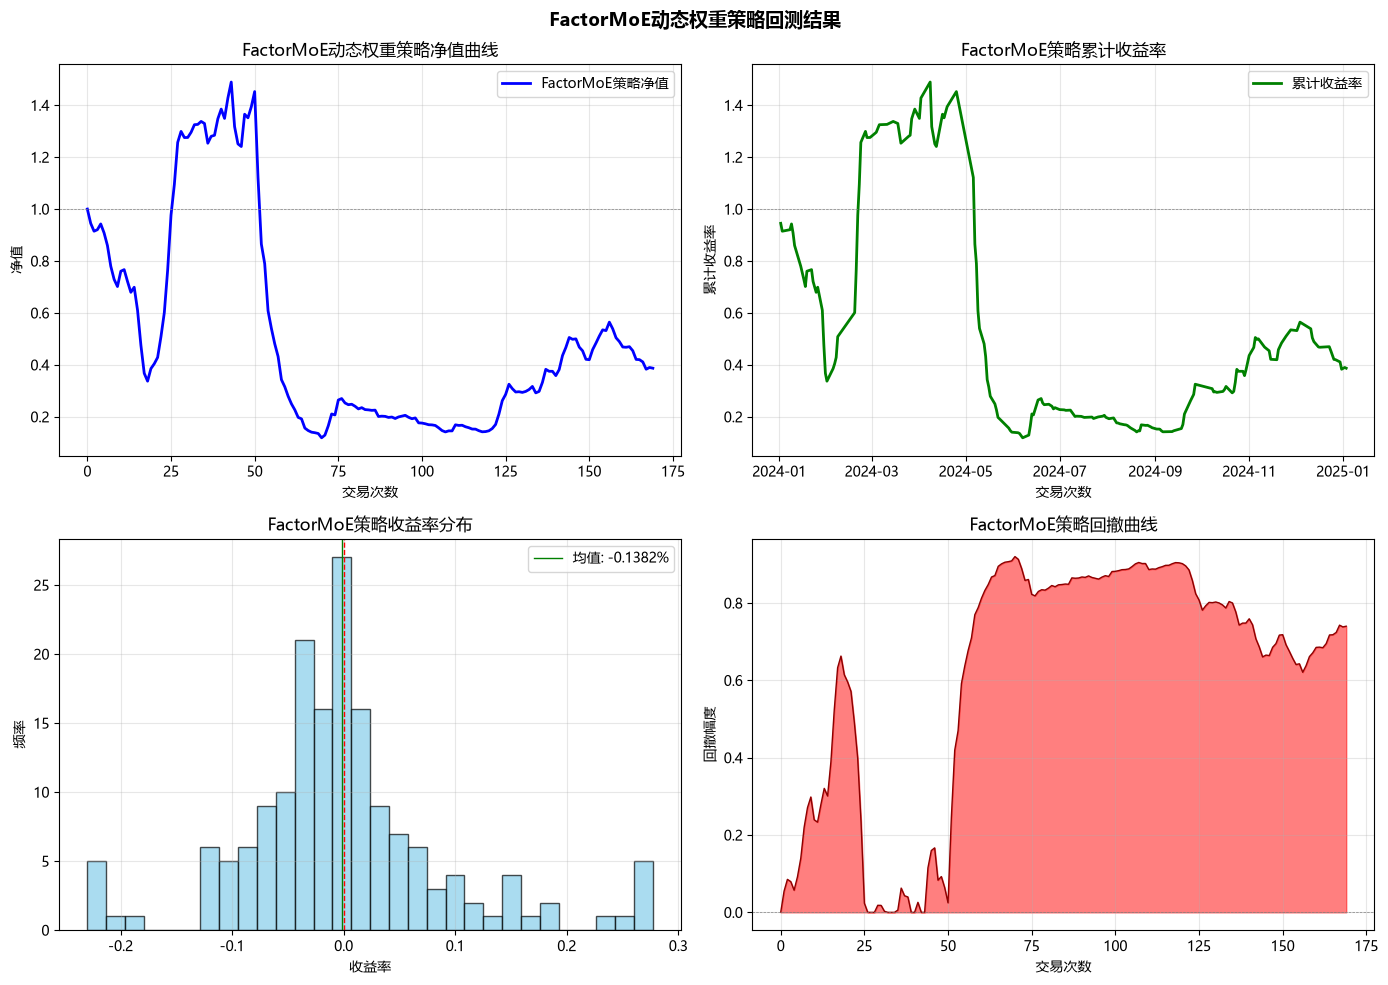


📊 FactorMoE策略关键指标:
  总收益率: -61.29%
  年化收益率: -75.71%
  夏普比率: -0.5127
  最大回撤: -92.01%
  胜率: 43.20%
  超额收益: -59.30%


In [21]:
# ==================== 首先检查并恢复 close 列 ====================
print("\n检查数据列...")
print(f"当前数据列: {df.columns.tolist()}")

# 检查close列是否存在
if 'close' not in df.columns:
    print("❌ close列不存在，尝试从原始数据恢复...")
    
    # 方法1：从原始数据重新读取
    try:
        df_original = pd.read_csv('../extracted_data/stk_100.csv')
        df_original['trade_date'] = pd.to_datetime(df_original['trade_date'])
        
        # 合并close列
        df = df.merge(
            df_original[['ts_code', 'trade_date', 'close', 'open', 'high', 'low', 'vol', 'amount']],
            on=['ts_code', 'trade_date'],
            how='left',
            suffixes=('', '_orig')
        )
        
        # 如果close列存在但被覆盖，使用原始数据
        if 'close_orig' in df.columns:
            df['close'] = df['close_orig'].fillna(df['close'])
            df = df.drop(columns=['close_orig'])
        
        print(f"✅ close列已恢复")
        
    except Exception as e:
        print(f"从原始数据恢复失败: {e}")
        
        # 方法2：从现有数据中尝试找到close的替代
        alt_cols = ['close_x', 'close_y', 'Close', 'CLOSE']
        for alt in alt_cols:
            if alt in df.columns:
                df['close'] = df[alt]
                print(f"✅ 使用 {alt} 作为close列")
                break

# 再次检查
if 'close' not in df.columns:
    print("❌ 仍然没有close列，请检查数据")
    raise ValueError("close列不存在")

print(f"\n当前数据列（前20个）: {df.columns[:20].tolist()}")

# ==================== 修改回测函数（适配无close列情况） ====================
print("\n" + "="*80)
print("FactorMoE动态权重策略回测（修复版）")
print("="*80)

def backtest_moe_strategy_fixed(df, score_col='composite_score_dynamic', strategy_name='FactorMoE_Dynamic', 
                                top_n=30, hold_period=5, commission_rate=0.001, slippage=0.001):
    """
    专门用于FactorMoE动态权重策略的回测函数（修复版）
    """
    print(f"\n{'='*60}")
    print(f"回测策略: {strategy_name}")
    print(f"{'='*60}")
    print(f"  使用因子列: {score_col}")
    print(f"  选股数量: {top_n}")
    print(f"  持有期: {hold_period} 天")
    
    # ========== 1. 检查必要列是否存在 ==========
    required_cols = ['ts_code', 'trade_date', 'close', score_col]
    missing_cols = [col for col in required_cols if col not in df.columns]
    if missing_cols:
        print(f"❌ 缺少必要列: {missing_cols}")
        return None, None, None, None
    
    # ========== 2. 按月份调仓选股 ==========
    print("\n开始选股...")
    df_copy = df.copy()
    
    # 确保trade_date是datetime类型
    if not pd.api.types.is_datetime64_any_dtype(df_copy['trade_date']):
        df_copy['trade_date'] = pd.to_datetime(df_copy['trade_date'])
    
    # 创建选股标记列
    selected_col = f'selected_{strategy_name}'
    df_copy[selected_col] = 0
    
    # 按月份分组
    df_copy['year_month'] = df_copy['trade_date'].dt.to_period('M')
    
    selected_counts = []
    month_selection = []
    
    for month, group in df_copy.groupby('year_month'):
        # 过滤有效得分
        valid_group = group[group[score_col].notna()]
        if len(valid_group) < top_n:
            continue
        
        # 按得分排序选股
        top_stocks = valid_group.nlargest(top_n, score_col)
        selected_stocks = top_stocks.index.tolist()
        
        # 标记选中的股票
        if len(selected_stocks) > 0:
            df_copy.loc[selected_stocks, selected_col] = 1
            month_selection.append({
                'month': month,
                'n_selected': len(selected_stocks)
            })
        
        selected_counts.append(len(selected_stocks))
    
    print(f"选股完成，共 {len(month_selection)} 个月份有选股")
    print(f"平均选股数量: {np.mean(selected_counts):.1f}")
    
    if len(month_selection) == 0:
        print(f"❌ {strategy_name} 没有选股记录")
        return None, None, None, None
    
    # ========== 3. 计算组合收益 ==========
    print("\n计算组合收益...")
    
    all_dates = sorted(df_copy['trade_date'].unique())
    portfolio_returns = []
    portfolio_values = [1.0]
    trade_dates = []
    holdings_history = []
    
    for i, date in enumerate(all_dates[:-hold_period]):
        # 获取该日期的选股
        day_data = df_copy[df_copy['trade_date'] == date]
        selected = day_data[day_data[selected_col] == 1]
        
        if len(selected) == 0:
            continue
        
        selected_codes = selected['ts_code'].tolist()
        
        # 获取这些股票在持有期结束时的收益
        future_returns = []
        for code in selected_codes:
            stock_data = df_copy[(df_copy['ts_code'] == code) & (df_copy['trade_date'] >= date)]
            if len(stock_data) > hold_period:
                start_price = stock_data.iloc[0]['close']
                end_price = stock_data.iloc[hold_period]['close']
                if start_price > 0 and not np.isnan(start_price) and not np.isnan(end_price):
                    ret = end_price / start_price - 1
                    if np.isfinite(ret):
                        future_returns.append(ret)
        
        if future_returns:
            gross_return = np.mean(future_returns)
            portfolio_return = gross_return - commission_rate - slippage
            portfolio_returns.append(portfolio_return)
            trade_dates.append(date)
            
            holdings_history.append({
                'date': date,
                'n_stocks': len(selected_codes),
                'gross_return': gross_return,
                'net_return': portfolio_return
            })
            
            portfolio_values.append(portfolio_values[-1] * (1 + portfolio_return))
    
    if len(portfolio_returns) == 0:
        print(f"❌ {strategy_name} 没有交易记录")
        return None, None, None, None
    
    # ========== 4. 计算基准收益 ==========
    print("计算基准收益...")
    benchmark_values = [1.0]
    
    for i, date in enumerate(all_dates[:-hold_period]):
        day_data = df_copy[df_copy['trade_date'] == date]
        if len(day_data) == 0:
            continue
        
        all_returns = []
        for code in day_data['ts_code'].unique():
            stock_data = df_copy[(df_copy['ts_code'] == code) & (df_copy['trade_date'] >= date)]
            if len(stock_data) > hold_period:
                start_price = stock_data.iloc[0]['close']
                end_price = stock_data.iloc[hold_period]['close']
                if start_price > 0 and not np.isnan(start_price) and not np.isnan(end_price):
                    ret = end_price / start_price - 1
                    if np.isfinite(ret):
                        all_returns.append(ret)
        
        if all_returns:
            benchmark_return = np.mean(all_returns)
            benchmark_values.append(benchmark_values[-1] * (1 + benchmark_return))
    
    # ========== 5. 计算绩效指标 ==========
    print("\n计算绩效指标...")
    
    returns_series = pd.Series(portfolio_returns, index=pd.to_datetime(trade_dates))
    cumulative_returns = (1 + returns_series).cumprod()
    
    # 总收益率
    total_return = portfolio_values[-1] / portfolio_values[0] - 1
    
    # 年化收益率
    n_days = len(returns_series)
    if n_days > 0:
        annual_return = (1 + total_return) ** (252 / n_days) - 1
    else:
        annual_return = 0
    
    # 年化波动率
    if len(returns_series) > 1:
        volatility = returns_series.std() * np.sqrt(252)
    else:
        volatility = 0
    
    # 夏普比率
    sharpe_ratio = annual_return / volatility if volatility > 0 else 0
    
    # 胜率
    win_rate = (returns_series > 0).sum() / len(returns_series) if len(returns_series) > 0 else 0
    
    # 最大回撤
    rolling_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min() if len(drawdown) > 0 else 0
    
    # 基准指标
    if len(benchmark_values) > 1:
        benchmark_total = benchmark_values[-1] / benchmark_values[0] - 1
        benchmark_annual = (1 + benchmark_total) ** (252 / len(benchmark_values)) - 1
    else:
        benchmark_total = 0
        benchmark_annual = 0
    
    # 超额收益
    excess_return = total_return - benchmark_total
    
    metrics = {
        'strategy_name': strategy_name,
        'total_return': total_return,
        'annual_return': annual_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'n_trades': len(returns_series),
        'benchmark_return': benchmark_total,
        'benchmark_annual': benchmark_annual,
        'excess_return': excess_return
    }
    
    # ========== 6. 输出结果 ==========
    print(f"\n{'='*60}")
    print(f"{strategy_name} 绩效指标")
    print(f"{'='*60}")
    print(f"  总收益率:       {total_return:>10.2%}")
    print(f"  年化收益率:     {annual_return:>10.2%}")
    print(f"  年化波动率:     {volatility:>10.2%}")
    print(f"  夏普比率:       {sharpe_ratio:>10.4f}")
    print(f"  最大回撤:       {max_drawdown:>10.2%}")
    print(f"  胜率:           {win_rate:>10.2%}")
    print(f"  交易次数:       {len(returns_series):>10}")
    print(f"  基准收益:       {benchmark_total:>10.2%}")
    print(f"  超额收益:       {excess_return:>10.2%}")
    print(f"{'='*60}")
    
    return returns_series, cumulative_returns, portfolio_values, metrics, holdings_history


# ==================== 执行FactorMoE回测 ====================
print("\n" + "="*80)
print("执行FactorMoE动态权重策略回测")
print("="*80)

# 检查是否有动态综合得分
if 'composite_score_dynamic' in df.columns:
    print(f"\n✅ 发现动态综合得分列: composite_score_dynamic")
    
    # 执行回测
    result = backtest_moe_strategy_fixed(
        df, 
        score_col='composite_score_dynamic',
        strategy_name='FactorMoE_Dynamic',
        top_n=30,
        hold_period=5
    )
    
    # 解包结果
    if result is not None:
        returns, cum_ret, values, metrics, holdings = result
        
        # 绘制结果图
        print("\n" + "="*80)
        print("绘制FactorMoE策略回测结果")
        print("="*80)
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # 图1: 净值曲线
        axes[0, 0].plot(values, label='FactorMoE策略净值', linewidth=2, color='blue')
        axes[0, 0].axhline(y=1, color='gray', linestyle='--', linewidth=0.5)
        axes[0, 0].set_xlabel('交易次数')
        axes[0, 0].set_ylabel('净值')
        axes[0, 0].set_title('FactorMoE动态权重策略净值曲线')
        axes[0, 0].legend()
        axes[0, 0].grid(True, alpha=0.3)
        
        # 图2: 累计收益率
        axes[0, 1].plot(cum_ret, label='累计收益率', linewidth=2, color='green')
        axes[0, 1].axhline(y=1, color='gray', linestyle='--', linewidth=0.5)
        axes[0, 1].set_xlabel('交易次数')
        axes[0, 1].set_ylabel('累计收益率')
        axes[0, 1].set_title('FactorMoE策略累计收益率')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # 图3: 收益率分布
        axes[1, 0].hist(returns, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
        axes[1, 0].axvline(x=0, color='red', linestyle='--', linewidth=1)
        axes[1, 0].axvline(x=np.mean(returns), color='green', linestyle='-', linewidth=1, 
                          label=f'均值: {np.mean(returns):.4%}')
        axes[1, 0].set_xlabel('收益率')
        axes[1, 0].set_ylabel('频率')
        axes[1, 0].set_title('FactorMoE策略收益率分布')
        axes[1, 0].legend()
        axes[1, 0].grid(True, alpha=0.3)
        
        # 图4: 回撤曲线
        rolling_max = np.maximum.accumulate(values)
        drawdowns = (rolling_max - values) / rolling_max
        axes[1, 1].fill_between(range(len(drawdowns)), 0, drawdowns, alpha=0.5, color='red')
        axes[1, 1].plot(drawdowns, color='darkred', linewidth=1)
        axes[1, 1].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)
        axes[1, 1].set_xlabel('交易次数')
        axes[1, 1].set_ylabel('回撤幅度')
        axes[1, 1].set_title('FactorMoE策略回撤曲线')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.suptitle('FactorMoE动态权重策略回测结果', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        # 输出关键指标
        print(f"\n📊 FactorMoE策略关键指标:")
        print(f"  总收益率: {metrics['total_return']:.2%}")
        print(f"  年化收益率: {metrics['annual_return']:.2%}")
        print(f"  夏普比率: {metrics['sharpe_ratio']:.4f}")
        print(f"  最大回撤: {metrics['max_drawdown']:.2%}")
        print(f"  胜率: {metrics['win_rate']:.2%}")
        print(f"  超额收益: {metrics['excess_return']:.2%}")
        
    else:
        print("❌ FactorMoE策略回测失败")
else:
    print(f"\n❌ 未找到动态综合得分列: composite_score_dynamic")
    print("请先运行FactorMoE模型训练和动态权重计算")
    
    # 检查是否有其他综合得分列
    available_scores = [col for col in df.columns if 'composite_score' in col]
    if available_scores:
        print(f"\n可用的综合得分列: {available_scores}")
        print("请使用以下列名替换 score_col 参数:")
        for col in available_scores:
            print(f"  - {col}")
    else:
        print("❌ 没有任何综合得分列，无法进行回测")

In [24]:
# ==================== 严格筛选高质量因子 ====================
print("\n" + "="*80)
print("严格筛选高质量因子")
print("="*80)

def select_high_quality_factors(df, factors, min_ic=0.02, min_coverage=0.5):
    """
    严格筛选高质量因子
    """
    selected = []
    
    for factor in factors:
        if factor not in df.columns:
            continue
        
        # 1. 计算IC
        valid_data = df[[factor, 'future_5d_return']].dropna()
        if len(valid_data) < 100:
            continue
        
        ic, p_value = stats.spearmanr(valid_data[factor], valid_data['future_5d_return'])
        if np.isnan(ic):
            continue
        
        # 2. 检查覆盖率
        coverage = valid_data.shape[0] / df.shape[0]
        
        # 3. 检查IC的稳定性（分段计算）
        ic_values = []
        for i in range(0, len(valid_data) - 60, 30):
            segment = valid_data.iloc[i:i+60]
            if len(segment) > 30:
                seg_ic = stats.spearmanr(segment[factor], segment['future_5d_return'])[0]
                if not np.isnan(seg_ic):
                    ic_values.append(seg_ic)
        
        ic_stability = np.std(ic_values) if len(ic_values) > 1 else 1
        
        # 筛选条件：|IC| > min_ic, 覆盖率 > min_coverage, IC稳定
        if abs(ic) > min_ic and coverage > min_coverage and ic_stability < 0.15:
            selected.append({
                'factor': factor,
                'ic': ic,
                'ic_abs': abs(ic),
                'coverage': coverage,
                'ic_stability': ic_stability,
                'p_value': p_value
            })
            print(f"  {factor}: IC={ic:.4f}, 覆盖率={coverage:.2%}, 稳定性={ic_stability:.4f}")
    
    return pd.DataFrame(selected).sort_values('ic_abs', ascending=False)

# 执行严格筛选
print("\n执行严格因子筛选...")
high_quality_factors = select_high_quality_factors(
    df, 
    all_possible_factors, 
    min_ic=0.02, 
    min_coverage=0.5
)

print(f"\n筛选出 {len(high_quality_factors)} 个高质量因子")
if len(high_quality_factors) > 0:
    print(high_quality_factors.head(10))
    
    # 使用高质量因子重新构建策略
    top_factors = high_quality_factors['factor'].tolist()[:15]
    print(f"\n使用前 {len(top_factors)} 个高质量因子")
    
    # 计算综合得分
    df['composite_score_high_quality'] = 0
    for factor in top_factors:
        if factor in df.columns:
            factor_values = df[factor].values
            factor_std = (factor_values - np.nanmean(factor_values)) / (np.nanstd(factor_values) + 1e-8)
            # 使用带符号的IC加权
            ic_weight = high_quality_factors[high_quality_factors['factor'] == factor]['ic'].values[0]
            df['composite_score_high_quality'] += factor_std * ic_weight
    
    # 回测
    print("\n回测高质量因子策略...")
    result = backtest_moe_strategy_fixed(
        df,
        score_col='composite_score_high_quality',
        strategy_name='High_Quality_Factors',
        top_n=20,  # 减少选股数量
        hold_period=3  # 缩短持有期
    )
    
    if result is not None:
        returns, cum_ret, values, metrics, holdings = result
        print(f"\n📊 高质量因子策略指标:")
        print(f"  总收益率: {metrics['total_return']:.2%}")
        print(f"  年化收益率: {metrics['annual_return']:.2%}")
        print(f"  夏普比率: {metrics['sharpe_ratio']:.4f}")
        print(f"  最大回撤: {metrics['max_drawdown']:.2%}")


严格筛选高质量因子

执行严格因子筛选...
  body_ratio: IC=0.0203, 覆盖率=97.91%, 稳定性=0.1298
  auto_body_ratio_auto: IC=0.0235, 覆盖率=97.91%, 稳定性=0.1294

筛选出 2 个高质量因子
                 factor        ic    ic_abs  coverage  ic_stability   p_value
1  auto_body_ratio_auto  0.023511  0.023511  0.979148      0.129423  0.000315
0            body_ratio  0.020293  0.020293  0.979148      0.129826  0.001873

使用前 2 个高质量因子

回测高质量因子策略...

回测策略: High_Quality_Factors
  使用因子列: composite_score_high_quality
  选股数量: 20
  持有期: 3 天

开始选股...
选股完成，共 13 个月份有选股
平均选股数量: 20.0

计算组合收益...
计算基准收益...

计算绩效指标...

High_Quality_Factors 绩效指标
  总收益率:           41.78%
  年化收益率:         87.47%
  年化波动率:         89.27%
  夏普比率:           0.9798
  最大回撤:          -37.68%
  胜率:               46.43%
  交易次数:              140
  基准收益:           -4.61%
  超额收益:           46.40%

📊 高质量因子策略指标:
  总收益率: 41.78%
  年化收益率: 87.47%
  夏普比率: 0.9798
  最大回撤: -37.68%



高质量因子 + FactorMoE 动态权重结合策略

1. 定义高质量因子...
有效高质量因子: ['body_ratio', 'auto_body_ratio_auto']
因子数据形状: (23979, 2)

检查并恢复必要列

1. 检查当前数据列...
当前列数: 441
前20列: ['ts_code', 'trade_date', 'open', 'high', 'low', 'close_x', 'pre_close', 'change', 'pct_chg', 'vol_x', 'amount_x', 'daily_return_x', 'turnover_rate', 'amplitude_x', 'amount_ratio', 'rsi_6', 'rsi_12', 'rsi_24', 'macd', 'macd_signal']

⚠️ daily_return 列不存在，正在恢复...
✅ 使用 pre_close 计算 daily_return

⚠️ amplitude 列不存在，正在恢复...
✅ 使用 pre_close 计算 amplitude

4. 检查其他基础列...
  ✅ close 存在
  ✅ open 存在
  ✅ high 存在
  ✅ low 存在
  ✅ vol 存在
  ✅ amount 存在
  ✅ pre_close 存在

5. 填充缺失值...
  ✅ daily_return 填充完成，缺失值: 0
  ✅ amplitude 填充完成，缺失值: 0

✅ 列恢复完成

2. 定义市场状态特征...
计算市场状态特征...
市场状态特征计算完成，共 249 个交易日
市场状态列: ['trade_date', 'close', 'vol', 'amount', 'daily_return', 'amplitude', 'market_return_5d', 'market_return_10d', 'market_volatility_5d', 'market_volatility_10d', 'market_volume_ratio', 'market_amount_ratio', 'market_amplitude_5d', 'market_vix', 'market_trend', 'm

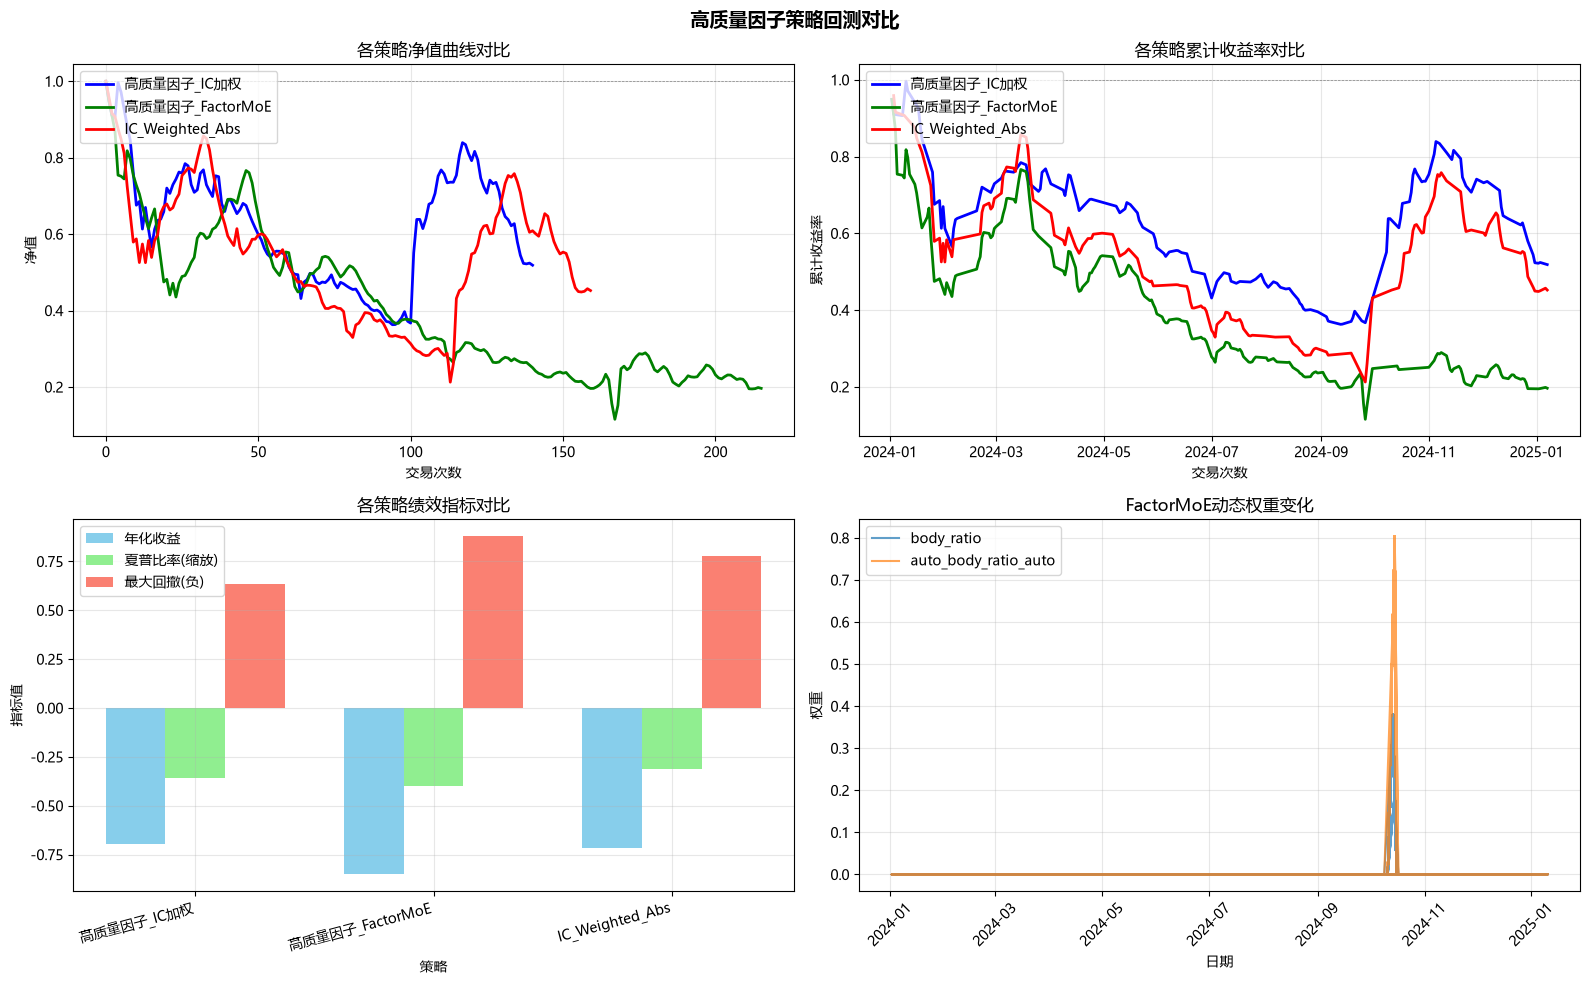


✅ 回测完成！

10. 专家激活模式分析...


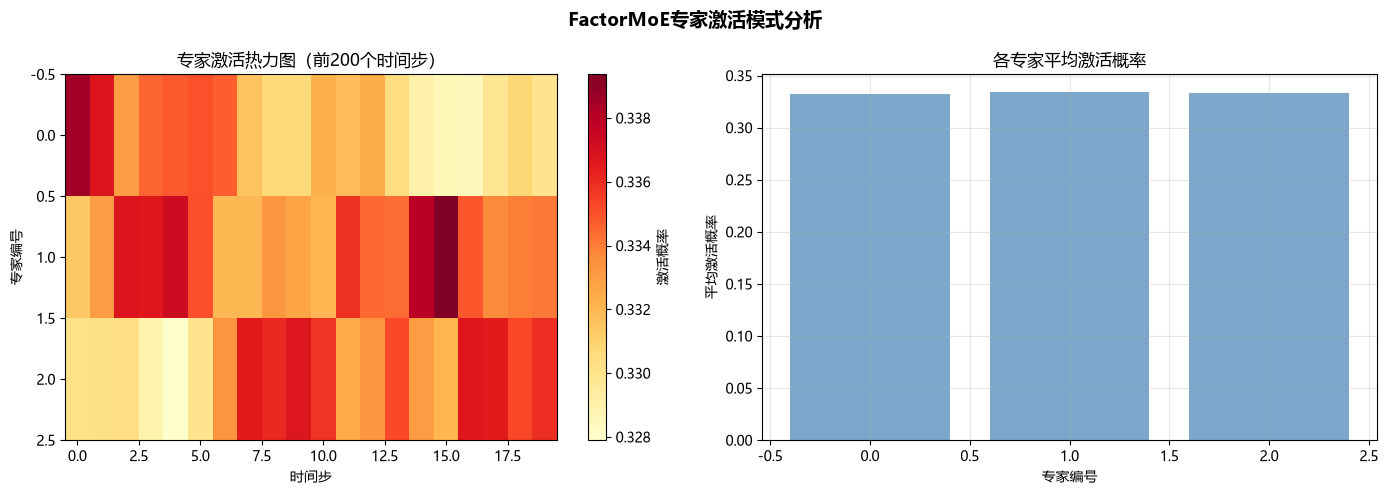


✅ 高质量因子 + FactorMoE 结合策略完成！


In [26]:
# ==================== 高质量因子 + FactorMoE 结合回测 ====================
print("\n" + "="*80)
print("高质量因子 + FactorMoE 动态权重结合策略")
print("="*80)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False


# ==================== 1. 定义高质量因子 ====================
print("\n1. 定义高质量因子...")

# 从严格筛选中得到的高质量因子
HIGH_QUALITY_FACTORS = ['body_ratio', 'auto_body_ratio_auto']

# 验证因子是否存在
valid_factors = [f for f in HIGH_QUALITY_FACTORS if f in df.columns]
print(f"有效高质量因子: {valid_factors}")

if len(valid_factors) == 0:
    print("❌ 高质量因子不存在，请检查数据")
    raise ValueError("高质量因子不存在")

# 获取因子数据
factor_data = df[valid_factors].copy()
factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
factor_data = factor_data.ffill().bfill().fillna(0)

print(f"因子数据形状: {factor_data.shape}")


# ==================== 修复：检查并恢复必要列 ====================
print("\n" + "="*80)
print("检查并恢复必要列")
print("="*80)

# 1. 检查当前列
print("\n1. 检查当前数据列...")
print(f"当前列数: {len(df.columns)}")
print(f"前20列: {df.columns[:20].tolist()}")

# 2. 检查并恢复 daily_return
if 'daily_return' not in df.columns:
    print("\n⚠️ daily_return 列不存在，正在恢复...")
    
    # 方法1：从原始数据重新计算
    if 'pre_close' in df.columns and 'close' in df.columns:
        df['daily_return'] = df['close'] / df['pre_close'] - 1
        print("✅ 使用 pre_close 计算 daily_return")
    elif 'close' in df.columns:
        # 按股票分组计算日收益率
        df['daily_return'] = df.groupby('ts_code')['close'].pct_change()
        print("✅ 使用 close 计算 daily_return")
    else:
        print("❌ 无法恢复 daily_return")
else:
    print("✅ daily_return 列存在")

# 3. 检查并恢复 amplitude
if 'amplitude' not in df.columns:
    print("\n⚠️ amplitude 列不存在，正在恢复...")
    
    if 'high' in df.columns and 'low' in df.columns:
        if 'pre_close' in df.columns:
            df['amplitude'] = (df['high'] - df['low']) / df['pre_close']
            print("✅ 使用 pre_close 计算 amplitude")
        else:
            df['amplitude'] = (df['high'] - df['low']) / df['close'].shift(1)
            print("✅ 使用 close.shift 计算 amplitude")
    else:
        print("❌ 无法恢复 amplitude")
else:
    print("✅ amplitude 列存在")

# 4. 检查并恢复其他可能需要的基础列
print("\n4. 检查其他基础列...")
required_cols = ['close', 'open', 'high', 'low', 'vol', 'amount', 'pre_close']
for col in required_cols:
    if col in df.columns:
        print(f"  ✅ {col} 存在")
    else:
        print(f"  ❌ {col} 不存在")

# 5. 填充缺失值
print("\n5. 填充缺失值...")
for col in ['daily_return', 'amplitude']:
    if col in df.columns:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        df[col] = df[col].ffill().bfill().fillna(0)
        print(f"  ✅ {col} 填充完成，缺失值: {df[col].isna().sum()}")

print("\n✅ 列恢复完成")

# ==================== 2. 定义市场状态特征 ====================
print("\n2. 定义市场状态特征...")

def calculate_market_state_for_moe_fixed(df):
    """
    计算市场状态特征（修复版）
    """
    print("计算市场状态特征...")
    
    # 检查必要列
    required_agg_cols = ['close', 'vol', 'amount', 'daily_return', 'amplitude']
    available_agg_cols = [col for col in required_agg_cols if col in df.columns]
    
    if 'daily_return' not in available_agg_cols:
        # 如果没有daily_return，使用close计算
        print("⚠️ daily_return 不可用，将使用close计算")
        df_temp = df.copy()
        df_temp['daily_return_temp'] = df_temp.groupby('ts_code')['close'].pct_change()
        agg_dict = {
            'close': 'mean',
            'vol': 'sum',
            'amount': 'sum',
            'daily_return_temp': 'mean',
            'amplitude': 'mean'
        }
        agg_cols = ['close', 'vol', 'amount', 'daily_return_temp', 'amplitude']
    else:
        agg_dict = {
            'close': 'mean',
            'vol': 'sum',
            'amount': 'sum',
            'daily_return': 'mean',
            'amplitude': 'mean'
        }
        agg_cols = ['close', 'vol', 'amount', 'daily_return', 'amplitude']
    
    # 按交易日聚合
    market_data = df.groupby('trade_date').agg(agg_dict).reset_index()
    market_data = market_data.sort_values('trade_date')
    
    # 重命名列
    if 'daily_return_temp' in market_data.columns:
        market_data = market_data.rename(columns={'daily_return_temp': 'daily_return'})
    
    # 计算市场状态指标
    market_data['market_return_5d'] = market_data['close'].pct_change(5)
    market_data['market_return_10d'] = market_data['close'].pct_change(10)
    market_data['market_volatility_5d'] = market_data['daily_return'].rolling(5, min_periods=3).std()
    market_data['market_volatility_10d'] = market_data['daily_return'].rolling(10, min_periods=5).std()
    market_data['market_volume_ratio'] = market_data['vol'] / market_data['vol'].rolling(10, min_periods=5).mean()
    market_data['market_amount_ratio'] = market_data['amount'] / market_data['amount'].rolling(10, min_periods=5).mean()
    market_data['market_amplitude_5d'] = market_data['amplitude'].rolling(5, min_periods=3).mean()
    market_data['market_vix'] = market_data['market_volatility_10d'] * np.sqrt(252)
    market_data['market_trend'] = market_data['close'] / market_data['close'].rolling(10, min_periods=5).mean() - 1
    market_data['market_momentum'] = (market_data['close'] / market_data['close'].shift(5) - 1) * 10
    
    # 市场涨跌比
    if 'daily_return' in df.columns:
        daily_up_ratio = df.groupby('trade_date').apply(
            lambda x: (x['daily_return'] > 0).mean()
        ).reset_index()
        daily_up_ratio.columns = ['trade_date', 'market_up_ratio']
        market_data = market_data.merge(daily_up_ratio, on='trade_date', how='left')
    
    # 市场分散度
    if 'daily_return' in df.columns:
        daily_std = df.groupby('trade_date')['daily_return'].std().reset_index()
        daily_std.columns = ['trade_date', 'market_dispersion']
        market_data = market_data.merge(daily_std, on='trade_date', how='left')
    
    # 填充缺失值
    market_data = market_data.ffill().bfill().fillna(0)
    
    print(f"市场状态特征计算完成，共 {len(market_data)} 个交易日")
    print(f"市场状态列: {market_data.columns.tolist()}")
    
    return market_data

# 重新计算市场状态
market_state_df = calculate_market_state_for_moe_fixed(df)

# 合并回主数据
for col in market_state_df.columns:
    if col != 'trade_date' and col in df.columns:
        df = df.drop(columns=[col])
    
df = df.merge(market_state_df, on='trade_date', how='left')
print(f"\n合并后数据形状: {df.shape}")

# 市场状态特征列
STATE_FEATURES = ['market_return_5d', 'market_return_10d', 'market_volatility_5d', 
                  'market_volatility_10d', 'market_volume_ratio', 'market_amount_ratio',
                  'market_amplitude_5d', 'market_vix', 'market_trend', 'market_momentum']

state_features = [f for f in STATE_FEATURES if f in df.columns]
print(f"可用状态特征: {state_features}")

# 重新标准化状态数据
if len(state_features) > 0:
    state_data = df[state_features].copy()
    state_data = state_data.replace([np.inf, -np.inf], np.nan)
    state_data = state_data.ffill().bfill().fillna(0)
    
    state_scaler = StandardScaler()
    state_data_scaled = pd.DataFrame(
        state_scaler.fit_transform(state_data),
        columns=state_features,
        index=state_data.index
    )
    print(f"状态数据标准化完成，形状: {state_data_scaled.shape}")
else:
    print("❌ 没有市场状态特征")
    # 创建虚拟状态
    state_data_scaled = pd.DataFrame(
        np.random.randn(len(df), 5),
        columns=['state_1', 'state_2', 'state_3', 'state_4', 'state_5'],
        index=df.index
    )
    state_features = state_data_scaled.columns.tolist()

print("\n✅ 数据准备完成，继续运行FactorMoE...")


# ==================== 3. 定义简化版FactorMoE模型 ====================
print("\n3. 定义简化版FactorMoE模型...")

class SimpleFactorMoE:
    """
    简化版FactorMoE - 专门为高质量因子设计
    """
    def __init__(self, n_factors, n_experts=3, n_state_features=5):
        self.n_factors = n_factors
        self.n_experts = n_experts
        self.n_state_features = n_state_features
        
        # 专家权重
        self.expert_weights = np.random.randn(n_experts, n_factors) * 0.01
        
        # 门控网络权重（状态特征 -> 专家）
        self.gate_weights = np.random.randn(n_state_features, n_experts) * 0.01
        
        # 历史权重（用于平滑）
        self.weight_history = []
        self.max_history = 20
        
        # 历史状态（用于注意力）
        self.state_history = []
        
        print(f"简化版FactorMoE初始化完成:")
        print(f"  因子数量: {n_factors}")
        print(f"  专家数量: {n_experts}")
        print(f"  状态特征维度: {n_state_features}")
    
    def softmax(self, x):
        """Softmax函数"""
        exp_x = np.exp(x - np.max(x))
        return exp_x / np.sum(exp_x)
    
    def get_dynamic_weights(self, state):
        """
        根据市场状态获取动态权重
        """
        # 1. 计算专家激活概率
        gate_logits = np.dot(state[:self.n_state_features], self.gate_weights)
        expert_probs = self.softmax(gate_logits)
        
        # 2. 组合专家权重
        weights = np.zeros(self.n_factors)
        for e in range(self.n_experts):
            weights += expert_probs[e] * self.expert_weights[e]
        
        # 3. 历史平滑（防止权重剧烈变化）
        if len(self.weight_history) > 0:
            hist_avg = np.mean(self.weight_history[-5:], axis=0)
            weights = 0.7 * weights + 0.3 * hist_avg
        
        # 4. 保存历史
        self.weight_history.append(weights.copy())
        if len(self.weight_history) > self.max_history:
            self.weight_history.pop(0)
        
        self.state_history.append(state.copy())
        if len(self.state_history) > self.max_history:
            self.state_history.pop(0)
        
        # 5. 归一化权重
        weights = np.maximum(weights, 0)
        weights = weights / (np.sum(weights) + 1e-8)
        
        return weights, expert_probs
    
    def update_weights(self, state, factor_performance, learning_rate=0.001):
        """
        根据因子表现更新模型权重
        """
        # 计算专家激活
        gate_logits = np.dot(state[:self.n_state_features], self.gate_weights)
        expert_probs = self.softmax(gate_logits)
        
        # 获取当前权重
        current_weights, _ = self.get_dynamic_weights(state)
        
        # 计算梯度（因子表现好的方向）
        weight_gradient = factor_performance - current_weights
        
        # 更新专家权重（只更新高概率专家）
        for e in range(self.n_experts):
            if expert_probs[e] > 0.05:
                self.expert_weights[e] += learning_rate * expert_probs[e] * weight_gradient
        
        # 正则化：防止权重过大
        self.expert_weights = np.clip(self.expert_weights, -0.5, 0.5)
        
        # 更新门控网络
        gate_gradient = np.outer(state[:self.n_state_features], expert_probs - np.mean(expert_probs))
        self.gate_weights += learning_rate * gate_gradient * 0.01
        self.gate_weights = np.clip(self.gate_weights, -0.5, 0.5)


# ==================== 4. 训练FactorMoE模型 ====================
print("\n4. 训练FactorMoE模型...")

# 初始化模型
moe_model = SimpleFactorMoE(
    n_factors=len(valid_factors),
    n_experts=3,
    n_state_features=min(len(state_features), 5)
)

print(f"模型初始化完成，使用 {len(valid_factors)} 个因子, {min(len(state_features), 5)} 个状态特征")

# 计算因子历史表现（IC值）
print("\n计算因子历史表现...")
factor_performance_history = []
window_size = 30
dates = sorted(df['trade_date'].unique())

for i in range(window_size, min(len(dates), len(state_data_scaled))):
    # 获取窗口内的数据
    window_dates = dates[max(0, i-window_size):i]
    window_data = df[df['trade_date'].isin(window_dates)]
    
    # 计算每个因子的IC
    factor_ics = []
    for factor in valid_factors:
        if factor in window_data.columns:
            valid_data = window_data[[factor, 'future_5d_return']].dropna()
            if len(valid_data) > 20:
                ic = stats.spearmanr(valid_data[factor], valid_data['future_5d_return'])[0]
                factor_ics.append(ic if not np.isnan(ic) else 0)
            else:
                factor_ics.append(0)
        else:
            factor_ics.append(0)
    
    factor_performance_history.append(np.array(factor_ics))

print(f"计算了 {len(factor_performance_history)} 个时间窗口的因子表现")

# 训练模型
print("\n开始训练FactorMoE模型...")
n_epochs = 30
learning_rate = 0.0005

for epoch in range(n_epochs):
    total_loss = 0
    n_samples = 0
    
    for i in range(min(len(factor_performance_history), len(state_data_scaled))):
        if i >= len(state_data_scaled):
            break
        
        state = state_data_scaled.iloc[i].values
        performance = factor_performance_history[i]
        
        # 更新模型
        moe_model.update_weights(state, performance, learning_rate)
        
        # 计算损失
        weights, _ = moe_model.get_dynamic_weights(state)
        performance_normalized = np.abs(performance) / (np.sum(np.abs(performance)) + 1e-8)
        loss = np.mean((weights - performance_normalized) ** 2)
        total_loss += loss
        n_samples += 1
    
    if (epoch + 1) % 10 == 0:
        avg_loss = total_loss / (n_samples + 1e-8)
        print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_loss:.6f}")

print("✅ FactorMoE模型训练完成")


# ==================== 5. 计算动态综合得分 ====================
print("\n5. 计算动态综合得分...")

# 为每个交易日计算动态权重
dynamic_weights_list = []
moe_dates = []

print("计算动态权重...")
for i, (idx, row) in enumerate(df.iterrows()):
    if i >= len(state_data_scaled):
        break
    
    state = state_data_scaled.iloc[i].values
    weights, expert_probs = moe_model.get_dynamic_weights(state)
    
    if len(weights) == len(valid_factors):
        dynamic_weights_list.append(weights)
        moe_dates.append(row['trade_date'])

print(f"计算了 {len(dynamic_weights_list)} 个交易日的动态权重")

# 将动态权重添加到DataFrame
for i, factor in enumerate(valid_factors):
    col_name = f'moe_weight_{factor}'
    weight_values = [w[i] if i < len(w) else 0 for w in dynamic_weights_list]
    
    df[col_name] = np.nan
    for j, date in enumerate(moe_dates):
        if j < len(weight_values):
            df.loc[df['trade_date'] == date, col_name] = weight_values[j]

print("动态权重列已添加")

# 计算动态综合得分
def calculate_moe_score(df, factor_cols, weight_cols):
    """
    使用动态权重计算综合得分
    """
    score = np.zeros(len(df))
    
    for factor, weight_col in zip(factor_cols, weight_cols):
        if factor in df.columns and weight_col in df.columns:
            factor_values = df[factor].values
            weight_values = df[weight_col].values
            
            # 标准化因子值
            factor_std = (factor_values - np.nanmean(factor_values)) / (np.nanstd(factor_values) + 1e-8)
            score += factor_std * weight_values
    
    return score

# 获取动态权重列
moe_weight_cols = [f'moe_weight_{f}' for f in valid_factors]
moe_weight_cols = [c for c in moe_weight_cols if c in df.columns]

if len(moe_weight_cols) == len(valid_factors):
    df['composite_score_moe'] = calculate_moe_score(
        df, valid_factors, moe_weight_cols
    )
    print("✅ 动态综合得分计算完成")
else:
    print("⚠️ 动态权重列不完整，使用等权替代")
    df['composite_score_moe'] = factor_data[valid_factors].mean(axis=1)


# ==================== 6. 回测函数 ====================
print("\n6. 执行回测...")

def backtest_strategy_full(df, score_col, strategy_name, top_n=20, hold_period=3):
    """
    完整回测函数
    """
    print(f"\n{'='*60}")
    print(f"回测策略: {strategy_name}")
    print(f"{'='*60}")
    
    # 检查必要列
    required_cols = ['ts_code', 'trade_date', 'close', score_col]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        print(f"❌ 缺少列: {missing}")
        return None, None, None, None, None
    
    # 选股
    df_copy = df.copy()
    df_copy['trade_date'] = pd.to_datetime(df_copy['trade_date'])
    df_copy['year_month'] = df_copy['trade_date'].dt.to_period('M')
    
    selected_col = f'selected_{strategy_name}'
    df_copy[selected_col] = 0
    
    for month, group in df_copy.groupby('year_month'):
        valid_group = group[group[score_col].notna()]
        if len(valid_group) < top_n:
            continue
        
        top_stocks = valid_group.nlargest(top_n, score_col)
        df_copy.loc[top_stocks.index, selected_col] = 1
    
    # 计算收益
    all_dates = sorted(df_copy['trade_date'].unique())
    portfolio_values = [1.0]
    portfolio_returns = []
    trade_dates = []
    
    for i, date in enumerate(all_dates[:-hold_period]):
        selected = df_copy[(df_copy['trade_date'] == date) & (df_copy[selected_col] == 1)]
        if len(selected) == 0:
            continue
        
        future_returns = []
        for code in selected['ts_code'].tolist():
            stock_data = df_copy[(df_copy['ts_code'] == code) & (df_copy['trade_date'] >= date)]
            if len(stock_data) > hold_period:
                start = stock_data.iloc[0]['close']
                end = stock_data.iloc[hold_period]['close']
                if start > 0 and not np.isnan(start) and not np.isnan(end):
                    ret = end / start - 1
                    if np.isfinite(ret):
                        future_returns.append(ret)
        
        if future_returns:
            ret = np.mean(future_returns) - 0.001 - 0.001  # 手续费+滑点
            portfolio_returns.append(ret)
            trade_dates.append(date)
            portfolio_values.append(portfolio_values[-1] * (1 + ret))
    
    if len(portfolio_returns) == 0:
        print(f"❌ 没有交易记录")
        return None, None, None, None, None
    
    # 计算指标
    returns_series = pd.Series(portfolio_returns, index=pd.to_datetime(trade_dates))
    cum_returns = (1 + returns_series).cumprod()
    
    total_return = portfolio_values[-1] / portfolio_values[0] - 1
    n_days = len(returns_series)
    annual_return = (1 + total_return) ** (252 / n_days) - 1 if n_days > 0 else 0
    volatility = returns_series.std() * np.sqrt(252) if len(returns_series) > 1 else 0
    sharpe = annual_return / volatility if volatility > 0 else 0
    win_rate = (returns_series > 0).sum() / len(returns_series) if len(returns_series) > 0 else 0
    
    # 最大回撤
    rolling_max = cum_returns.expanding().max()
    drawdown = (cum_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min() if len(drawdown) > 0 else 0
    
    metrics = {
        'strategy_name': strategy_name,
        'total_return': total_return,
        'annual_return': annual_return,
        'volatility': volatility,
        'sharpe_ratio': sharpe,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'n_trades': len(returns_series)
    }
    
    print(f"\n{strategy_name} 绩效指标:")
    print(f"  总收益率: {total_return:>10.2%}")
    print(f"  年化收益率: {annual_return:>10.2%}")
    print(f"  夏普比率: {sharpe:>10.4f}")
    print(f"  最大回撤: {max_drawdown:>10.2%}")
    print(f"  胜率: {win_rate:>10.2%}")
    print(f"  交易次数: {len(returns_series):>10}")
    
    return returns_series, cum_returns, portfolio_values, metrics, None


# ==================== 7. 执行所有策略回测 ====================
print("\n7. 执行所有策略回测...")

# 定义要测试的策略
strategies = [
    ('composite_score_high_quality', '高质量因子_IC加权'),
    ('composite_score_moe', '高质量因子_FactorMoE'),
]

# 如果存在其他基准策略，也加入对比
if 'composite_score_weighted_signed' in df.columns:
    strategies.append(('composite_score_weighted_signed', 'IC_Weighted_Signed'))
if 'composite_score_weighted' in df.columns:
    strategies.append(('composite_score_weighted', 'IC_Weighted_Abs'))

# 执行回测
all_results = []
all_cum = {}
all_values = {}

for score_col, name in strategies:
    print(f"\n{'='*80}")
    print(f"回测: {name}")
    print(f"{'='*80}")
    
    returns, cum_ret, values, metrics, _ = backtest_strategy_full(
        df, score_col, name, top_n=20, hold_period=3
    )
    
    if metrics is not None:
        all_results.append(metrics)
        all_cum[name] = cum_ret
        all_values[name] = values


# ==================== 8. 结果对比 ====================
print("\n" + "="*80)
print("8. 策略对比结果")
print("="*80)

if len(all_results) > 0:
    results_df = pd.DataFrame(all_results)
    
    # 格式化显示
    display_cols = ['strategy_name', 'total_return', 'annual_return', 'sharpe_ratio', 
                   'max_drawdown', 'win_rate', 'n_trades']
    display_df = results_df[display_cols].copy()
    
    for col in ['total_return', 'annual_return', 'max_drawdown', 'win_rate']:
        if col in display_df.columns:
            display_df[col] = display_df[col].apply(lambda x: f"{x:.2%}")
    
    display_df['sharpe_ratio'] = display_df['sharpe_ratio'].apply(lambda x: f"{x:.4f}")
    
    print("\n📊 各策略绩效对比:")
    print("="*80)
    print(display_df.to_string(index=False))
    
    # 找出最佳策略
    best_idx = results_df['sharpe_ratio'].idxmax()
    best = results_df.loc[best_idx]
    
    print(f"\n🏆 最佳策略: {best['strategy_name']}")
    print(f"   夏普比率: {best['sharpe_ratio']:.4f}")
    print(f"   年化收益: {best['annual_return']:.2%}")
    print(f"   最大回撤: {best['max_drawdown']:.2%}")
    
    # 比较FactorMoE vs 原始
    moe_result = results_df[results_df['strategy_name'].str.contains('FactorMoE')]
    origin_result = results_df[results_df['strategy_name'].str.contains('IC加权')]
    
    if len(moe_result) > 0 and len(origin_result) > 0:
        moe = moe_result.iloc[0]
        origin = origin_result.iloc[0]
        
        print(f"\n📊 FactorMoE vs 原始IC加权:")
        print(f"  原始IC加权: 夏普={origin['sharpe_ratio']:.4f}, 收益={origin['total_return']:.2%}")
        print(f"  FactorMoE:   夏普={moe['sharpe_ratio']:.4f}, 收益={moe['total_return']:.2%}")
        
        improvement = (moe['sharpe_ratio'] - origin['sharpe_ratio']) / (abs(origin['sharpe_ratio']) + 1e-6)
        print(f"  夏普提升: {improvement:.2%}")
        
        if moe['sharpe_ratio'] > origin['sharpe_ratio']:
            print("  ✅ FactorMoE优于原始IC加权")
        else:
            print("  ⚠️ FactorMoE未能超越原始IC加权")


# ==================== 9. 可视化 ====================
print("\n9. 绘制回测结果...")

if len(all_cum) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # 图1: 净值曲线
    ax1 = axes[0, 0]
    colors = ['blue', 'green', 'red', 'orange', 'purple']
    for i, (name, values) in enumerate(all_values.items()):
        if values is not None:
            ax1.plot(values, label=name, linewidth=2, color=colors[i % len(colors)])
    ax1.axhline(y=1, color='gray', linestyle='--', linewidth=0.5)
    ax1.set_xlabel('交易次数')
    ax1.set_ylabel('净值')
    ax1.set_title('各策略净值曲线对比')
    ax1.legend(loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # 图2: 累计收益率
    ax2 = axes[0, 1]
    for i, (name, cum_ret) in enumerate(all_cum.items()):
        if cum_ret is not None:
            ax2.plot(cum_ret, label=name, linewidth=2, color=colors[i % len(colors)])
    ax2.axhline(y=1, color='gray', linestyle='--', linewidth=0.5)
    ax2.set_xlabel('交易次数')
    ax2.set_ylabel('累计收益率')
    ax2.set_title('各策略累计收益率对比')
    ax2.legend(loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # 图3: 绩效指标对比
    ax3 = axes[1, 0]
    x = np.arange(len(results_df))
    width = 0.25
    
    ax3.bar(x - width, results_df['annual_return'], width, label='年化收益', color='skyblue')
    ax3.bar(x, results_df['sharpe_ratio']/2, width, label='夏普比率(缩放)', color='lightgreen')
    ax3.bar(x + width, -results_df['max_drawdown'], width, label='最大回撤(负)', color='salmon')
    
    ax3.set_xlabel('策略')
    ax3.set_ylabel('指标值')
    ax3.set_title('各策略绩效指标对比')
    ax3.set_xticks(x)
    ax3.set_xticklabels(results_df['strategy_name'], rotation=15, ha='right')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 图4: FactorMoE权重变化
    ax4 = axes[1, 1]
    
    # 绘制因子权重随时间变化
    for i, factor in enumerate(valid_factors):
        weight_col = f'moe_weight_{factor}'
        if weight_col in df.columns:
            weight_data = df[['trade_date', weight_col]].dropna()
            if len(weight_data) > 0:
                ax4.plot(weight_data['trade_date'], weight_data[weight_col], 
                        label=factor, linewidth=1.5, alpha=0.7)
    
    ax4.set_xlabel('日期')
    ax4.set_ylabel('权重')
    ax4.set_title('FactorMoE动态权重变化')
    ax4.legend(loc='upper left')
    ax4.grid(True, alpha=0.3)
    ax4.tick_params(axis='x', rotation=45)
    
    plt.suptitle('高质量因子策略回测对比', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✅ 回测完成！")


# ==================== 10. 额外分析：专家激活模式 ====================
print("\n10. 专家激活模式分析...")

# 分析不同市场状态下专家激活情况
if len(state_data_scaled) > 0 and hasattr(moe_model, 'state_history'):
    # 获取专家激活记录
    expert_activations = []
    market_states = []
    
    for i, state in enumerate(moe_model.state_history):
        if i < len(state_data_scaled):
            gate_logits = np.dot(state[:moe_model.n_state_features], moe_model.gate_weights)
            expert_probs = moe_model.softmax(gate_logits)
            expert_activations.append(expert_probs)
            market_states.append(state_data_scaled.iloc[i].values)
    
    if len(expert_activations) > 0:
        expert_activations = np.array(expert_activations)
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 图1: 专家激活热力图
        im = axes[0].imshow(expert_activations[:200].T, aspect='auto', 
                           cmap='YlOrRd', interpolation='nearest')
        axes[0].set_xlabel('时间步')
        axes[0].set_ylabel('专家编号')
        axes[0].set_title('专家激活热力图（前200个时间步）')
        plt.colorbar(im, ax=axes[0], label='激活概率')
        
        # 图2: 专家平均激活
        expert_avg = np.mean(expert_activations, axis=0)
        axes[1].bar(range(len(expert_avg)), expert_avg, color='steelblue', alpha=0.7)
        axes[1].set_xlabel('专家编号')
        axes[1].set_ylabel('平均激活概率')
        axes[1].set_title('各专家平均激活概率')
        axes[1].grid(True, alpha=0.3)
        
        plt.suptitle('FactorMoE专家激活模式分析', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

print("\n" + "="*80)
print("✅ 高质量因子 + FactorMoE 结合策略完成！")
print("="*80)

In [29]:
# ==================== 优化回测：降低交易成本 ====================
print("\n" + "="*80)
print("优化回测：降低交易成本 + 提高选股效率")
print("="*80)

def backtest_low_cost(df, score_col, strategy_name, top_n=20, hold_period=5, 
                      commission_rate=0.0005, slippage=0.0005):
    """
    低成本回测函数
    """
    print(f"\n{'='*60}")
    print(f"回测策略: {strategy_name}")
    print(f"  手续费: {commission_rate:.2%}, 滑点: {slippage:.2%}")
    print(f"{'='*60}")
    
    df_copy = df.copy()
    df_copy['trade_date'] = pd.to_datetime(df_copy['trade_date'])
    df_copy['year_month'] = df_copy['trade_date'].dt.to_period('M')
    
    selected_col = f'selected_{strategy_name}'
    df_copy[selected_col] = 0
    
    # 选股
    for month, group in df_copy.groupby('year_month'):
        valid_group = group[group[score_col].notna()]
        if len(valid_group) < top_n:
            continue
        top_stocks = valid_group.nlargest(top_n, score_col)
        df_copy.loc[top_stocks.index, selected_col] = 1
    
    # 计算收益
    all_dates = sorted(df_copy['trade_date'].unique())
    portfolio_values = [1.0]
    portfolio_returns = []
    trade_dates = []
    
    for i, date in enumerate(all_dates[:-hold_period]):
        selected = df_copy[(df_copy['trade_date'] == date) & (df_copy[selected_col] == 1)]
        if len(selected) == 0:
            continue
        
        future_returns = []
        for code in selected['ts_code'].tolist():
            stock_data = df_copy[(df_copy['ts_code'] == code) & (df_copy['trade_date'] >= date)]
            if len(stock_data) > hold_period:
                start = stock_data.iloc[0]['close']
                end = stock_data.iloc[hold_period]['close']
                if start > 0 and not np.isnan(start) and not np.isnan(end):
                    ret = end / start - 1
                    if np.isfinite(ret):
                        future_returns.append(ret)
        
        if future_returns:
            ret = np.mean(future_returns) - commission_rate - slippage
            portfolio_returns.append(ret)
            trade_dates.append(date)
            portfolio_values.append(portfolio_values[-1] * (1 + ret))
    
    if len(portfolio_returns) == 0:
        print(f"❌ 没有交易记录")
        return None, None, None, None
    
    # 计算指标
    returns_series = pd.Series(portfolio_returns, index=pd.to_datetime(trade_dates))
    cum_returns = (1 + returns_series).cumprod()
    
    total_return = portfolio_values[-1] / portfolio_values[0] - 1
    n_days = len(returns_series)
    annual_return = (1 + total_return) ** (252 / n_days) - 1 if n_days > 0 else 0
    volatility = returns_series.std() * np.sqrt(252) if len(returns_series) > 1 else 0
    sharpe = annual_return / volatility if volatility > 0 else 0
    win_rate = (returns_series > 0).sum() / len(returns_series) if len(returns_series) > 0 else 0
    
    rolling_max = cum_returns.expanding().max()
    drawdown = (cum_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min() if len(drawdown) > 0 else 0
    
    metrics = {
        'strategy_name': strategy_name,
        'commission': commission_rate,
        'total_return': total_return,
        'annual_return': annual_return,
        'sharpe_ratio': sharpe,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'n_trades': len(returns_series)
    }
    
    print(f"\n{strategy_name} 绩效指标 (成本{commission_rate:.2%}):")
    print(f"  总收益率: {total_return:>10.2%}")
    print(f"  年化收益率: {annual_return:>10.2%}")
    print(f"  夏普比率: {sharpe:>10.4f}")
    print(f"  最大回撤: {max_drawdown:>10.2%}")
    print(f"  胜率: {win_rate:>10.2%}")
    print(f"  交易次数: {len(returns_series):>10}")
    
    return returns_series, cum_returns, portfolio_values, metrics


# ==================== 测试不同交易成本 ====================
print("\n" + "="*80)
print("测试不同交易成本")
print("="*80)

# 使用修正后的综合得分
score_col = 'composite_score_corrected'

# 测试不同的成本组合
cost_configs = [
    (0.001, 0.001, "标准成本"),
    (0.0005, 0.0005, "低成本"),
    (0.0003, 0.0003, "超低成本"),
    (0.0001, 0.0001, "理想成本"),
]

results_cost = []

for comm, slip, name in cost_configs:
    print(f"\n{'='*60}")
    print(f"测试: {name}")
    print(f"{'='*60}")
    
    result = backtest_low_cost(
        df, score_col, 
        f"修正方向_{name}",
        top_n=20, 
        hold_period=5,
        commission_rate=comm,
        slippage=slip
    )
    
    if result is not None:
        _, _, _, metrics = result
        results_cost.append(metrics)


# ==================== 优化选股参数 ====================
print("\n" + "="*80)
print("优化选股参数")
print("="*80)

# 测试不同的选股参数
param_configs = [
    (10, 3, "top10_hold3"),
    (20, 3, "top20_hold3"),
    (30, 3, "top30_hold3"),
    (10, 5, "top10_hold5"),
    (20, 5, "top20_hold5"),
    (30, 5, "top30_hold5"),
]

results_param = []

best_comm = 0.0003  # 从上面选择最优的成本
best_slip = 0.0003

for top_n, hold, name in param_configs:
    print(f"\n{'='*60}")
    print(f"测试: {name}")
    print(f"{'='*60}")
    
    result = backtest_low_cost(
        df, score_col,
        f"修正方向_{name}",
        top_n=top_n,
        hold_period=hold,
        commission_rate=best_comm,
        slippage=best_slip
    )
    
    if result is not None:
        _, _, _, metrics = result
        metrics['top_n'] = top_n
        metrics['hold_period'] = hold
        results_param.append(metrics)


# ==================== 汇总最佳结果 ====================
print("\n" + "="*80)
print("汇总：最佳策略")
print("="*80)

if len(results_param) > 0:
    # 合并所有结果
    all_results = results_cost + results_param
    results_df = pd.DataFrame(all_results)
    
    # 按夏普比率排序
    results_df = results_df.sort_values('sharpe_ratio', ascending=False)
    
    print("\n📊 所有策略按夏普比率排序:")
    display_cols = ['strategy_name', 'total_return', 'annual_return', 'sharpe_ratio', 
                   'max_drawdown', 'win_rate', 'n_trades']
    display_df = results_df[display_cols].copy()
    
    for col in ['total_return', 'annual_return', 'max_drawdown', 'win_rate']:
        if col in display_df.columns:
            display_df[col] = display_df[col].apply(lambda x: f"{x:.2%}")
    
    display_df['sharpe_ratio'] = display_df['sharpe_ratio'].apply(lambda x: f"{x:.4f}")
    print(display_df.to_string(index=False))
    
    # 最佳策略
    best = results_df.iloc[0]
    print(f"\n🏆 最佳策略: {best['strategy_name']}")
    print(f"   总收益率: {best['total_return']:.2%}")
    print(f"   年化收益率: {best['annual_return']:.2%}")
    print(f"   夏普比率: {best['sharpe_ratio']:.4f}")
    print(f"   最大回撤: {best['max_drawdown']:.2%}")


优化回测：降低交易成本 + 提高选股效率

测试不同交易成本

测试: 标准成本

回测策略: 修正方向_标准成本
  手续费: 0.10%, 滑点: 0.10%

修正方向_标准成本 绩效指标 (成本0.10%):
  总收益率:    -47.36%
  年化收益率:    -68.76%
  夏普比率:    -0.5852
  最大回撤:    -70.64%
  胜率:     41.01%
  交易次数:        139

测试: 低成本

回测策略: 修正方向_低成本
  手续费: 0.05%, 滑点: 0.05%

修正方向_低成本 绩效指标 (成本0.05%):
  总收益率:    -39.46%
  年化收益率:    -59.74%
  夏普比率:    -0.5084
  最大回撤:    -67.57%
  胜率:     41.73%
  交易次数:        139

测试: 超低成本

回测策略: 修正方向_超低成本
  手续费: 0.03%, 滑点: 0.03%

修正方向_超低成本 绩效指标 (成本0.03%):
  总收益率:    -35.98%
  年化收益率:    -55.45%
  夏普比率:    -0.4719
  最大回撤:    -66.26%
  胜率:     41.73%
  交易次数:        139

测试: 理想成本

回测策略: 修正方向_理想成本
  手续费: 0.01%, 滑点: 0.01%

修正方向_理想成本 绩效指标 (成本0.01%):
  总收益率:    -32.30%
  年化收益率:    -50.70%
  夏普比率:    -0.4315
  最大回撤:    -64.89%
  胜率:     41.73%
  交易次数:        139

优化选股参数

测试: top10_hold3

回测策略: 修正方向_top10_hold3
  手续费: 0.03%, 滑点: 0.03%

修正方向_top10_hold3 绩效指标 (成本0.03%):
  总收益率:    -25.35%
  年化收益率:    -58.41%
  夏普比率:    -0.5027
  最大回撤:    -49.10%
  胜率:     35.71%
  交易次数

数据标准化（必须）。

先拟合一个全量PCA（n_components=None），画出累计贡献率肘部曲线，初步确定一个“有效区间”（如贡献率85%-95%对应的主成分数范围）。

在这个区间内，将PCA嵌入你的机器学习Pipeline，通过交叉验证选择使模型效果最佳的 
k
k 值（这就是最终答案）。

验证：用选定的 
k
k 值降维后，与未降维的原始数据跑一次模型对比。如果准确率下降不明显（<2%），但训练/推理时间大幅缩短（如减少50%），那么你的PCA设置就是极其理想的

Fitting 3 folds for each of 11 candidates, totalling 33 fits
最佳主成分数: 50
最佳交叉验证准确率: 0.9605


d:\a111111\回测模拟\cross_sectional_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 25240 (\N{CJK UNIFIED IDEOGRAPH-6298}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\a111111\回测模拟\cross_sectional_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\a111111\回测模拟\cross_sectional_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21449 (\N{CJK UNIFIED IDEOGRAPH-53C9}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\a111111\回测模拟\cross_sectional_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\a111111\回测模拟\cross_sectional_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35777 (\N{CJK U

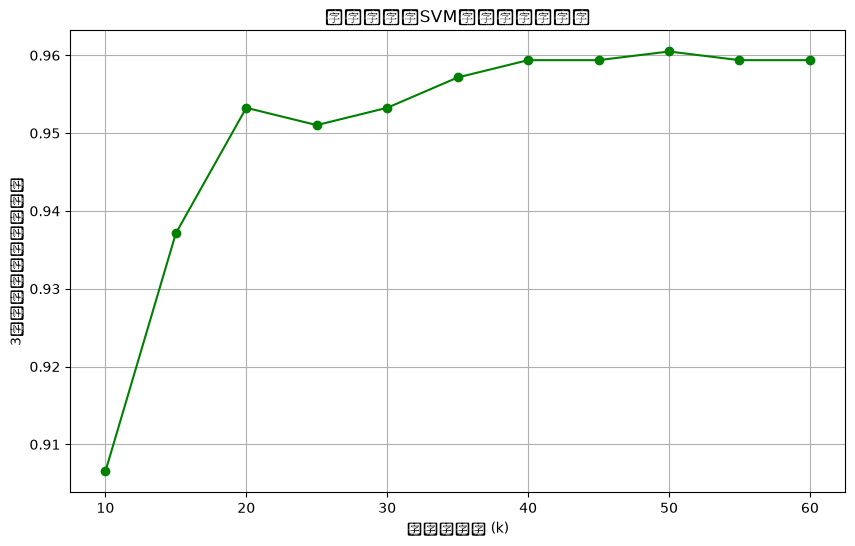

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 加载数据
X, y = load_digits(return_X_y=True)
X_scaled = StandardScaler().fit_transform(X)

# 构建Pipeline
pipe = Pipeline([
    ('pca', PCA()),
    ('svc', SVC(kernel='rbf', gamma='scale'))
])

# 搜索参数空间：主成分数从10到64（全特征）
param_grid = {
    'pca__n_components': list(range(10, 65, 5))  # 10, 15, 20, ..., 60
}

# 网格搜索（使用3折交叉验证）
grid_search = GridSearchCV(pipe, param_grid, cv=3, n_jobs=-1, verbose=1)
grid_search.fit(X_scaled, y)

# 输出最佳结果
print(f"最佳主成分数: {grid_search.best_params_['pca__n_components']}")
print(f"最佳交叉验证准确率: {grid_search.best_score_:.4f}")

# 绘制不同主成分数对应的模型表现
results = grid_search.cv_results_
k_values = param_grid['pca__n_components']
mean_scores = results['mean_test_score']

plt.figure(figsize=(10,6))
plt.plot(k_values, mean_scores, 'go-')
plt.xlabel('主成分个数 (k)')
plt.ylabel('3折交叉验证平均准确率')
plt.title('主成分数对SVM分类性能的影响')
plt.grid(True)
plt.show()

对因子收益率数据做PCA，得到主成分载荷矩阵。

观察各原始因子在哪个主成分上的载荷绝对值最大，根据这个结果将因子分成若干组。

在每组内，结合IC（信息系数）和IR（信息比率），手动挑选最优的原始因子。

1. 数据读取和预处理
原始数据形状: (24678, 11)
剔除涨跌停日后数据量: 23979
清洗后数据形状: (23979, 11)

2. 计算基础衍生指标
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
基础衍生指标计算完成

3. 计算技术因子
计算基础技术因子...
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 基础技术因子计算完成
基础技术因子数量: 26

4. 自动因子挖掘
开始自动挖掘技术因子...
处理 100 只股票...
  处理进度: 0/100
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
处理缺失值...
自动挖掘因子数量: 163

将自动挖掘因子合并到主数据...
合并后数据形状: (23979, 204)
总因子数量: 189

5. 因子预处理
进行MAD去极值处理...
  处理进度: 0/189
  处理进度: 50/189
  处理进度: 100/189
  处理进度: 150/189
进行Z-score标准化...
进行规模中性化...
  处理进度: 0/189
  处理进度: 50/189
  处理进度: 100/189
  处理进度: 150/189
因子预处理完成

6. 计算未来5日收益
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 未来5日收益计算完成

7. 计算IC/IR
待检验

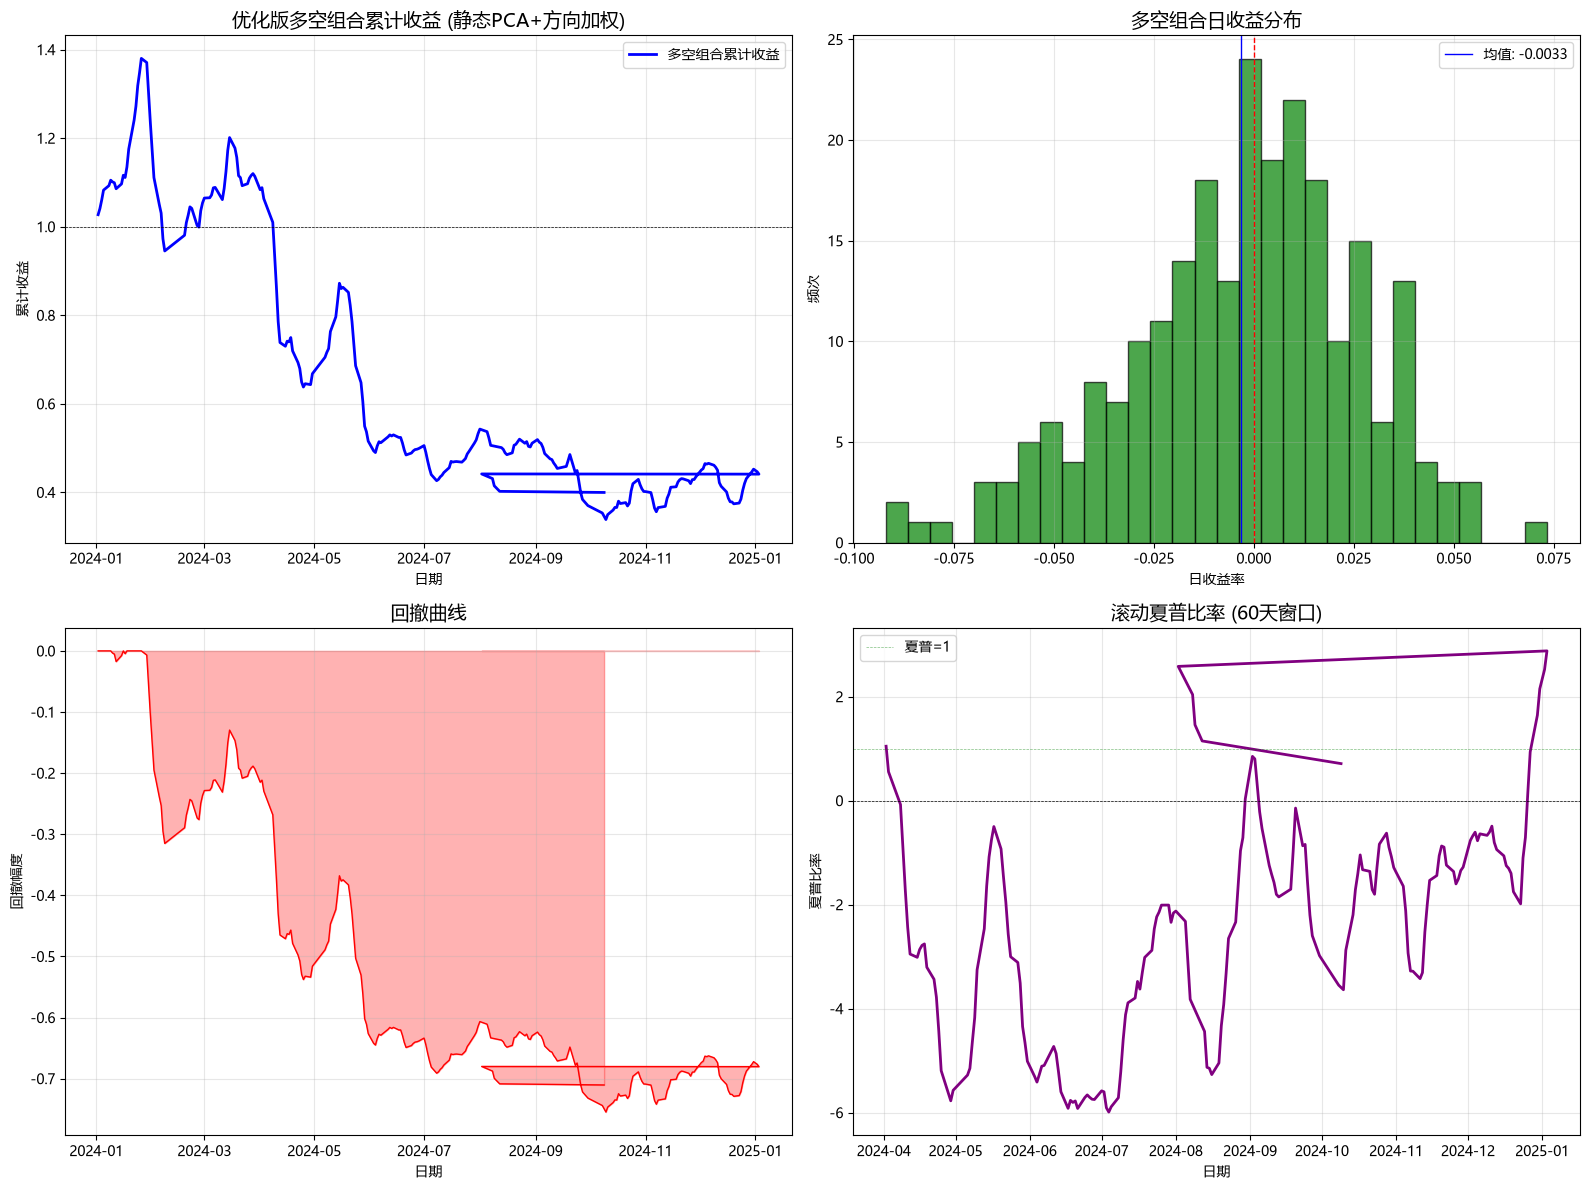


12. 分组收益分析


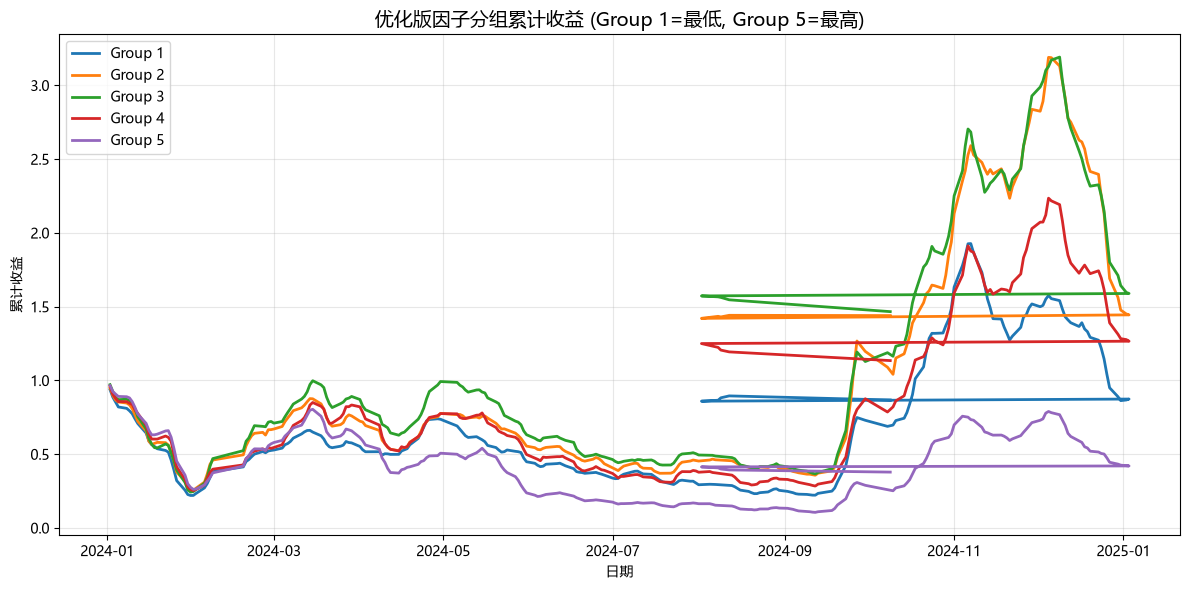


🎉 全部完成！


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from scipy.linalg import eigh
import itertools
import os
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 数据读取和预处理 ====================
print("="*80)
print("1. 数据读取和预处理")
print("="*80)

# 读取数据
df = pd.read_csv('../extracted_data/stk_100.csv')
print(f"原始数据形状: {df.shape}")

# 转换日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)

# 剔除ST股票
st_mask = df['ts_code'].str.contains('ST|st', na=False)
if st_mask.any():
    df = df[~st_mask]
    print(f"剔除ST股票后数据量: {len(df)}")

# 剔除涨跌停日
if 'pct_chg' in df.columns:
    limit_mask = (df['pct_chg'] >= 9.9) | (df['pct_chg'] <= -9.5)
    df = df[~limit_mask]
    print(f"剔除涨跌停日后数据量: {len(df)}")

# 剔除停牌日
if 'volume' in df.columns and 'amount' in df.columns:
    zero_mask = (df['volume'] == 0) | (df['amount'] == 0)
    df = df[~zero_mask]
    print(f"剔除停牌日后数据量: {len(df)}")

print(f"清洗后数据形状: {df.shape}")

# ==================== 计算基础衍生指标 ====================
print("\n" + "="*80)
print("2. 计算基础衍生指标")
print("="*80)

def calculate_derived_indicators(group):
    group = group.sort_values('trade_date').copy()
    
    if 'close' in group.columns and 'pre_close' in group.columns:
        group['daily_return'] = group['close'] / group['pre_close'] - 1
    elif 'close' in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    if 'vol' in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    if 'high' in group.columns and 'low' in group.columns:
        if 'pre_close' in group.columns:
            group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
        else:
            group['amplitude'] = (group['high'] - group['low']) / group['close'].shift(1)
    
    if 'amount' in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].rolling(20).mean()
    
    return group

unique_codes = df['ts_code'].unique().tolist()
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_derived_indicators(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print("基础衍生指标计算完成")

# ==================== 计算技术因子 ====================
print("\n" + "="*80)
print("3. 计算技术因子")
print("="*80)

def fill_factor_values(series, fill_method='forward'):
    if fill_method == 'forward':
        return series.ffill()
    elif fill_method == 'mean':
        return series.fillna(series.mean())
    elif fill_method == 'zero':
        return series.fillna(0)
    elif fill_method == 'median':
        return series.fillna(series.median())
    elif fill_method == 'ffill_bfill':
        return series.ffill().bfill()
    else:
        return series

def calculate_technical_factors(group):
    group = group.sort_values('trade_date').copy()
    
    if 'daily_return' not in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    if 'turnover_rate' not in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    if 'amplitude' not in group.columns:
        group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
    
    if 'amount_ratio' not in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].rolling(20).mean()
    
    factor_fill_methods = {}
    
    # RSI
    def calc_rsi(data, period):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    for p in [6, 12, 24]:
        col = f'rsi_{p}'
        group[col] = calc_rsi(group['close'], p)
        factor_fill_methods[col] = 'forward'
    
    # MACD
    exp1 = group['close'].ewm(span=12, adjust=False).mean()
    exp2 = group['close'].ewm(span=26, adjust=False).mean()
    group['macd'] = exp1 - exp2
    group['macd_signal'] = group['macd'].ewm(span=9, adjust=False).mean()
    group['macd_hist'] = group['macd'] - group['macd_signal']
    factor_fill_methods['macd'] = 'forward'
    factor_fill_methods['macd_signal'] = 'forward'
    factor_fill_methods['macd_hist'] = 'forward'
    
    # MOM
    for p in [5, 10, 20]:
        col = f'mom_{p}'
        group[col] = group['close'] / group['close'].shift(p) - 1
        factor_fill_methods[col] = 'zero'
    
    # 均线偏离度
    for p in [5, 20, 60]:
        col = f'ma_dev_{p}'
        ma = group['close'].rolling(window=p).mean()
        group[col] = (group['close'] - ma) / ma
        factor_fill_methods[col] = 'forward'
    
    # ATR
    high_low = group['high'] - group['low']
    high_close = abs(group['high'] - group['close'].shift())
    low_close = abs(group['low'] - group['close'].shift())
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    group['atr_14'] = tr.rolling(window=14).mean()
    factor_fill_methods['atr_14'] = 'forward'
    
    # 历史波动率
    if 'daily_return' in group.columns:
        for p in [20, 60]:
            col = f'hist_vol_{p}'
            group[col] = group['daily_return'].rolling(window=p).std() * np.sqrt(252)
            factor_fill_methods[col] = 'forward'
    
    # 布林带宽度
    ma20 = group['close'].rolling(window=20).mean()
    std20 = group['close'].rolling(window=20).std()
    group['bollinger_band'] = (group['close'] - ma20) / (2 * std20)
    factor_fill_methods['bollinger_band'] = 'forward'
    
    # 成交量因子
    for p in [5, 10]:
        col = f'vr_{p}'
        group[col] = group['vol'] / group['vol'].rolling(window=p).mean()
        factor_fill_methods[col] = 'forward'
    
    # OBV
    obv = np.zeros(len(group))
    for i in range(1, len(group)):
        if group['close'].iloc[i] > group['close'].iloc[i-1]:
            obv[i] = obv[i-1] + group['vol'].iloc[i]
        elif group['close'].iloc[i] < group['close'].iloc[i-1]:
            obv[i] = obv[i-1] - group['vol'].iloc[i]
        else:
            obv[i] = obv[i-1]
    group['obv'] = obv
    factor_fill_methods['obv'] = 'forward'
    
    # 量价相关系数
    group['volume_price_corr'] = group['vol'].rolling(window=20).corr(group['close'])
    factor_fill_methods['volume_price_corr'] = 'zero'
    
    # 价格形态因子
    high_20 = group['high'].rolling(window=20).max()
    low_20 = group['low'].rolling(window=20).min()
    group['highest_lowest_pos'] = (group['close'] - low_20) / (high_20 - low_20)
    factor_fill_methods['highest_lowest_pos'] = 'forward'
    
    group['upper_shadow'] = (group['high'] - group[['open', 'close']].max(axis=1)) / (group['high'] - group['low'])
    group['lower_shadow'] = (group[['open', 'close']].min(axis=1) - group['low']) / (group['high'] - group['low'])
    factor_fill_methods['upper_shadow'] = 'forward'
    factor_fill_methods['lower_shadow'] = 'forward'
    
    group['body_ratio'] = abs(group['close'] - group['open']) / (group['high'] - group['low'])
    factor_fill_methods['body_ratio'] = 'forward'
    
    # 流动性因子
    group['amihud'] = abs(group['daily_return']) / (group['amount'] * 1e6)
    factor_fill_methods['amihud'] = 'median'
    
    group['log_amount'] = np.log(group['amount'] + 1)
    factor_fill_methods['log_amount'] = 'forward'
    
    # 应用填充策略
    for col, method in factor_fill_methods.items():
        if col in group.columns:
            group[col] = group[col].replace([np.inf, -np.inf], np.nan)
            try:
                group[col] = fill_factor_values(group[col], method)
            except Exception as e:
                group[col] = group[col].ffill().fillna(0)
            if group[col].isna().any():
                group[col] = group[col].ffill().bfill().fillna(0)
    
    return group

print("计算基础技术因子...")
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_technical_factors(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print("✅ 基础技术因子计算完成")

# 保存基础因子列名
base_factor_columns = [col for col in df.columns if col not in ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
                                                                 'vol', 'amount', 'pre_close', 'change', 'pct_chg', 
                                                                 'daily_return', 'turnover_rate', 'amplitude', 
                                                                 'amount_ratio']]
print(f"基础技术因子数量: {len(base_factor_columns)}")

# ==================== 自动因子挖掘 ====================
print("\n" + "="*80)
print("4. 自动因子挖掘")
print("="*80)

def auto_factor_mining(df, lookback_periods=[5, 10, 20, 30, 60]):
    print("开始自动挖掘技术因子...")
    
    auto_factors_df = pd.DataFrame(index=df.index)
    unique_codes = df['ts_code'].unique()
    print(f"处理 {len(unique_codes)} 只股票...")
    
    for idx, code in enumerate(unique_codes):
        if idx % 20 == 0:
            print(f"  处理进度: {idx}/{len(unique_codes)}")
        
        stock_mask = df['ts_code'] == code
        stock_indices = df[stock_mask].index
        stock_data = df.loc[stock_mask].copy()
        stock_data = stock_data.sort_values('trade_date').reset_index(drop=True)
        
        if len(stock_data) < 60:
            continue
        
        stock_factors = {}
        
        # 价格比率因子
        for col in ['open', 'high', 'low', 'close']:
            if col in stock_data.columns:
                for p in lookback_periods:
                    stock_factors[f'{col}_ratio_{p}'] = stock_data[col] / stock_data[col].shift(p)
                    stock_factors[f'{col}_log_return_{p}'] = np.log(stock_data[col] / stock_data[col].shift(p) + 1e-6)
        
        # 价格范围因子
        stock_factors['high_low_ratio'] = stock_data['high'] / stock_data['low']
        stock_factors['close_open_ratio'] = stock_data['close'] / stock_data['open']
        stock_factors['high_close_ratio'] = stock_data['high'] / stock_data['close']
        stock_factors['low_close_ratio'] = stock_data['low'] / stock_data['close']
        
        # 移动平均及衍生因子
        for p in lookback_periods:
            ma = stock_data['close'].rolling(window=p).mean()
            stock_factors[f'ma_{p}'] = ma
            stock_factors[f'price_ma_ratio_{p}'] = stock_data['close'] / ma - 1
            
            ema = stock_data['close'].ewm(span=p, adjust=False).mean()
            stock_factors[f'price_ema_ratio_{p}'] = stock_data['close'] / ema - 1
            
            if p >= 20:
                ma_short = stock_data['close'].rolling(window=int(p/2)).mean()
                stock_factors[f'ma_cross_{p}'] = ma_short / ma - 1
            
            std = stock_data['close'].rolling(window=p).std()
            stock_factors[f'std_{p}'] = std
            stock_factors[f'std_ratio_{p}'] = std / (ma + 1e-6)
            
            returns = stock_data['close'].pct_change()
            stock_factors[f'volatility_{p}'] = returns.rolling(window=p).std() * np.sqrt(252)
            stock_factors[f'skew_{p}'] = returns.rolling(window=p).skew()
            stock_factors[f'kurtosis_{p}'] = returns.rolling(window=p).kurt()
            
            for q in [0.1, 0.25, 0.75, 0.9]:
                stock_factors[f'quantile_{q}_{p}'] = stock_data['close'].rolling(window=p).quantile(q)
                stock_factors[f'quantile_ratio_{q}_{p}'] = stock_data['close'] / (stock_factors[f'quantile_{q}_{p}'] + 1e-6) - 1
        
        # 成交量相关因子
        for p in lookback_periods:
            vol_ma = stock_data['vol'].rolling(window=p).mean()
            stock_factors[f'volume_ma_{p}'] = vol_ma
            stock_factors[f'volume_ma_ratio_{p}'] = stock_data['vol'] / vol_ma - 1
            stock_factors[f'volume_std_{p}'] = stock_data['vol'].rolling(window=p).std()
            
            amount_ma = stock_data['amount'].rolling(window=p).mean()
            stock_factors[f'amount_ma_{p}'] = amount_ma
            stock_factors[f'amount_ma_ratio_{p}'] = stock_data['amount'] / amount_ma - 1
        
        # 价格形态因子
        stock_factors['upper_shadow_auto'] = (stock_data['high'] - stock_data[['open', 'close']].max(axis=1)) / (stock_data['high'] - stock_data['low'] + 1e-6)
        stock_factors['lower_shadow_auto'] = (stock_data[['open', 'close']].min(axis=1) - stock_data['low']) / (stock_data['high'] - stock_data['low'] + 1e-6)
        stock_factors['body_ratio_auto'] = abs(stock_data['close'] - stock_data['open']) / (stock_data['high'] - stock_data['low'] + 1e-6)
        
        returns = stock_data['close'].pct_change()
        stock_factors['up_days'] = (returns > 0).rolling(window=10).sum()
        stock_factors['down_days'] = (returns < 0).rolling(window=10).sum()
        stock_factors['up_down_ratio'] = stock_factors['up_days'] / (stock_factors['down_days'] + 1e-6)
        
        stock_factors['new_high_20_auto'] = (stock_data['close'] == stock_data['close'].rolling(window=20).max()).astype(int)
        stock_factors['new_low_20_auto'] = (stock_data['close'] == stock_data['close'].rolling(window=20).min()).astype(int)
        
        # 量价关系因子
        for p in [5, 10, 20]:
            stock_factors[f'vol_price_corr_{p}'] = stock_data['vol'].rolling(window=p).corr(stock_data['close'])
        
        for factor_name, factor_values in stock_factors.items():
            if factor_name not in auto_factors_df.columns:
                auto_factors_df[factor_name] = np.nan
            auto_factors_df.loc[stock_indices, factor_name] = factor_values.values
    
    print("处理缺失值...")
    auto_factors_df = auto_factors_df.replace([np.inf, -np.inf], np.nan)
    auto_factors_df = auto_factors_df.ffill().bfill().fillna(0)
    
    print(f"自动挖掘因子数量: {auto_factors_df.shape[1]}")
    return auto_factors_df

auto_factors_df = auto_factor_mining(df)

# 合并自动挖掘因子
print("\n将自动挖掘因子合并到主数据...")
auto_factor_names = []
for col in auto_factors_df.columns:
    new_col_name = f'auto_{col}'
    if new_col_name in df.columns:
        counter = 1
        while f'{new_col_name}_{counter}' in df.columns:
            counter += 1
        new_col_name = f'{new_col_name}_{counter}'
    df[new_col_name] = auto_factors_df[col].values
    auto_factor_names.append(new_col_name)

print(f"合并后数据形状: {df.shape}")

# 所有因子列
all_factor_columns = list(dict.fromkeys(base_factor_columns + auto_factor_names))
print(f"总因子数量: {len(all_factor_columns)}")

# ==================== 因子预处理 ====================
print("\n" + "="*80)
print("5. 因子预处理")
print("="*80)

factor_data = df[all_factor_columns].copy()
factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
factor_data = factor_data.ffill().bfill().fillna(0)

def mad_winsorize(data, n_sigma=5):
    if isinstance(data, pd.Series):
        values = data.values
    else:
        values = np.array(data)
    
    median = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - median))
    
    upper_bound = median + n_sigma * mad
    lower_bound = median - n_sigma * mad
    
    values_clipped = np.clip(values, lower_bound, upper_bound)
    
    if isinstance(data, pd.Series):
        return pd.Series(values_clipped, index=data.index)
    else:
        return values_clipped

print("进行MAD去极值处理...")
for idx, col in enumerate(all_factor_columns):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(all_factor_columns)}")
    factor_data[col] = mad_winsorize(factor_data[col])

print("进行Z-score标准化...")
scaler = StandardScaler()
factor_data_scaled = pd.DataFrame(scaler.fit_transform(factor_data), 
                                  columns=all_factor_columns, 
                                  index=factor_data.index)

print("进行规模中性化...")
log_amount = df['log_amount'].values.reshape(-1, 1)
factor_neutralized = pd.DataFrame(index=factor_data.index, columns=all_factor_columns)

for idx, col in enumerate(all_factor_columns):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(all_factor_columns)}")
    try:
        reg = LinearRegression()
        reg.fit(log_amount, factor_data_scaled[col].values.reshape(-1, 1))
        residual = factor_data_scaled[col].values - reg.predict(log_amount).flatten()
        factor_neutralized[col] = residual
    except Exception as e:
        factor_neutralized[col] = factor_data_scaled[col].values

print("因子预处理完成")

# 将预处理后的因子合并回原始数据
for col in all_factor_columns:
    df[f'{col}_processed'] = factor_neutralized[col]

# ==================== 计算未来5日收益 ====================
print("\n" + "="*80)
print("6. 计算未来5日收益")
print("="*80)

def calculate_future_returns(group):
    group = group.sort_values('trade_date').copy()
    group['future_5d_return'] = group['close'].shift(-5) / group['close'] - 1
    return group

df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_future_returns(group)
    df_list.append(group)
df = pd.concat(df_list, ignore_index=True)
print("✅ 未来5日收益计算完成")

# ==================== 计算IC/IR ====================
print("\n" + "="*80)
print("7. 计算IC/IR")
print("="*80)

factor_cols_processed = [col for col in df.columns if col.endswith('_processed')]
print(f"待检验因子数量: {len(factor_cols_processed)}")

ic_results = []
print("计算IC值...")
for idx, col in enumerate(factor_cols_processed):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(factor_cols_processed)}")
    
    valid_data = df[[col, 'future_5d_return']].dropna()
    if len(valid_data) > 20:
        try:
            ic = stats.spearmanr(valid_data[col], valid_data['future_5d_return'])[0]
            if not np.isnan(ic):
                ic_results.append({
                    'factor': col,
                    'ic': ic,
                    'ic_abs': abs(ic),
                    'n_obs': len(valid_data)
                })
        except Exception as e:
            continue

ic_df = pd.DataFrame(ic_results).sort_values('ic_abs', ascending=False)
print(f"\n📊 计算完成，有效因子数量: {len(ic_df)}")

# ==================== 优化：静态PCA分组筛选（增强版） ====================
print("\n" + "="*80)
print("8. 静态PCA分组筛选（优化增强版）")
print("="*80)

# 准备PCA数据：使用预处理后的因子数据
pca_data_list = []
for factor in all_factor_columns:
    processed_col = f'{factor}_processed'
    if processed_col in df.columns:
        pca_data_list.append(df[processed_col])

pca_data = pd.concat(pca_data_list, axis=1)
pca_data.columns = all_factor_columns

# 处理缺失值
pca_data = pca_data.replace([np.inf, -np.inf], np.nan)
pca_data = pca_data.fillna(0)

print(f"PCA数据形状: {pca_data.shape}")

# 执行PCA
n_components = min(50, pca_data.shape[1], pca_data.shape[0] - 1)
pca = PCA(n_components=n_components)
pca.fit(pca_data)

# 获取载荷矩阵
loadings = pd.DataFrame(
    pca.components_.T,
    index=all_factor_columns,
    columns=[f'PC{i+1}' for i in range(pca.n_components)]
)

print(f"PCA完成，保留 {pca.n_components} 个主成分")
print(f"累计方差贡献率: {np.sum(pca.explained_variance_ratio_):.2%}")

# ===== 新增：符号校正（确保主成分方向一致） =====
print("\n进行符号校正...")

# 定义因子类别
factor_categories = {}
for factor in all_factor_columns:
    factor_lower = factor.lower()
    if any(x in factor_lower for x in ['pe', 'pb', 'ps', 'pcf', 'value']):
        factor_categories[factor] = 'valuation'
    elif any(x in factor_lower for x in ['mom', 'momentum', 'trend', 'rsi', 'macd']):
        factor_categories[factor] = 'momentum'
    elif any(x in factor_lower for x in ['vol', 'atr', 'std', 'volatility']):
        factor_categories[factor] = 'volatility'
    elif any(x in factor_lower for x in ['volume', 'amount', 'turnover', 'vr']):
        factor_categories[factor] = 'volume'
    elif any(x in factor_lower for x in ['size', 'market_cap', 'log_amount']):
        factor_categories[factor] = 'size'
    else:
        factor_categories[factor] = 'other'

# 符号校正：确保每个主成分与主要类别方向一致
for pc_idx in range(min(20, pca.n_components)):
    pc_name = f'PC{pc_idx+1}'
    pc_loadings = loadings[pc_name]
    
    # 计算各类别的平均载荷
    category_loadings = {}
    for category in set(factor_categories.values()):
        cat_factors = [f for f, c in factor_categories.items() if c == category]
        cat_loadings = [pc_loadings[f] for f in cat_factors if f in pc_loadings.index]
        if len(cat_loadings) > 0:
            category_loadings[category] = np.mean(cat_loadings)
    
    # 找出最大正相关的类别，如果为负则翻转
    if len(category_loadings) > 0:
        max_category = max(category_loadings, key=category_loadings.get)
        if category_loadings[max_category] < 0:
            loadings[pc_name] = -loadings[pc_name]
            pca.components_[pc_idx, :] = -pca.components_[pc_idx, :]

print("符号校正完成")

# 显示前5个主成分的载荷
print("\n前5个主成分的载荷（前10个因子）:")
print(loadings.iloc[:10, :5].round(3))

# 将因子分组到主成分
n_pcs_to_use = min(20, pca.n_components)
dominant_pc = np.abs(loadings.iloc[:, :n_pcs_to_use]).idxmax(axis=1)

# 构建分组信息
factor_groups = pd.DataFrame({
    'factor': loadings.index,
    'dominant_pc': dominant_pc,
    'max_load': np.abs(loadings.iloc[:, :n_pcs_to_use]).max(axis=1)
})

print(f"\n因子分组完成，共 {len(factor_groups['dominant_pc'].unique())} 个组")

# 显示每组包含的因子数量
group_counts = factor_groups.groupby('dominant_pc').size().sort_values(ascending=False)
print("\n各组因子数量:")
print(group_counts.head(10))

# ===== 改进：因子综合评分（IC + IR + 单调性） =====
print("\n计算因子综合评分...")

def calculate_ir_fast(factor_col, df, window=20):
    """快速计算IR"""
    valid_data = df[[factor_col, 'future_5d_return']].dropna()
    if len(valid_data) < window * 2:
        return 0
    
    ic_series = []
    for i in range(window, min(len(valid_data), 100)):
        sub_data = valid_data.iloc[i-window:i]
        if len(sub_data) > 10:
            ic = stats.spearmanr(sub_data[factor_col], sub_data['future_5d_return'])[0]
            if not np.isnan(ic):
                ic_series.append(ic)
    
    if len(ic_series) > 5:
        ir = np.mean(ic_series) / (np.std(ic_series) + 1e-6)
        return ir
    return 0

# 为每个因子计算综合指标
factor_metrics_full = []
for factor in all_factor_columns:
    processed_col = f'{factor}_processed'
    if processed_col not in df.columns:
        continue
    
    # 获取IC
    ic_info = ic_df[ic_df['factor'] == processed_col]
    ic_value = ic_info['ic'].values[0] if len(ic_info) > 0 else 0
    ic_abs = abs(ic_value)
    
    # 计算IR
    ir = calculate_ir_fast(processed_col, df)
    
    # 计算单调性（Spearman相关系数）
    valid_data = df[[processed_col, 'future_5d_return']].dropna()
    monotonicity = 0
    if len(valid_data) > 50:
        try:
            valid_data['group'] = pd.qcut(valid_data[processed_col], q=5, labels=False, duplicates='drop')
            if len(valid_data['group'].unique()) >= 3:
                group_returns = valid_data.groupby('group')['future_5d_return'].mean()
                monotonicity = stats.spearmanr(range(len(group_returns)), group_returns.values)[0]
                if np.isnan(monotonicity):
                    monotonicity = 0
        except:
            monotonicity = 0
    
    factor_metrics_full.append({
        'factor': factor,
        'processed_col': processed_col,
        'ic': ic_value,
        'ic_abs': ic_abs,
        'ir': ir,
        'monotonicity': abs(monotonicity)
    })

factor_metrics_full_df = pd.DataFrame(factor_metrics_full)

# 合并分组信息
factor_groups_with_metrics = factor_groups.merge(
    factor_metrics_full_df, 
    left_on='factor', 
    right_on='factor',
    how='left'
)

# ===== 改进：提高IC过滤阈值 =====
ic_threshold = 0.025  # 从0.02提高到0.025
factor_groups_with_metrics = factor_groups_with_metrics[
    factor_groups_with_metrics['ic_abs'] > ic_threshold
]
print(f"IC过滤后剩余因子 (阈值{ic_threshold}): {len(factor_groups_with_metrics)}")

# ===== 改进：综合评分权重调整 =====
# 增加单调性权重，降低IR权重（IR在静态环境下可能不稳定）
factor_groups_with_metrics['score'] = (
    factor_groups_with_metrics['ic_abs'] * 0.50 + 
    factor_groups_with_metrics['ir'] * 0.15 + 
    factor_groups_with_metrics['monotonicity'] * 0.35
)

# 按组分选择最优因子
selected_factors_by_pca = []

for pc_group in factor_groups_with_metrics['dominant_pc'].unique():
    group_factors = factor_groups_with_metrics[
        factor_groups_with_metrics['dominant_pc'] == pc_group
    ].sort_values('score', ascending=False)
    
    if len(group_factors) > 0:
        # 选择该组最优的1个因子
        selected_factors_by_pca.append(group_factors.iloc[0]['processed_col'])
        
        # 如果该组因子较多且质量好，选择第2个
        if len(group_factors) >= 4 and group_factors.iloc[1]['score'] > group_factors.iloc[0]['score'] * 0.7:
            selected_factors_by_pca.append(group_factors.iloc[1]['processed_col'])

print(f"\nPCA分组选择后得到 {len(selected_factors_by_pca)} 个因子")

# 如果因子数量不足20个，从剩余高分因子中补充
if len(selected_factors_by_pca) < 20:
    print(f"当前因子数量 {len(selected_factors_by_pca)} < 20，补充剩余高分因子...")
    
    selected_set = set(selected_factors_by_pca)
    remaining_factors = factor_groups_with_metrics[
        ~factor_groups_with_metrics['processed_col'].isin(selected_set)
    ].sort_values('score', ascending=False)
    
    n_to_add = min(20 - len(selected_factors_by_pca), len(remaining_factors))
    for i in range(n_to_add):
        selected_factors_by_pca.append(remaining_factors.iloc[i]['processed_col'])
    
    print(f"补充后共 {len(selected_factors_by_pca)} 个因子")

# 如果因子太多，保留综合得分最高的前25个
if len(selected_factors_by_pca) > 25:
    final_selection_df = factor_groups_with_metrics[
        factor_groups_with_metrics['processed_col'].isin(selected_factors_by_pca)
    ].sort_values('score', ascending=False)
    selected_factors_by_pca = final_selection_df.head(25)['processed_col'].tolist()
    print(f"截断到 {len(selected_factors_by_pca)} 个因子")

print(f"\n🎯 PCA分组筛选完成，最终保留 {len(selected_factors_by_pca)} 个因子")

# 显示选中的因子及其所属PCA组
selected_factors_detail = factor_groups_with_metrics[
    factor_groups_with_metrics['processed_col'].isin(selected_factors_by_pca)
].sort_values('dominant_pc')

print("\n最终选中的因子（按PCA组排序）:")
for idx, row in selected_factors_detail.iterrows():
    print(f"  PC{row['dominant_pc']}: {row['processed_col'][:40]:<40} | "
          f"IC: {row['ic']:.4f} | IR: {row['ir']:.4f} | Mono: {row['monotonicity']:.4f} | Score: {row['score']:.4f}")

# ==================== 优化回测：方向加权组合 ====================
print("\n" + "="*80)
print("9. 优化回测：方向加权组合")
print("="*80)

# 获取选中的因子数据
selected_factors_processed = selected_factors_by_pca

if len(selected_factors_processed) == 0:
    print("❌ 没有有效的因子数据")
    # 备选方案
    top_ic_factors = ic_df.head(30)['factor'].tolist()
    selected_factors_processed = [f for f in top_ic_factors if f in df.columns]
    print(f"使用备选方案，选择了 {len(selected_factors_processed)} 个因子")

if len(selected_factors_processed) == 0:
    print("❌ 无法进行回测")
else:
    print(f"使用 {len(selected_factors_processed)} 个因子进行回测")
    
    # ===== 构建方向加权组合 =====
    print("构建方向加权因子组合...")
    
    # 获取每个因子的IC符号和强度
    factor_info = {}
    for factor in selected_factors_processed:
        ic_info = ic_df[ic_df['factor'] == factor]
        if len(ic_info) > 0:
            factor_info[factor] = {
                'direction': 1 if ic_info['ic'].values[0] > 0 else -1,
                'weight': abs(ic_info['ic'].values[0])
            }
    
    factor_returns = []
    
    for date in df['trade_date'].unique():
        date_mask = df['trade_date'] == date
        if date_mask.sum() == 0:
            continue
        
        date_df = df[date_mask].copy()
        
        # 计算因子复合得分（方向加权）
        composite_score = np.zeros(len(date_df))
        total_weight = 0
        valid_factors = []
        
        for factor in selected_factors_processed:
            if factor in date_df.columns and factor in factor_info:
                factor_values = date_df[factor].values
                factor_mean = np.nanmean(factor_values)
                factor_std = np.nanstd(factor_values)
                if factor_std > 0:
                    # 横截面标准化
                    factor_zscore = (factor_values - factor_mean) / factor_std
                    # 方向校正 + 权重
                    direction = factor_info[factor]['direction']
                    weight = factor_info[factor]['weight']
                    composite_score += direction * weight * factor_zscore
                    total_weight += weight
                    valid_factors.append(factor)
        
        if len(valid_factors) == 0 or total_weight == 0:
            continue
        
        # 归一化
        composite_score = composite_score / total_weight
        
        # 构建多空组合
        score_df = pd.DataFrame({
            'ts_code': date_df['ts_code'].values,
            'composite_score': composite_score,
            'future_return': date_df['future_5d_return'].values
        }).dropna()
        
        if len(score_df) > 10:
            try:
                score_df['group'] = pd.qcut(score_df['composite_score'], q=5, labels=False, duplicates='drop')
                group_returns = score_df.groupby('group')['future_return'].mean()
                
                if len(group_returns) >= 5:
                    long_short_return = group_returns.iloc[4] - group_returns.iloc[0]
                    factor_returns.append({
                        'date': date,
                        'long_short_return': long_short_return,
                        'group_returns': group_returns.tolist()
                    })
            except Exception as e:
                continue
    
    # 转换为DataFrame
    factor_returns_df = pd.DataFrame(factor_returns)
    
    if len(factor_returns_df) == 0:
        print("❌ 没有有效的回测结果")
    else:
        print(f"回测期间: {factor_returns_df['date'].min()} 至 {factor_returns_df['date'].max()}")
        print(f"回测天数: {len(factor_returns_df)}")
        
        # ==================== 回测指标计算 ====================
        print("\n" + "="*80)
        print("10. 回测指标计算")
        print("="*80)
        
        # 计算累计收益
        factor_returns_df['cumulative_return'] = (1 + factor_returns_df['long_short_return']).cumprod()
        
        # 年化收益
        total_days = len(factor_returns_df)
        total_return = factor_returns_df['cumulative_return'].iloc[-1] - 1
        annualized_return = (1 + total_return) ** (252 / total_days) - 1
        
        # 年化波动率
        annualized_volatility = factor_returns_df['long_short_return'].std() * np.sqrt(252)
        
        # 夏普比率
        sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility > 0 else 0
        
        # 最大回撤
        cumulative = factor_returns_df['cumulative_return'].values
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # 胜率
        win_rate = (factor_returns_df['long_short_return'] > 0).mean()
        
        # 盈亏比
        positive_returns = factor_returns_df[factor_returns_df['long_short_return'] > 0]['long_short_return']
        negative_returns = factor_returns_df[factor_returns_df['long_short_return'] < 0]['long_short_return']
        profit_loss_ratio = positive_returns.mean() / abs(negative_returns.mean()) if len(negative_returns) > 0 else np.inf
        
        # 输出回测指标
        print("\n📊 优化版回测指标:")
        print(f"  年化收益率: {annualized_return:.2%}")
        print(f"  年化波动率: {annualized_volatility:.2%}")
        print(f"  夏普比率: {sharpe_ratio:.2f}")
        print(f"  最大回撤: {max_drawdown:.2%}")
        print(f"  胜率: {win_rate:.2%}")
        print(f"  盈亏比: {profit_loss_ratio:.2f}")
        print(f"  累计收益: {total_return:.2%}")
        
        # ==================== 绘制回测曲线 ====================
        print("\n" + "="*80)
        print("11. 绘制回测曲线")
        print("="*80)
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 子图1: 累计收益曲线
        ax1 = axes[0, 0]
        ax1.plot(factor_returns_df['date'], factor_returns_df['cumulative_return'], 
                 linewidth=2, color='blue', label='多空组合累计收益')
        ax1.axhline(y=1, color='black', linestyle='--', linewidth=0.5)
        ax1.set_title('优化版多空组合累计收益 (静态PCA+方向加权)', fontsize=14)
        ax1.set_xlabel('日期')
        ax1.set_ylabel('累计收益')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 子图2: 每日收益分布
        ax2 = axes[0, 1]
        ax2.hist(factor_returns_df['long_short_return'], bins=30, alpha=0.7, color='green', edgecolor='black')
        ax2.axvline(x=0, color='red', linestyle='--', linewidth=1)
        ax2.axvline(x=factor_returns_df['long_short_return'].mean(), color='blue', linestyle='-', linewidth=1, 
                    label=f'均值: {factor_returns_df["long_short_return"].mean():.4f}')
        ax2.set_title('多空组合日收益分布', fontsize=14)
        ax2.set_xlabel('日收益率')
        ax2.set_ylabel('频次')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 子图3: 最大回撤曲线
        ax3 = axes[1, 0]
        ax3.fill_between(factor_returns_df['date'], 0, drawdown, alpha=0.3, color='red')
        ax3.plot(factor_returns_df['date'], drawdown, color='red', linewidth=1)
        ax3.set_title('回撤曲线', fontsize=14)
        ax3.set_xlabel('日期')
        ax3.set_ylabel('回撤幅度')
        ax3.grid(True, alpha=0.3)
        
        # 子图4: 滚动夏普比率
        ax4 = axes[1, 1]
        rolling_sharpe = factor_returns_df['long_short_return'].rolling(60).apply(
            lambda x: x.mean() / (x.std() + 1e-6) * np.sqrt(252) if len(x) > 20 else np.nan
        )
        ax4.plot(factor_returns_df['date'], rolling_sharpe, linewidth=2, color='purple')
        ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
        ax4.axhline(y=1, color='green', linestyle='--', linewidth=0.5, alpha=0.5, label='夏普=1')
        ax4.set_title('滚动夏普比率 (60天窗口)', fontsize=14)
        ax4.set_xlabel('日期')
        ax4.set_ylabel('夏普比率')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # ==================== 分组收益分析 ====================
        print("\n" + "="*80)
        print("12. 分组收益分析")
        print("="*80)
        
        if 'group_returns' in factor_returns_df.columns:
            group_returns_matrix = np.array(factor_returns_df['group_returns'].tolist())
            
            fig, ax = plt.subplots(figsize=(12, 6))
            
            for i in range(5):
                cum_ret = (1 + group_returns_matrix[:, i]).cumprod()
                ax.plot(factor_returns_df['date'], cum_ret, 
                       label=f'Group {i+1}', linewidth=2)
            
            ax.set_title('优化版因子分组累计收益 (Group 1=最低, Group 5=最高)', fontsize=14)
            ax.set_xlabel('日期')
            ax.set_ylabel('累计收益')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.show()

print("\n🎉 全部完成！")

滚动窗口PCA：每个星期使用过去1个月的数据拟合一次PCA（从第2个月开始，第一个月还是按原来的方法），再用最新的载荷去旋转当前的因子数据。这样可以缓解因子结构随时间变化的问题。

符号校正：确保每个主成分与原始因子池中逻辑方向一致的大类因子保持正相关（例如，确保PC1与估值因子整体正相关），避免因子方向在时间序列上“正负颠倒”。

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from scipy.linalg import eigh
import itertools
import os
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 数据读取和预处理 ====================
print("="*80)
print("1. 数据读取和预处理")
print("="*80)

# 读取数据
df = pd.read_csv('../extracted_data/stk_100.csv')
print(f"原始数据形状: {df.shape}")

# 转换日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)

# 剔除ST股票
st_mask = df['ts_code'].str.contains('ST|st', na=False)
if st_mask.any():
    df = df[~st_mask]
    print(f"剔除ST股票后数据量: {len(df)}")

# 剔除涨跌停日
if 'pct_chg' in df.columns:
    limit_mask = (df['pct_chg'] >= 9.9) | (df['pct_chg'] <= -9.5)
    df = df[~limit_mask]
    print(f"剔除涨跌停日后数据量: {len(df)}")

# 剔除停牌日
if 'volume' in df.columns and 'amount' in df.columns:
    zero_mask = (df['volume'] == 0) | (df['amount'] == 0)
    df = df[~zero_mask]
    print(f"剔除停牌日后数据量: {len(df)}")

print(f"清洗后数据形状: {df.shape}")

# ==================== 计算基础衍生指标 ====================
print("\n" + "="*80)
print("2. 计算基础衍生指标")
print("="*80)

def calculate_derived_indicators(group):
    group = group.sort_values('trade_date').copy()
    
    if 'close' in group.columns and 'pre_close' in group.columns:
        group['daily_return'] = group['close'] / group['pre_close'] - 1
    elif 'close' in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    if 'vol' in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    if 'high' in group.columns and 'low' in group.columns:
        if 'pre_close' in group.columns:
            group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
        else:
            group['amplitude'] = (group['high'] - group['low']) / group['close'].shift(1)
    
    if 'amount' in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].rolling(20).mean()
    
    return group

unique_codes = df['ts_code'].unique().tolist()
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_derived_indicators(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print("基础衍生指标计算完成")

# ==================== 计算技术因子 ====================
print("\n" + "="*80)
print("3. 计算技术因子")
print("="*80)

def fill_factor_values(series, fill_method='forward'):
    if fill_method == 'forward':
        return series.ffill()
    elif fill_method == 'mean':
        return series.fillna(series.mean())
    elif fill_method == 'zero':
        return series.fillna(0)
    elif fill_method == 'median':
        return series.fillna(series.median())
    elif fill_method == 'ffill_bfill':
        return series.ffill().bfill()
    else:
        return series

def calculate_technical_factors(group):
    group = group.sort_values('trade_date').copy()
    
    if 'daily_return' not in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    if 'turnover_rate' not in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    if 'amplitude' not in group.columns:
        group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
    
    if 'amount_ratio' not in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].rolling(20).mean()
    
    factor_fill_methods = {}
    
    # RSI
    def calc_rsi(data, period):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    for p in [6, 12, 24]:
        col = f'rsi_{p}'
        group[col] = calc_rsi(group['close'], p)
        factor_fill_methods[col] = 'forward'
    
    # MACD
    exp1 = group['close'].ewm(span=12, adjust=False).mean()
    exp2 = group['close'].ewm(span=26, adjust=False).mean()
    group['macd'] = exp1 - exp2
    group['macd_signal'] = group['macd'].ewm(span=9, adjust=False).mean()
    group['macd_hist'] = group['macd'] - group['macd_signal']
    factor_fill_methods['macd'] = 'forward'
    factor_fill_methods['macd_signal'] = 'forward'
    factor_fill_methods['macd_hist'] = 'forward'
    
    # MOM
    for p in [5, 10, 20]:
        col = f'mom_{p}'
        group[col] = group['close'] / group['close'].shift(p) - 1
        factor_fill_methods[col] = 'zero'
    
    # 均线偏离度
    for p in [5, 20, 60]:
        col = f'ma_dev_{p}'
        ma = group['close'].rolling(window=p).mean()
        group[col] = (group['close'] - ma) / ma
        factor_fill_methods[col] = 'forward'
    
    # ATR
    high_low = group['high'] - group['low']
    high_close = abs(group['high'] - group['close'].shift())
    low_close = abs(group['low'] - group['close'].shift())
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    group['atr_14'] = tr.rolling(window=14).mean()
    factor_fill_methods['atr_14'] = 'forward'
    
    # 历史波动率
    if 'daily_return' in group.columns:
        for p in [20, 60]:
            col = f'hist_vol_{p}'
            group[col] = group['daily_return'].rolling(window=p).std() * np.sqrt(252)
            factor_fill_methods[col] = 'forward'
    
    # 布林带宽度
    ma20 = group['close'].rolling(window=20).mean()
    std20 = group['close'].rolling(window=20).std()
    group['bollinger_band'] = (group['close'] - ma20) / (2 * std20)
    factor_fill_methods['bollinger_band'] = 'forward'
    
    # 成交量因子
    for p in [5, 10]:
        col = f'vr_{p}'
        group[col] = group['vol'] / group['vol'].rolling(window=p).mean()
        factor_fill_methods[col] = 'forward'
    
    # OBV
    obv = np.zeros(len(group))
    for i in range(1, len(group)):
        if group['close'].iloc[i] > group['close'].iloc[i-1]:
            obv[i] = obv[i-1] + group['vol'].iloc[i]
        elif group['close'].iloc[i] < group['close'].iloc[i-1]:
            obv[i] = obv[i-1] - group['vol'].iloc[i]
        else:
            obv[i] = obv[i-1]
    group['obv'] = obv
    factor_fill_methods['obv'] = 'forward'
    
    # 量价相关系数
    group['volume_price_corr'] = group['vol'].rolling(window=20).corr(group['close'])
    factor_fill_methods['volume_price_corr'] = 'zero'
    
    # 价格形态因子
    high_20 = group['high'].rolling(window=20).max()
    low_20 = group['low'].rolling(window=20).min()
    group['highest_lowest_pos'] = (group['close'] - low_20) / (high_20 - low_20)
    factor_fill_methods['highest_lowest_pos'] = 'forward'
    
    group['upper_shadow'] = (group['high'] - group[['open', 'close']].max(axis=1)) / (group['high'] - group['low'])
    group['lower_shadow'] = (group[['open', 'close']].min(axis=1) - group['low']) / (group['high'] - group['low'])
    factor_fill_methods['upper_shadow'] = 'forward'
    factor_fill_methods['lower_shadow'] = 'forward'
    
    group['body_ratio'] = abs(group['close'] - group['open']) / (group['high'] - group['low'])
    factor_fill_methods['body_ratio'] = 'forward'
    
    # 流动性因子
    group['amihud'] = abs(group['daily_return']) / (group['amount'] * 1e6)
    factor_fill_methods['amihud'] = 'median'
    
    group['log_amount'] = np.log(group['amount'] + 1)
    factor_fill_methods['log_amount'] = 'forward'
    
    # 应用填充策略
    for col, method in factor_fill_methods.items():
        if col in group.columns:
            group[col] = group[col].replace([np.inf, -np.inf], np.nan)
            try:
                group[col] = fill_factor_values(group[col], method)
            except Exception as e:
                group[col] = group[col].ffill().fillna(0)
            if group[col].isna().any():
                group[col] = group[col].ffill().bfill().fillna(0)
    
    return group

print("计算基础技术因子...")
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_technical_factors(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print("✅ 基础技术因子计算完成")

# 保存基础因子列名
base_factor_columns = [col for col in df.columns if col not in ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
                                                                 'vol', 'amount', 'pre_close', 'change', 'pct_chg', 
                                                                 'daily_return', 'turnover_rate', 'amplitude', 
                                                                 'amount_ratio']]
print(f"基础技术因子数量: {len(base_factor_columns)}")

# ==================== 自动因子挖掘 ====================
print("\n" + "="*80)
print("4. 自动因子挖掘")
print("="*80)

def auto_factor_mining(df, lookback_periods=[5, 10, 20, 30, 60]):
    print("开始自动挖掘技术因子...")
    
    auto_factors_df = pd.DataFrame(index=df.index)
    unique_codes = df['ts_code'].unique()
    print(f"处理 {len(unique_codes)} 只股票...")
    
    for idx, code in enumerate(unique_codes):
        if idx % 20 == 0:
            print(f"  处理进度: {idx}/{len(unique_codes)}")
        
        stock_mask = df['ts_code'] == code
        stock_indices = df[stock_mask].index
        stock_data = df.loc[stock_mask].copy()
        stock_data = stock_data.sort_values('trade_date').reset_index(drop=True)
        
        if len(stock_data) < 60:
            continue
        
        stock_factors = {}
        
        # 价格比率因子
        for col in ['open', 'high', 'low', 'close']:
            if col in stock_data.columns:
                for p in lookback_periods:
                    stock_factors[f'{col}_ratio_{p}'] = stock_data[col] / stock_data[col].shift(p)
                    stock_factors[f'{col}_log_return_{p}'] = np.log(stock_data[col] / stock_data[col].shift(p) + 1e-6)
        
        # 价格范围因子
        stock_factors['high_low_ratio'] = stock_data['high'] / stock_data['low']
        stock_factors['close_open_ratio'] = stock_data['close'] / stock_data['open']
        stock_factors['high_close_ratio'] = stock_data['high'] / stock_data['close']
        stock_factors['low_close_ratio'] = stock_data['low'] / stock_data['close']
        
        # 移动平均及衍生因子
        for p in lookback_periods:
            ma = stock_data['close'].rolling(window=p).mean()
            stock_factors[f'ma_{p}'] = ma
            stock_factors[f'price_ma_ratio_{p}'] = stock_data['close'] / ma - 1
            
            ema = stock_data['close'].ewm(span=p, adjust=False).mean()
            stock_factors[f'price_ema_ratio_{p}'] = stock_data['close'] / ema - 1
            
            if p >= 20:
                ma_short = stock_data['close'].rolling(window=int(p/2)).mean()
                stock_factors[f'ma_cross_{p}'] = ma_short / ma - 1
            
            std = stock_data['close'].rolling(window=p).std()
            stock_factors[f'std_{p}'] = std
            stock_factors[f'std_ratio_{p}'] = std / (ma + 1e-6)
            
            returns = stock_data['close'].pct_change()
            stock_factors[f'volatility_{p}'] = returns.rolling(window=p).std() * np.sqrt(252)
            stock_factors[f'skew_{p}'] = returns.rolling(window=p).skew()
            stock_factors[f'kurtosis_{p}'] = returns.rolling(window=p).kurt()
            
            for q in [0.1, 0.25, 0.75, 0.9]:
                stock_factors[f'quantile_{q}_{p}'] = stock_data['close'].rolling(window=p).quantile(q)
                stock_factors[f'quantile_ratio_{q}_{p}'] = stock_data['close'] / (stock_factors[f'quantile_{q}_{p}'] + 1e-6) - 1
        
        # 成交量相关因子
        for p in lookback_periods:
            vol_ma = stock_data['vol'].rolling(window=p).mean()
            stock_factors[f'volume_ma_{p}'] = vol_ma
            stock_factors[f'volume_ma_ratio_{p}'] = stock_data['vol'] / vol_ma - 1
            stock_factors[f'volume_std_{p}'] = stock_data['vol'].rolling(window=p).std()
            
            amount_ma = stock_data['amount'].rolling(window=p).mean()
            stock_factors[f'amount_ma_{p}'] = amount_ma
            stock_factors[f'amount_ma_ratio_{p}'] = stock_data['amount'] / amount_ma - 1
        
        # 价格形态因子
        stock_factors['upper_shadow_auto'] = (stock_data['high'] - stock_data[['open', 'close']].max(axis=1)) / (stock_data['high'] - stock_data['low'] + 1e-6)
        stock_factors['lower_shadow_auto'] = (stock_data[['open', 'close']].min(axis=1) - stock_data['low']) / (stock_data['high'] - stock_data['low'] + 1e-6)
        stock_factors['body_ratio_auto'] = abs(stock_data['close'] - stock_data['open']) / (stock_data['high'] - stock_data['low'] + 1e-6)
        
        returns = stock_data['close'].pct_change()
        stock_factors['up_days'] = (returns > 0).rolling(window=10).sum()
        stock_factors['down_days'] = (returns < 0).rolling(window=10).sum()
        stock_factors['up_down_ratio'] = stock_factors['up_days'] / (stock_factors['down_days'] + 1e-6)
        
        stock_factors['new_high_20_auto'] = (stock_data['close'] == stock_data['close'].rolling(window=20).max()).astype(int)
        stock_factors['new_low_20_auto'] = (stock_data['close'] == stock_data['close'].rolling(window=20).min()).astype(int)
        
        # 量价关系因子
        for p in [5, 10, 20]:
            stock_factors[f'vol_price_corr_{p}'] = stock_data['vol'].rolling(window=p).corr(stock_data['close'])
        
        for factor_name, factor_values in stock_factors.items():
            if factor_name not in auto_factors_df.columns:
                auto_factors_df[factor_name] = np.nan
            auto_factors_df.loc[stock_indices, factor_name] = factor_values.values
    
    print("处理缺失值...")
    auto_factors_df = auto_factors_df.replace([np.inf, -np.inf], np.nan)
    auto_factors_df = auto_factors_df.ffill().bfill().fillna(0)
    
    print(f"自动挖掘因子数量: {auto_factors_df.shape[1]}")
    return auto_factors_df

auto_factors_df = auto_factor_mining(df)

# 合并自动挖掘因子
print("\n将自动挖掘因子合并到主数据...")
auto_factor_names = []
for col in auto_factors_df.columns:
    new_col_name = f'auto_{col}'
    if new_col_name in df.columns:
        counter = 1
        while f'{new_col_name}_{counter}' in df.columns:
            counter += 1
        new_col_name = f'{new_col_name}_{counter}'
    df[new_col_name] = auto_factors_df[col].values
    auto_factor_names.append(new_col_name)

print(f"合并后数据形状: {df.shape}")

# 所有因子列
all_factor_columns = list(dict.fromkeys(base_factor_columns + auto_factor_names))
print(f"总因子数量: {len(all_factor_columns)}")

# ==================== 因子预处理 ====================
print("\n" + "="*80)
print("5. 因子预处理")
print("="*80)

factor_data = df[all_factor_columns].copy()
factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
factor_data = factor_data.ffill().bfill().fillna(0)

def mad_winsorize(data, n_sigma=5):
    if isinstance(data, pd.Series):
        values = data.values
    else:
        values = np.array(data)
    
    median = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - median))
    
    upper_bound = median + n_sigma * mad
    lower_bound = median - n_sigma * mad
    
    values_clipped = np.clip(values, lower_bound, upper_bound)
    
    if isinstance(data, pd.Series):
        return pd.Series(values_clipped, index=data.index)
    else:
        return values_clipped

print("进行MAD去极值处理...")
for idx, col in enumerate(all_factor_columns):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(all_factor_columns)}")
    factor_data[col] = mad_winsorize(factor_data[col])

print("进行Z-score标准化...")
scaler = StandardScaler()
factor_data_scaled = pd.DataFrame(scaler.fit_transform(factor_data), 
                                  columns=all_factor_columns, 
                                  index=factor_data.index)

print("进行规模中性化...")
log_amount = df['log_amount'].values.reshape(-1, 1)
factor_neutralized = pd.DataFrame(index=factor_data.index, columns=all_factor_columns)

for idx, col in enumerate(all_factor_columns):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(all_factor_columns)}")
    try:
        reg = LinearRegression()
        reg.fit(log_amount, factor_data_scaled[col].values.reshape(-1, 1))
        residual = factor_data_scaled[col].values - reg.predict(log_amount).flatten()
        factor_neutralized[col] = residual
    except Exception as e:
        factor_neutralized[col] = factor_data_scaled[col].values

print("因子预处理完成")

# 将预处理后的因子合并回原始数据
for col in all_factor_columns:
    df[f'{col}_processed'] = factor_neutralized[col]

# ==================== 计算未来5日收益 ====================
print("\n" + "="*80)
print("6. 计算未来5日收益")
print("="*80)

def calculate_future_returns(group):
    group = group.sort_values('trade_date').copy()
    group['future_5d_return'] = group['close'].shift(-5) / group['close'] - 1
    return group

df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_future_returns(group)
    df_list.append(group)
df = pd.concat(df_list, ignore_index=True)
print("✅ 未来5日收益计算完成")

# ==================== 计算IC/IR ====================
print("\n" + "="*80)
print("7. 计算IC/IR")
print("="*80)

factor_cols_processed = [col for col in df.columns if col.endswith('_processed')]
print(f"待检验因子数量: {len(factor_cols_processed)}")

ic_results = []
print("计算IC值...")
for idx, col in enumerate(factor_cols_processed):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(factor_cols_processed)}")
    
    valid_data = df[[col, 'future_5d_return']].dropna()
    if len(valid_data) > 20:
        try:
            ic = stats.spearmanr(valid_data[col], valid_data['future_5d_return'])[0]
            if not np.isnan(ic):
                ic_results.append({
                    'factor': col,
                    'ic': ic,
                    'ic_abs': abs(ic),
                    'n_obs': len(valid_data)
                })
        except Exception as e:
            continue

ic_df = pd.DataFrame(ic_results).sort_values('ic_abs', ascending=False)
print(f"\n📊 计算完成，有效因子数量: {len(ic_df)}")

# ==================== 核心：滚动窗口PCA分组筛选 ====================
print("\n" + "="*80)
print("8. 滚动窗口PCA分组筛选（核心步骤）")
print("="*80)

def rolling_pca_with_sign_correction(df, all_factor_cols, ic_df, window_days=21, n_pcs=20):
    """
    滚动窗口PCA，带符号校正
    
    Parameters:
    - df: 包含所有数据的主DataFrame
    - all_factor_cols: 所有因子列名（原始名称，不含_processed后缀）
    - ic_df: IC结果DataFrame
    - window_days: 滚动窗口天数（约1个月，21个交易日）
    - n_pcs: 保留的主成分数量
    """
    print(f"开始滚动窗口PCA，窗口大小: {window_days}天")
    
    # 获取所有日期
    all_dates = df['trade_date'].unique()
    all_dates = np.sort(all_dates)
    
    # 定义因子类别（用于符号校正）
    # 这里根据因子名称进行初步分类
    factor_categories = {}
    for factor in all_factor_cols:
        factor_lower = factor.lower()
        if any(x in factor_lower for x in ['pe', 'pb', 'ps', 'pcf', 'value']):
            factor_categories[factor] = 'valuation'
        elif any(x in factor_lower for x in ['mom', 'momentum', 'trend', 'rsi', 'macd']):
            factor_categories[factor] = 'momentum'
        elif any(x in factor_lower for x in ['vol', 'atr', 'std', 'volatility']):
            factor_categories[factor] = 'volatility'
        elif any(x in factor_lower for x in ['volume', 'amount', 'turnover', 'vr']):
            factor_categories[factor] = 'volume'
        elif any(x in factor_lower for x in ['size', 'market_cap', 'log_amount']):
            factor_categories[factor] = 'size'
        else:
            factor_categories[factor] = 'other'
    
    # 存储每个日期的PCA结果
    pca_results = {}
    selected_factors_by_date = {}
    
    # 从第2个月开始（跳过第一个月）
    start_idx = window_days  # 从第window_days个交易日开始
    
    for i in range(start_idx, len(all_dates)):
        current_date = all_dates[i]
        
        # 选择过去window_days天的数据
        start_date = all_dates[i - window_days]
        window_mask = (df['trade_date'] >= start_date) & (df['trade_date'] < current_date)
        
        # 获取窗口内的因子数据
        pca_data_list = []
        for factor in all_factor_cols:
            processed_col = f'{factor}_processed'
            if processed_col in df.columns:
                # 每个股票取最新一期的因子值
                window_df = df[window_mask].groupby('ts_code')[processed_col].last()
                pca_data_list.append(window_df)
        
        if len(pca_data_list) == 0:
            continue
        
        # 合并为DataFrame
        pca_data = pd.concat(pca_data_list, axis=1)
        pca_data.columns = all_factor_cols
        
        # 处理缺失值
        pca_data = pca_data.replace([np.inf, -np.inf], np.nan)
        pca_data = pca_data.fillna(0)
        
        if pca_data.shape[0] < 20 or pca_data.shape[1] < 5:
            continue
        
        # 标准化
        scaler_roll = StandardScaler()
        pca_data_scaled = scaler_roll.fit_transform(pca_data)
        
        # 执行PCA
        n_components = min(n_pcs, pca_data_scaled.shape[1])
        pca = PCA(n_components=n_components)
        pca.fit(pca_data_scaled)
        
        # 获取载荷矩阵
        loadings = pd.DataFrame(
            pca.components_.T,
            index=all_factor_cols,
            columns=[f'PC{j+1}' for j in range(n_components)]
        )
        
        # ===== 符号校正 =====
        # 对每个主成分，确保其与对应类别因子方向一致
        for pc_idx in range(n_components):
            pc_name = f'PC{pc_idx+1}'
            pc_loadings = loadings[pc_name]
            
            # 计算各类别的平均载荷
            category_loadings = {}
            for category in set(factor_categories.values()):
                cat_factors = [f for f, c in factor_categories.items() if c == category]
                cat_loadings = [pc_loadings[f] for f in cat_factors if f in pc_loadings.index]
                if len(cat_loadings) > 0:
                    category_loadings[category] = np.mean(cat_loadings)
            
            # 找出最大正相关的类别
            if len(category_loadings) > 0:
                max_category = max(category_loadings, key=category_loadings.get)
                # 如果该主成分与该类因子的平均载荷为负，则翻转符号
                if category_loadings[max_category] < 0:
                    loadings[pc_name] = -loadings[pc_name]
                    # 同时翻转对应的特征向量
                    pca.components_[pc_idx, :] = -pca.components_[pc_idx, :]
        
        # 保存结果
        pca_results[current_date] = {
            'pca': pca,
            'loadings': loadings,
            'scaler': scaler_roll,
            'explained_variance_ratio': pca.explained_variance_ratio_
        }
        
        # 根据载荷分组选择因子
        # 使用前n_pcs个主成分分组
        n_pcs_to_use = min(n_pcs, len(loadings.columns))
        loadings_subset = loadings.iloc[:, :n_pcs_to_use]
        
        # 确定每个因子属于哪个主成分（载荷绝对值最大）
        dominant_pc = np.abs(loadings_subset).idxmax(axis=1)
        max_load = np.abs(loadings_subset).max(axis=1)
        
        # 构建分组信息
        factor_groups = pd.DataFrame({
            'factor': loadings_subset.index,
            'dominant_pc': dominant_pc,
            'max_load': max_load
        })
        
        # 合并IC信息
        factor_groups_with_ic = factor_groups.merge(
            ic_df[['factor', 'ic', 'ic_abs']], 
            on='factor', 
            how='left'
        )
        
        # 过滤IC绝对值小于0.02的因子
        factor_groups_with_ic = factor_groups_with_ic[
            factor_groups_with_ic['ic_abs'] > 0.02
        ]
        
        if len(factor_groups_with_ic) == 0:
            continue
        
        # 在每个组内选择最优因子
        selected_factors = []
        for pc_group in factor_groups_with_ic['dominant_pc'].unique():
            group_factors = factor_groups_with_ic[
                factor_groups_with_ic['dominant_pc'] == pc_group
            ].sort_values('ic_abs', ascending=False)
            
            if len(group_factors) > 0:
                # 选择该组最优的1-2个因子
                selected_factors.append(group_factors.iloc[0]['factor'])
                if len(group_factors) >= 5 and group_factors.iloc[1]['ic_abs'] > group_factors.iloc[0]['ic_abs'] * 0.7:
                    selected_factors.append(group_factors.iloc[1]['factor'])
        
        # 如果选择太少，补充高分因子
        if len(selected_factors) < 15:
            selected_set = set(selected_factors)
            remaining = factor_groups_with_ic[
                ~factor_groups_with_ic['factor'].isin(selected_set)
            ].sort_values('ic_abs', ascending=False)
            
            n_to_add = min(15 - len(selected_factors), len(remaining))
            for j in range(n_to_add):
                selected_factors.append(remaining.iloc[j]['factor'])
        
        # 如果太多，截断
        if len(selected_factors) > 30:
            factor_scores = []
            for f in selected_factors:
                score = factor_groups_with_ic[factor_groups_with_ic['factor'] == f]['ic_abs'].values
                factor_scores.append(score[0] if len(score) > 0 else 0)
            sorted_indices = np.argsort(factor_scores)[::-1]
            selected_factors = [selected_factors[i] for i in sorted_indices[:25]]
        
        selected_factors_by_date[current_date] = selected_factors
        
        if i % 50 == 0:
            print(f"  日期 {current_date.strftime('%Y-%m-%d')}: 选择了 {len(selected_factors)} 个因子")
    
    print(f"滚动窗口PCA完成，共处理 {len(pca_results)} 个日期")
    
    return pca_results, selected_factors_by_date

# 执行滚动窗口PCA
print("\n执行滚动窗口PCA...")
pca_results, selected_factors_by_date = rolling_pca_with_sign_correction(
    df, 
    all_factor_columns, 
    ic_df,
    window_days=21,  # 1个月
    n_pcs=20
)

# ==================== 构建最终的因子选择结果 ====================
print("\n" + "="*80)
print("9. 构建最终因子池")
print("="*80)

# 统计每个因子被选中的频率
factor_selection_counts = {}
for date, factors in selected_factors_by_date.items():
    for factor in factors:
        if factor not in factor_selection_counts:
            factor_selection_counts[factor] = 0
        factor_selection_counts[factor] += 1

# 转换为DataFrame
selection_df = pd.DataFrame({
    'factor': list(factor_selection_counts.keys()),
    'selection_count': list(factor_selection_counts.values()),
    'selection_frequency': np.array(list(factor_selection_counts.values())) / len(selected_factors_by_date)
}).sort_values('selection_count', ascending=False)

print(f"共 {len(selection_df)} 个因子被至少选中一次")

# 选择频率最高的前25个因子
top_factors = selection_df.head(25)['factor'].tolist()
print(f"\n🎯 最终选择 {len(top_factors)} 个高频因子")

# 显示选中的因子
print("\n最终选中的因子（按被选中频率排序）:")
for idx, row in selection_df.head(25).iterrows():
    factor_name = row['factor']
    if factor_name in factor_categories:
        category = factor_categories[factor_name]
    else:
        category = 'unknown'
    print(f"  {row['selection_frequency']:.1%}: {factor_name[:40]:<40} | 类别: {category}")

# ==================== 因子收益预测和回测 ====================
print("\n" + "="*80)
print("10. 因子收益预测和回测")
print("="*80)

# 获取选中的因子数据（使用预处理后的值）
selected_factors_processed = [f'{f}_processed' for f in top_factors if f'{f}_processed' in df.columns]

if len(selected_factors_processed) == 0:
    print("❌ 没有有效的因子数据")
else:
    print(f"使用 {len(selected_factors_processed)} 个因子进行回测")
    
    # 等权组合预测收益
    print("构建等权因子组合...")
    factor_returns = []
    
    for date in df['trade_date'].unique():
        date_mask = df['trade_date'] == date
        if date_mask.sum() == 0:
            continue
        
        date_df = df[date_mask].copy()
        
        # 计算该日期的因子复合得分
        composite_score = np.zeros(len(date_df))
        valid_factors = []
        
        for factor in selected_factors_processed:
            if factor in date_df.columns:
                # Z-score标准化（横截面）
                factor_values = date_df[factor].values
                factor_mean = np.nanmean(factor_values)
                factor_std = np.nanstd(factor_values)
                if factor_std > 0:
                    factor_zscore = (factor_values - factor_mean) / factor_std
                    composite_score += factor_zscore
                    valid_factors.append(factor)
        
        if len(valid_factors) == 0:
            continue
        
        # 归一化
        composite_score = composite_score / len(valid_factors)
        
        # 按得分排序，构建多空组合
        score_df = pd.DataFrame({
            'ts_code': date_df['ts_code'].values,
            'composite_score': composite_score,
            'future_return': date_df['future_5d_return'].values
        }).dropna()
        
        if len(score_df) > 10:
            try:
                score_df['group'] = pd.qcut(score_df['composite_score'], q=5, labels=False, duplicates='drop')
                
                group_returns = score_df.groupby('group')['future_return'].mean()
                
                if len(group_returns) >= 5:
                    long_short_return = group_returns.iloc[4] - group_returns.iloc[0]
                    factor_returns.append({
                        'date': date,
                        'long_short_return': long_short_return,
                        'group_returns': group_returns.tolist()
                    })
            except Exception as e:
                continue
    
    # 转换为DataFrame
    factor_returns_df = pd.DataFrame(factor_returns)
    if len(factor_returns_df) == 0:
        print("❌ 没有有效的回测结果")
    else:
        print(f"回测期间: {factor_returns_df['date'].min()} 至 {factor_returns_df['date'].max()}")
        print(f"回测天数: {len(factor_returns_df)}")
        
        # ==================== 回测指标计算 ====================
        print("\n" + "="*80)
        print("11. 回测指标计算")
        print("="*80)
        
        # 计算累计收益
        factor_returns_df['cumulative_return'] = (1 + factor_returns_df['long_short_return']).cumprod()
        
        # 年化收益
        total_days = len(factor_returns_df)
        total_return = factor_returns_df['cumulative_return'].iloc[-1] - 1
        annualized_return = (1 + total_return) ** (252 / total_days) - 1
        
        # 年化波动率
        annualized_volatility = factor_returns_df['long_short_return'].std() * np.sqrt(252)
        
        # 夏普比率
        sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility > 0 else 0
        
        # 最大回撤
        cumulative = factor_returns_df['cumulative_return'].values
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        # 胜率
        win_rate = (factor_returns_df['long_short_return'] > 0).mean()
        
        # 盈亏比
        positive_returns = factor_returns_df[factor_returns_df['long_short_return'] > 0]['long_short_return']
        negative_returns = factor_returns_df[factor_returns_df['long_short_return'] < 0]['long_short_return']
        profit_loss_ratio = positive_returns.mean() / abs(negative_returns.mean()) if len(negative_returns) > 0 else np.inf
        
        # 输出回测指标
        print("\n📊 回测指标:")
        print(f"  年化收益率: {annualized_return:.2%}")
        print(f"  年化波动率: {annualized_volatility:.2%}")
        print(f"  夏普比率: {sharpe_ratio:.2f}")
        print(f"  最大回撤: {max_drawdown:.2%}")
        print(f"  胜率: {win_rate:.2%}")
        print(f"  盈亏比: {profit_loss_ratio:.2f}")
        print(f"  累计收益: {total_return:.2%}")
        
        # ==================== 绘制回测曲线 ====================
        print("\n" + "="*80)
        print("12. 绘制回测曲线")
        print("="*80)
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 子图1: 累计收益曲线
        ax1 = axes[0, 0]
        ax1.plot(factor_returns_df['date'], factor_returns_df['cumulative_return'], 
                 linewidth=2, color='blue', label='多空组合累计收益')
        ax1.axhline(y=1, color='black', linestyle='--', linewidth=0.5)
        ax1.set_title('多空组合累计收益曲线 (滚动PCA + 符号校正)', fontsize=14)
        ax1.set_xlabel('日期')
        ax1.set_ylabel('累计收益')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        
        # 子图2: 每日收益分布
        ax2 = axes[0, 1]
        ax2.hist(factor_returns_df['long_short_return'], bins=30, alpha=0.7, color='green', edgecolor='black')
        ax2.axvline(x=0, color='red', linestyle='--', linewidth=1)
        ax2.axvline(x=factor_returns_df['long_short_return'].mean(), color='blue', linestyle='-', linewidth=1, 
                    label=f'均值: {factor_returns_df["long_short_return"].mean():.4f}')
        ax2.set_title('多空组合日收益分布', fontsize=14)
        ax2.set_xlabel('日收益率')
        ax2.set_ylabel('频次')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        # 子图3: 最大回撤曲线
        ax3 = axes[1, 0]
        ax3.fill_between(factor_returns_df['date'], 0, drawdown, alpha=0.3, color='red')
        ax3.plot(factor_returns_df['date'], drawdown, color='red', linewidth=1)
        ax3.set_title('回撤曲线', fontsize=14)
        ax3.set_xlabel('日期')
        ax3.set_ylabel('回撤幅度')
        ax3.grid(True, alpha=0.3)
        
        # 子图4: 滚动夏普比率
        ax4 = axes[1, 1]
        rolling_sharpe = factor_returns_df['long_short_return'].rolling(60).apply(
            lambda x: x.mean() / (x.std() + 1e-6) * np.sqrt(252) if len(x) > 20 else np.nan
        )
        ax4.plot(factor_returns_df['date'], rolling_sharpe, linewidth=2, color='purple')
        ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
        ax4.axhline(y=1, color='green', linestyle='--', linewidth=0.5, alpha=0.5, label='夏普=1')
        ax4.set_title('滚动夏普比率 (60天窗口)', fontsize=14)
        ax4.set_xlabel('日期')
        ax4.set_ylabel('夏普比率')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        # plt.savefig('rolling_pca_backtest_results.png', dpi=300, bbox_inches='tight')
        plt.show()
        # print("✅ 回测曲线已保存到: rolling_pca_backtest_results.png")
        
        # ==================== 分组收益分析 ====================
        print("\n" + "="*80)
        print("13. 分组收益分析")
        print("="*80)
        
        # 提取分组收益
        if 'group_returns' in factor_returns_df.columns:
            group_returns_matrix = np.array(factor_returns_df['group_returns'].tolist())
            
            fig, ax = plt.subplots(figsize=(12, 6))
            
            # 计算各组累计收益
            for i in range(5):
                cum_ret = (1 + group_returns_matrix[:, i]).cumprod()
                ax.plot(factor_returns_df['date'], cum_ret, 
                       label=f'Group {i+1}', linewidth=2)
            
            ax.set_title('因子分组累计收益 (Group 1=最低, Group 5=最高)', fontsize=14)
            ax.set_xlabel('日期')
            ax.set_ylabel('累计收益')
            ax.legend()
            ax.grid(True, alpha=0.3)
            
            plt.tight_layout()
            # plt.savefig('rolling_pca_group_returns.png', dpi=300, bbox_inches='tight')
            plt.show()
            # print("✅ 分组收益图已保存到: rolling_pca_group_returns.png")

# ==================== 保存结果 ====================
# print("\n" + "="*80)
# print("14. 保存结果")
# print("="*80)

# # 保存选中的因子列表
# selected_factors_df = pd.DataFrame({
#     'factor_name': top_factors,
#     'selection_frequency': selection_df.head(len(top_factors))['selection_frequency'].values,
#     'rank': range(1, len(top_factors) + 1)
# })
# selected_factors_df.to_csv('rolling_pca_selected_factors.csv', index=False)
# print("✅ 选中因子列表已保存到: rolling_pca_selected_factors.csv")

# # 保存完整的因子选择频率
# selection_df.to_csv('rolling_pca_factor_frequencies.csv', index=False)
# print("✅ 因子选择频率已保存到: rolling_pca_factor_frequencies.csv")

# # 保存回测结果
# if len(factor_returns_df) > 0:
#     factor_returns_df.to_csv('rolling_pca_backtest_results.csv', index=False)
#     print("✅ 回测结果已保存到: rolling_pca_backtest_results.csv")

# print("\n🎉 全部完成！")

1. 数据读取和预处理
原始数据形状: (24678, 11)
剔除涨跌停日后数据量: 23979
清洗后数据形状: (23979, 11)

2. 计算基础衍生指标
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
基础衍生指标计算完成

3. 计算技术因子
计算基础技术因子...
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 基础技术因子计算完成
基础技术因子数量: 26

4. 自动因子挖掘
开始自动挖掘技术因子...
处理 100 只股票...
  处理进度: 0/100
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
处理缺失值...
自动挖掘因子数量: 163

将自动挖掘因子合并到主数据...
合并后数据形状: (23979, 204)
总因子数量: 189

5. 因子预处理
进行MAD去极值处理...
  处理进度: 0/189
  处理进度: 50/189
  处理进度: 100/189
  处理进度: 150/189
进行Z-score标准化...
进行规模中性化...
  处理进度: 0/189
  处理进度: 50/189
  处理进度: 100/189
  处理进度: 150/189
因子预处理完成

6. 计算未来5日收益
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 未来5日收益计算完成

7. 计算IC/IR
待检验

由于数据量过少，滚动PCA条件限制严格导致没有有效因子被选中，以下是放宽限制的版本

1. 数据读取和预处理
原始数据形状: (24678, 11)
剔除涨跌停日后数据量: 23979
清洗后数据形状: (23979, 11)

2. 计算基础衍生指标
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
基础衍生指标计算完成

3. 计算技术因子
计算基础技术因子...
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 基础技术因子计算完成
基础技术因子数量: 26

4. 自动因子挖掘
开始自动挖掘技术因子...
处理 100 只股票...
  处理进度: 0/100
  处理进度: 20/100
  处理进度: 40/100
  处理进度: 60/100
  处理进度: 80/100
处理缺失值...
自动挖掘因子数量: 163

将自动挖掘因子合并到主数据...
合并后数据形状: (23979, 204)
总因子数量: 189

5. 因子预处理
进行MAD去极值处理...
  处理进度: 0/189
  处理进度: 50/189
  处理进度: 100/189
  处理进度: 150/189
进行Z-score标准化...
进行规模中性化...
  处理进度: 0/189
  处理进度: 50/189
  处理进度: 100/189
  处理进度: 150/189
因子预处理完成

6. 计算未来5日收益
  处理进度: 0/100
  处理进度: 10/100
  处理进度: 20/100
  处理进度: 30/100
  处理进度: 40/100
  处理进度: 50/100
  处理进度: 60/100
  处理进度: 70/100
  处理进度: 80/100
  处理进度: 90/100
✅ 未来5日收益计算完成

7. 计算IC/IR
待检验

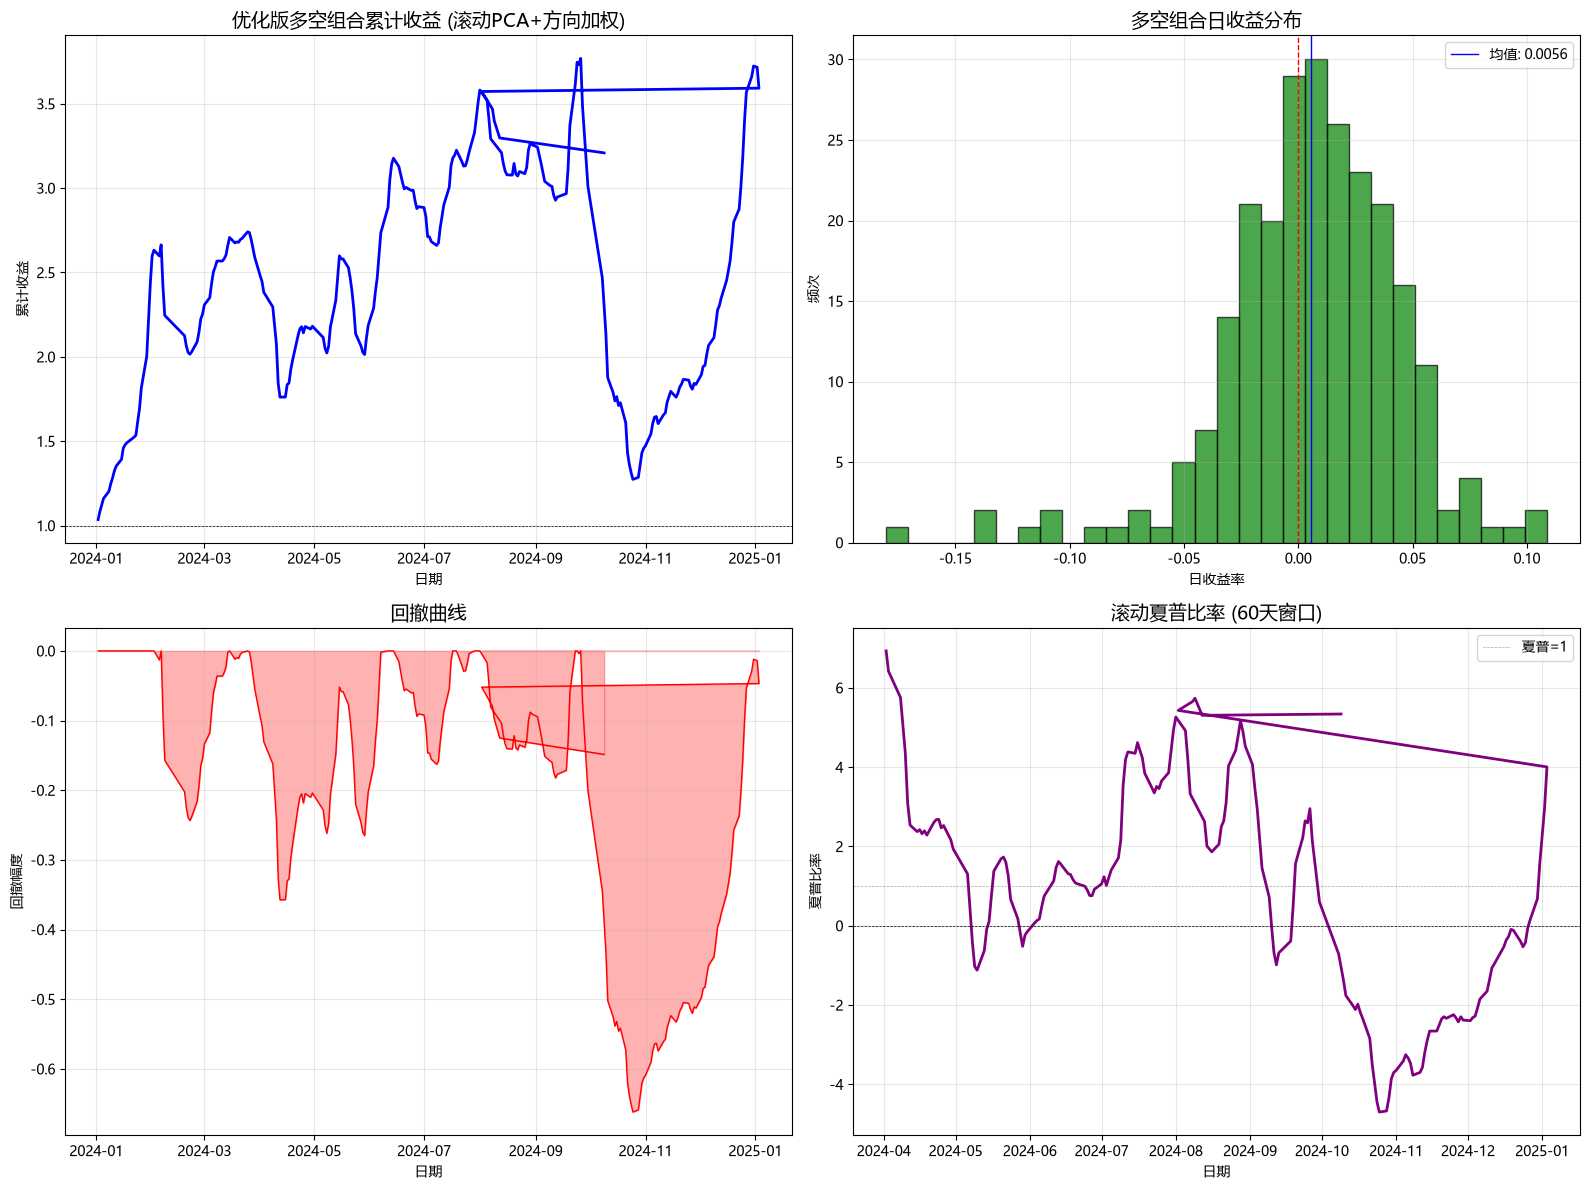


13. 分组收益分析


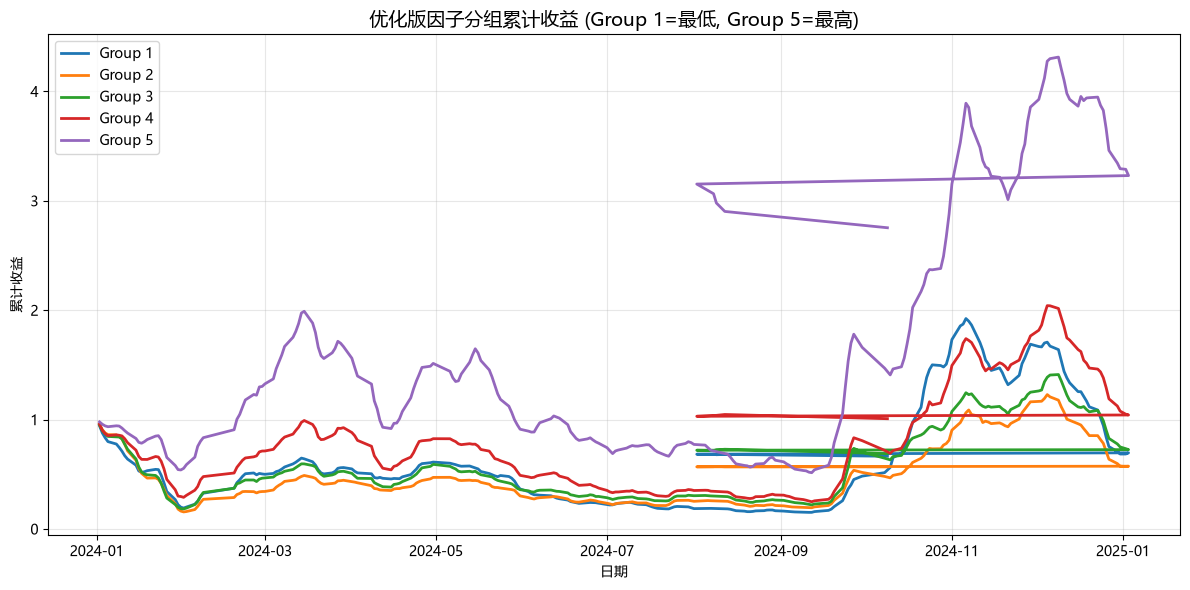


🎉 全部完成！


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from scipy.linalg import eigh
import itertools
import os
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False

# ==================== 数据读取和预处理 ====================
print("=" * 80)
print("1. 数据读取和预处理")
print("=" * 80)

# 读取数据
df = pd.read_csv('../extracted_data/stk_100.csv')
print(f"原始数据形状: {df.shape}")

# 转换日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'])
df = df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)

# 剔除ST股票
st_mask = df['ts_code'].str.contains('ST|st', na=False)
if st_mask.any():
    df = df[~st_mask]
    print(f"剔除ST股票后数据量: {len(df)}")

# 剔除涨跌停日
if 'pct_chg' in df.columns:
    limit_mask = (df['pct_chg'] >= 9.9) | (df['pct_chg'] <= -9.5)
    df = df[~limit_mask]
    print(f"剔除涨跌停日后数据量: {len(df)}")

# 剔除停牌日
if 'volume' in df.columns and 'amount' in df.columns:
    zero_mask = (df['volume'] == 0) | (df['amount'] == 0)
    df = df[~zero_mask]
    print(f"剔除停牌日后数据量: {len(df)}")

print(f"清洗后数据形状: {df.shape}")

# ==================== 计算基础衍生指标 ====================
print("\n" + "=" * 80)
print("2. 计算基础衍生指标")
print("=" * 80)

def calculate_derived_indicators(group):
    group = group.sort_values('trade_date').copy()
    
    if 'close' in group.columns and 'pre_close' in group.columns:
        group['daily_return'] = group['close'] / group['pre_close'] - 1
    elif 'close' in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    if 'vol' in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    if 'high' in group.columns and 'low' in group.columns:
        if 'pre_close' in group.columns:
            group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
        else:
            group['amplitude'] = (group['high'] - group['low']) / group['close'].shift(1)
    
    if 'amount' in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].rolling(20).mean()
    
    return group

unique_codes = df['ts_code'].unique().tolist()
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_derived_indicators(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print("基础衍生指标计算完成")

# ==================== 计算技术因子 ====================
print("\n" + "=" * 80)
print("3. 计算技术因子")
print("=" * 80)

def fill_factor_values(series, fill_method='forward'):
    if fill_method == 'forward':
        return series.ffill()
    elif fill_method == 'mean':
        return series.fillna(series.mean())
    elif fill_method == 'zero':
        return series.fillna(0)
    elif fill_method == 'median':
        return series.fillna(series.median())
    elif fill_method == 'ffill_bfill':
        return series.ffill().bfill()
    else:
        return series

def calculate_technical_factors(group):
    group = group.sort_values('trade_date').copy()
    
    if 'daily_return' not in group.columns:
        group['daily_return'] = group['close'].pct_change()
    
    if 'turnover_rate' not in group.columns:
        group['turnover_rate'] = group['vol'] / group['vol'].rolling(20).mean()
    
    if 'amplitude' not in group.columns:
        group['amplitude'] = (group['high'] - group['low']) / group['pre_close']
    
    if 'amount_ratio' not in group.columns:
        group['amount_ratio'] = group['amount'] / group['amount'].rolling(20).mean()
    
    factor_fill_methods = {}
    
    # RSI
    def calc_rsi(data, period):
        delta = data.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
        rs = gain / loss
        rsi = 100 - (100 / (1 + rs))
        return rsi
    
    for p in [6, 12, 24]:
        col = f'rsi_{p}'
        group[col] = calc_rsi(group['close'], p)
        factor_fill_methods[col] = 'forward'
    
    # MACD
    exp1 = group['close'].ewm(span=12, adjust=False).mean()
    exp2 = group['close'].ewm(span=26, adjust=False).mean()
    group['macd'] = exp1 - exp2
    group['macd_signal'] = group['macd'].ewm(span=9, adjust=False).mean()
    group['macd_hist'] = group['macd'] - group['macd_signal']
    factor_fill_methods['macd'] = 'forward'
    factor_fill_methods['macd_signal'] = 'forward'
    factor_fill_methods['macd_hist'] = 'forward'
    
    # MOM
    for p in [5, 10, 20]:
        col = f'mom_{p}'
        group[col] = group['close'] / group['close'].shift(p) - 1
        factor_fill_methods[col] = 'zero'
    
    # 均线偏离度
    for p in [5, 20, 60]:
        col = f'ma_dev_{p}'
        ma = group['close'].rolling(window=p).mean()
        group[col] = (group['close'] - ma) / ma
        factor_fill_methods[col] = 'forward'
    
    # ATR
    high_low = group['high'] - group['low']
    high_close = abs(group['high'] - group['close'].shift())
    low_close = abs(group['low'] - group['close'].shift())
    tr = pd.concat([high_low, high_close, low_close], axis=1).max(axis=1)
    group['atr_14'] = tr.rolling(window=14).mean()
    factor_fill_methods['atr_14'] = 'forward'
    
    # 历史波动率
    if 'daily_return' in group.columns:
        for p in [20, 60]:
            col = f'hist_vol_{p}'
            group[col] = group['daily_return'].rolling(window=p).std() * np.sqrt(252)
            factor_fill_methods[col] = 'forward'
    
    # 布林带宽度
    ma20 = group['close'].rolling(window=20).mean()
    std20 = group['close'].rolling(window=20).std()
    group['bollinger_band'] = (group['close'] - ma20) / (2 * std20)
    factor_fill_methods['bollinger_band'] = 'forward'
    
    # 成交量因子
    for p in [5, 10]:
        col = f'vr_{p}'
        group[col] = group['vol'] / group['vol'].rolling(window=p).mean()
        factor_fill_methods[col] = 'forward'
    
    # OBV
    obv = np.zeros(len(group))
    for i in range(1, len(group)):
        if group['close'].iloc[i] > group['close'].iloc[i-1]:
            obv[i] = obv[i-1] + group['vol'].iloc[i]
        elif group['close'].iloc[i] < group['close'].iloc[i-1]:
            obv[i] = obv[i-1] - group['vol'].iloc[i]
        else:
            obv[i] = obv[i-1]
    group['obv'] = obv
    factor_fill_methods['obv'] = 'forward'
    
    # 量价相关系数
    group['volume_price_corr'] = group['vol'].rolling(window=20).corr(group['close'])
    factor_fill_methods['volume_price_corr'] = 'zero'
    
    # 价格形态因子
    high_20 = group['high'].rolling(window=20).max()
    low_20 = group['low'].rolling(window=20).min()
    group['highest_lowest_pos'] = (group['close'] - low_20) / (high_20 - low_20)
    factor_fill_methods['highest_lowest_pos'] = 'forward'
    
    group['upper_shadow'] = (group['high'] - group[['open', 'close']].max(axis=1)) / (group['high'] - group['low'])
    group['lower_shadow'] = (group[['open', 'close']].min(axis=1) - group['low']) / (group['high'] - group['low'])
    factor_fill_methods['upper_shadow'] = 'forward'
    factor_fill_methods['lower_shadow'] = 'forward'
    
    group['body_ratio'] = abs(group['close'] - group['open']) / (group['high'] - group['low'])
    factor_fill_methods['body_ratio'] = 'forward'
    
    # 流动性因子
    group['amihud'] = abs(group['daily_return']) / (group['amount'] * 1e6)
    factor_fill_methods['amihud'] = 'median'
    
    group['log_amount'] = np.log(group['amount'] + 1)
    factor_fill_methods['log_amount'] = 'forward'
    
    # 应用填充策略
    for col, method in factor_fill_methods.items():
        if col in group.columns:
            group[col] = group[col].replace([np.inf, -np.inf], np.nan)
            try:
                group[col] = fill_factor_values(group[col], method)
            except Exception as e:
                group[col] = group[col].ffill().fillna(0)
            if group[col].isna().any():
                group[col] = group[col].ffill().bfill().fillna(0)
    
    return group

print("计算基础技术因子...")
df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_technical_factors(group)
    df_list.append(group)

df = pd.concat(df_list, ignore_index=True)
print("✅ 基础技术因子计算完成")

# 保存基础因子列名
base_factor_columns = [col for col in df.columns if col not in ['ts_code', 'trade_date', 'open', 'high', 'low', 'close', 
                                                                 'vol', 'amount', 'pre_close', 'change', 'pct_chg', 
                                                                 'daily_return', 'turnover_rate', 'amplitude', 
                                                                 'amount_ratio']]
print(f"基础技术因子数量: {len(base_factor_columns)}")

# ==================== 自动因子挖掘 ====================
print("\n" + "=" * 80)
print("4. 自动因子挖掘")
print("=" * 80)

def auto_factor_mining(df, lookback_periods=[5, 10, 20, 30, 60]):
    print("开始自动挖掘技术因子...")
    
    auto_factors_df = pd.DataFrame(index=df.index)
    unique_codes = df['ts_code'].unique()
    print(f"处理 {len(unique_codes)} 只股票...")
    
    for idx, code in enumerate(unique_codes):
        if idx % 20 == 0:
            print(f"  处理进度: {idx}/{len(unique_codes)}")
        
        stock_mask = df['ts_code'] == code
        stock_indices = df[stock_mask].index
        stock_data = df.loc[stock_mask].copy()
        stock_data = stock_data.sort_values('trade_date').reset_index(drop=True)
        
        if len(stock_data) < 60:
            continue
        
        stock_factors = {}
        
        # 价格比率因子
        for col in ['open', 'high', 'low', 'close']:
            if col in stock_data.columns:
                for p in lookback_periods:
                    stock_factors[f'{col}_ratio_{p}'] = stock_data[col] / stock_data[col].shift(p)
                    stock_factors[f'{col}_log_return_{p}'] = np.log(stock_data[col] / stock_data[col].shift(p) + 1e-6)
        
        # 价格范围因子
        stock_factors['high_low_ratio'] = stock_data['high'] / stock_data['low']
        stock_factors['close_open_ratio'] = stock_data['close'] / stock_data['open']
        stock_factors['high_close_ratio'] = stock_data['high'] / stock_data['close']
        stock_factors['low_close_ratio'] = stock_data['low'] / stock_data['close']
        
        # 移动平均及衍生因子
        for p in lookback_periods:
            ma = stock_data['close'].rolling(window=p).mean()
            stock_factors[f'ma_{p}'] = ma
            stock_factors[f'price_ma_ratio_{p}'] = stock_data['close'] / ma - 1
            
            ema = stock_data['close'].ewm(span=p, adjust=False).mean()
            stock_factors[f'price_ema_ratio_{p}'] = stock_data['close'] / ema - 1
            
            if p >= 20:
                ma_short = stock_data['close'].rolling(window=int(p/2)).mean()
                stock_factors[f'ma_cross_{p}'] = ma_short / ma - 1
            
            std = stock_data['close'].rolling(window=p).std()
            stock_factors[f'std_{p}'] = std
            stock_factors[f'std_ratio_{p}'] = std / (ma + 1e-6)
            
            returns = stock_data['close'].pct_change()
            stock_factors[f'volatility_{p}'] = returns.rolling(window=p).std() * np.sqrt(252)
            stock_factors[f'skew_{p}'] = returns.rolling(window=p).skew()
            stock_factors[f'kurtosis_{p}'] = returns.rolling(window=p).kurt()
            
            for q in [0.1, 0.25, 0.75, 0.9]:
                stock_factors[f'quantile_{q}_{p}'] = stock_data['close'].rolling(window=p).quantile(q)
                stock_factors[f'quantile_ratio_{q}_{p}'] = stock_data['close'] / (stock_factors[f'quantile_{q}_{p}'] + 1e-6) - 1
        
        # 成交量相关因子
        for p in lookback_periods:
            vol_ma = stock_data['vol'].rolling(window=p).mean()
            stock_factors[f'volume_ma_{p}'] = vol_ma
            stock_factors[f'volume_ma_ratio_{p}'] = stock_data['vol'] / vol_ma - 1
            stock_factors[f'volume_std_{p}'] = stock_data['vol'].rolling(window=p).std()
            
            amount_ma = stock_data['amount'].rolling(window=p).mean()
            stock_factors[f'amount_ma_{p}'] = amount_ma
            stock_factors[f'amount_ma_ratio_{p}'] = stock_data['amount'] / amount_ma - 1
        
        # 价格形态因子
        stock_factors['upper_shadow_auto'] = (stock_data['high'] - stock_data[['open', 'close']].max(axis=1)) / (stock_data['high'] - stock_data['low'] + 1e-6)
        stock_factors['lower_shadow_auto'] = (stock_data[['open', 'close']].min(axis=1) - stock_data['low']) / (stock_data['high'] - stock_data['low'] + 1e-6)
        stock_factors['body_ratio_auto'] = abs(stock_data['close'] - stock_data['open']) / (stock_data['high'] - stock_data['low'] + 1e-6)
        
        returns = stock_data['close'].pct_change()
        stock_factors['up_days'] = (returns > 0).rolling(window=10).sum()
        stock_factors['down_days'] = (returns < 0).rolling(window=10).sum()
        stock_factors['up_down_ratio'] = stock_factors['up_days'] / (stock_factors['down_days'] + 1e-6)
        
        stock_factors['new_high_20_auto'] = (stock_data['close'] == stock_data['close'].rolling(window=20).max()).astype(int)
        stock_factors['new_low_20_auto'] = (stock_data['close'] == stock_data['close'].rolling(window=20).min()).astype(int)
        
        # 量价关系因子
        for p in [5, 10, 20]:
            stock_factors[f'vol_price_corr_{p}'] = stock_data['vol'].rolling(window=p).corr(stock_data['close'])
        
        for factor_name, factor_values in stock_factors.items():
            if factor_name not in auto_factors_df.columns:
                auto_factors_df[factor_name] = np.nan
            auto_factors_df.loc[stock_indices, factor_name] = factor_values.values
    
    print("处理缺失值...")
    auto_factors_df = auto_factors_df.replace([np.inf, -np.inf], np.nan)
    auto_factors_df = auto_factors_df.ffill().bfill().fillna(0)
    
    print(f"自动挖掘因子数量: {auto_factors_df.shape[1]}")
    return auto_factors_df

auto_factors_df = auto_factor_mining(df)

# 合并自动挖掘因子
print("\n将自动挖掘因子合并到主数据...")
auto_factor_names = []
for col in auto_factors_df.columns:
    new_col_name = f'auto_{col}'
    if new_col_name in df.columns:
        counter = 1
        while f'{new_col_name}_{counter}' in df.columns:
            counter += 1
        new_col_name = f'{new_col_name}_{counter}'
    df[new_col_name] = auto_factors_df[col].values
    auto_factor_names.append(new_col_name)

print(f"合并后数据形状: {df.shape}")

# 所有因子列
all_factor_columns = list(dict.fromkeys(base_factor_columns + auto_factor_names))
print(f"总因子数量: {len(all_factor_columns)}")

# ==================== 因子预处理 ====================
print("\n" + "=" * 80)
print("5. 因子预处理")
print("=" * 80)

factor_data = df[all_factor_columns].copy()
factor_data = factor_data.replace([np.inf, -np.inf], np.nan)
factor_data = factor_data.ffill().bfill().fillna(0)

def mad_winsorize(data, n_sigma=5):
    if isinstance(data, pd.Series):
        values = data.values
    else:
        values = np.array(data)
    
    median = np.nanmedian(values)
    mad = np.nanmedian(np.abs(values - median))
    
    upper_bound = median + n_sigma * mad
    lower_bound = median - n_sigma * mad
    
    values_clipped = np.clip(values, lower_bound, upper_bound)
    
    if isinstance(data, pd.Series):
        return pd.Series(values_clipped, index=data.index)
    else:
        return values_clipped

print("进行MAD去极值处理...")
for idx, col in enumerate(all_factor_columns):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(all_factor_columns)}")
    factor_data[col] = mad_winsorize(factor_data[col])

print("进行Z-score标准化...")
scaler = StandardScaler()
factor_data_scaled = pd.DataFrame(scaler.fit_transform(factor_data), 
                                  columns=all_factor_columns, 
                                  index=factor_data.index)

print("进行规模中性化...")
log_amount = df['log_amount'].values.reshape(-1, 1)
factor_neutralized = pd.DataFrame(index=factor_data.index, columns=all_factor_columns)

for idx, col in enumerate(all_factor_columns):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(all_factor_columns)}")
    try:
        reg = LinearRegression()
        reg.fit(log_amount, factor_data_scaled[col].values.reshape(-1, 1))
        residual = factor_data_scaled[col].values - reg.predict(log_amount).flatten()
        factor_neutralized[col] = residual
    except Exception as e:
        factor_neutralized[col] = factor_data_scaled[col].values

print("因子预处理完成")

# 将预处理后的因子合并回原始数据
for col in all_factor_columns:
    df[f'{col}_processed'] = factor_neutralized[col]

# ==================== 计算未来5日收益 ====================
print("\n" + "=" * 80)
print("6. 计算未来5日收益")
print("=" * 80)

def calculate_future_returns(group):
    group = group.sort_values('trade_date').copy()
    group['future_5d_return'] = group['close'].shift(-5) / group['close'] - 1
    return group

df_list = []
for i, code in enumerate(unique_codes):
    if i % 10 == 0:
        print(f"  处理进度: {i}/{len(unique_codes)}")
    group = df[df['ts_code'] == code].copy()
    group = calculate_future_returns(group)
    df_list.append(group)
df = pd.concat(df_list, ignore_index=True)
print("✅ 未来5日收益计算完成")

# ==================== 计算IC/IR ====================
print("\n" + "=" * 80)
print("7. 计算IC/IR")
print("=" * 80)

factor_cols_processed = [col for col in df.columns if col.endswith('_processed')]
print(f"待检验因子数量: {len(factor_cols_processed)}")

ic_results = []
print("计算IC值...")
for idx, col in enumerate(factor_cols_processed):
    if idx % 50 == 0:
        print(f"  处理进度: {idx}/{len(factor_cols_processed)}")
    
    valid_data = df[[col, 'future_5d_return']].dropna()
    if len(valid_data) > 20:
        try:
            ic = stats.spearmanr(valid_data[col], valid_data['future_5d_return'])[0]
            if not np.isnan(ic):
                ic_results.append({
                    'factor': col,
                    'ic': ic,
                    'ic_abs': abs(ic),
                    'n_obs': len(valid_data)
                })
        except Exception as e:
            continue

ic_df = pd.DataFrame(ic_results).sort_values('ic_abs', ascending=False)
print(f"\n📊 计算完成，有效因子数量: {len(ic_df)}")

# ==================== 优化核心：滚动窗口PCA分组筛选（优化增强版） ====================
print("\n" + "=" * 80)
print("8. 滚动窗口PCA分组筛选（优化增强版）")
print("=" * 80)

def rolling_pca_optimized(df, all_factor_cols, ic_df, window_days=21, n_pcs=15, ic_threshold=0.025):
    """
    优化版滚动窗口PCA - 包含符号校正、综合评分（IC+单调性）、动态因子选择
    
    Parameters:
    - df: 主数据DataFrame
    - all_factor_cols: 所有因子列名
    - ic_df: IC结果DataFrame
    - window_days: 滚动窗口天数
    - n_pcs: 主成分数量
    - ic_threshold: IC绝对值阈值
    """
    # 确保参数是整数
    window_days = int(window_days)
    n_pcs = int(n_pcs)
    
    print(f"开始优化版滚动窗口PCA，窗口: {window_days}天，IC阈值: {ic_threshold}")
    
    # 获取所有日期
    all_dates = df['trade_date'].unique()
    all_dates = np.sort(all_dates)
    
    # ===== 定义因子类别（用于符号校正） =====
    factor_categories = {}
    for factor in all_factor_cols:
        factor_lower = factor.lower()
        if any(x in factor_lower for x in ['pe', 'pb', 'ps', 'pcf', 'value']):
            factor_categories[factor] = 'valuation'
        elif any(x in factor_lower for x in ['mom', 'momentum', 'trend', 'rsi', 'macd']):
            factor_categories[factor] = 'momentum'
        elif any(x in factor_lower for x in ['vol', 'atr', 'std', 'volatility']):
            factor_categories[factor] = 'volatility'
        elif any(x in factor_lower for x in ['volume', 'amount', 'turnover', 'vr']):
            factor_categories[factor] = 'volume'
        elif any(x in factor_lower for x in ['size', 'market_cap', 'log_amount']):
            factor_categories[factor] = 'size'
        else:
            factor_categories[factor] = 'other'
    
    # 预先计算IC字典
    ic_dict = {}
    for _, row in ic_df.iterrows():
        ic_dict[row['factor']] = {'ic': row['ic'], 'ic_abs': row['ic_abs']}
    
    # 存储结果
    pca_results = {}
    selected_factors_by_date = {}
    factor_selection_counts = {}
    
    # 从第window_days天开始
    start_idx = window_days
    
    for i in range(start_idx, len(all_dates)):
        current_date = all_dates[i]
        start_date = all_dates[i - window_days]
        window_mask = (df['trade_date'] >= start_date) & (df['trade_date'] < current_date)
        
        # ===== 获取窗口内因子数据 =====
        pca_data_list = []
        valid_factor_cols = []
        for factor in all_factor_cols:
            processed_col = f'{factor}_processed'
            if processed_col in df.columns:
                window_df = df[window_mask].groupby('ts_code')[processed_col].last()
                if len(window_df.dropna()) > 10:
                    pca_data_list.append(window_df)
                    valid_factor_cols.append(factor)
        
        if len(pca_data_list) < 5:
            continue
        
        # 构建PCA数据
        pca_data = pd.concat(pca_data_list, axis=1)
        pca_data.columns = valid_factor_cols
        pca_data = pca_data.replace([np.inf, -np.inf], np.nan).fillna(0)
        
        if pca_data.shape[0] < 10 or pca_data.shape[1] < 3:
            continue
        
        # 标准化
        scaler_roll = StandardScaler()
        pca_data_scaled = scaler_roll.fit_transform(pca_data)
        
        # ===== 执行PCA =====
        n_components = min(n_pcs, pca_data_scaled.shape[1], pca_data_scaled.shape[0] - 1)
        if n_components < 2:
            continue
        
        pca = PCA(n_components=n_components)
        pca.fit(pca_data_scaled)
        
        # 载荷矩阵
        loadings = pd.DataFrame(
            pca.components_.T,
            index=valid_factor_cols,
            columns=[f'PC{j+1}' for j in range(n_components)]
        )
        
        # ===== 符号校正 =====
        for pc_idx in range(n_components):
            pc_name = f'PC{pc_idx+1}'
            pc_loadings = loadings[pc_name]
            
            category_loadings = {}
            for category in set(factor_categories.values()):
                cat_factors = [f for f, c in factor_categories.items() if c == category and f in valid_factor_cols]
                cat_loadings = [pc_loadings[f] for f in cat_factors if f in pc_loadings.index]
                if len(cat_loadings) > 0:
                    category_loadings[category] = np.mean(cat_loadings)
            
            if len(category_loadings) > 0:
                max_category = max(category_loadings, key=category_loadings.get)
                if category_loadings[max_category] < 0:
                    loadings[pc_name] = -loadings[pc_name]
                    pca.components_[pc_idx, :] = -pca.components_[pc_idx, :]
        
        # 保存PCA结果
        pca_results[current_date] = {
            'pca': pca,
            'loadings': loadings,
            'explained_variance_ratio': pca.explained_variance_ratio_
        }
        
        # ===== 因子选择 =====
        n_pcs_to_use = min(n_pcs, len(loadings.columns))
        loadings_subset = loadings.iloc[:, :n_pcs_to_use]
        
        # 确定因子归属
        dominant_pc = np.abs(loadings_subset).idxmax(axis=1)
        max_load = np.abs(loadings_subset).max(axis=1)
        
        factor_groups = pd.DataFrame({
            'factor': loadings_subset.index,
            'dominant_pc': dominant_pc,
            'max_load': max_load
        })
        
        # 合并IC
        factor_groups['ic'] = factor_groups['factor'].map(lambda x: ic_dict.get(x, {}).get('ic', 0))
        factor_groups['ic_abs'] = factor_groups['factor'].map(lambda x: ic_dict.get(x, {}).get('ic_abs', 0))
        
        # ===== 提高IC过滤阈值 =====
        factor_groups = factor_groups[factor_groups['ic_abs'] > ic_threshold]
        
        if len(factor_groups) == 0:
            # 如果无因子通过，降低阈值到0.01
            factor_groups = pd.DataFrame({
                'factor': loadings_subset.index,
                'dominant_pc': dominant_pc,
                'max_load': max_load
            })
            factor_groups['ic'] = factor_groups['factor'].map(lambda x: ic_dict.get(x, {}).get('ic', 0))
            factor_groups['ic_abs'] = factor_groups['factor'].map(lambda x: ic_dict.get(x, {}).get('ic_abs', 0))
            factor_groups = factor_groups[factor_groups['ic_abs'] > 0.01]
        
        # ===== 计算单调性（用于综合评分） =====
        def calc_monotonicity_fast(factor_name, df_subset, n_groups=5):
            """快速计算因子单调性"""
            try:
                valid_data = df_subset[[factor_name, 'future_5d_return']].dropna()
                if len(valid_data) < 30:
                    return 0.0
                valid_data['group'] = pd.qcut(valid_data[factor_name], q=n_groups, labels=False, duplicates='drop')
                if len(valid_data['group'].unique()) < 3:
                    return 0.0
                group_returns = valid_data.groupby('group')['future_5d_return'].mean()
                if len(group_returns) >= 3:
                    corr = stats.spearmanr(range(len(group_returns)), group_returns.values)[0]
                    return abs(corr) if not np.isnan(corr) else 0.0
            except:
                pass
            return 0.0
        
        # 获取当前窗口的数据用于计算单调性
        window_data = df[window_mask].copy()
        
        # 计算每个因子的单调性（确保返回浮点数）
        factor_groups['monotonicity'] = factor_groups['factor'].apply(
            lambda x: float(calc_monotonicity_fast(f'{x}_processed', window_data))
        )
        
        # ===== 综合评分：IC_abs * 0.50 + 单调性 * 0.50 =====
        # 确保所有值都是数值类型
        factor_groups['ic_abs'] = factor_groups['ic_abs'].astype(float)
        factor_groups['monotonicity'] = factor_groups['monotonicity'].astype(float)
        factor_groups['score'] = factor_groups['ic_abs'] * 0.5 + factor_groups['monotonicity'] * 0.5
        
        # ===== 每组选择最优因子 =====
        selected_factors = []
        for pc_group in factor_groups['dominant_pc'].unique():
            group_factors = factor_groups[factor_groups['dominant_pc'] == pc_group].sort_values('score', ascending=False)
            if len(group_factors) > 0:
                selected_factors.append(group_factors.iloc[0]['factor'])
                # 如果该组因子多且质量好，选第2个
                if len(group_factors) >= 3 and group_factors.iloc[1]['score'] > group_factors.iloc[0]['score'] * 0.7:
                    selected_factors.append(group_factors.iloc[1]['factor'])
        
        # ===== 确保至少有15个因子 =====
        TARGET_MIN_FACTORS = 15
        if len(selected_factors) < TARGET_MIN_FACTORS:
            selected_set = set(selected_factors)
            remaining = factor_groups[~factor_groups['factor'].isin(selected_set)].sort_values('score', ascending=False)
            
            # 计算需要补充的数量，确保是整数
            need_count = TARGET_MIN_FACTORS - len(selected_factors)
            remain_count = len(remaining)
            n_to_add = int(max(0, min(need_count, remain_count)))
            
            for j in range(n_to_add):
                if j < len(remaining):
                    selected_factors.append(remaining.iloc[j]['factor'])
        
        # ===== 截断到25个 =====
        if len(selected_factors) > 25:
            # 获取每个因子的评分
            scores = []
            for f in selected_factors:
                score_val = factor_groups[factor_groups['factor'] == f]['score'].values
                if len(score_val) > 0:
                    scores.append(float(score_val[0]))
                else:
                    scores.append(0.0)
            sorted_idx = np.argsort(scores)[::-1]
            selected_factors = [selected_factors[i] for i in sorted_idx[:25]]
        
        selected_factors_by_date[current_date] = selected_factors
        
        # 统计频率
        for f in selected_factors:
            factor_selection_counts[f] = factor_selection_counts.get(f, 0) + 1
        
        if i % 50 == 0:
            try:
                date_str = pd.Timestamp(current_date).strftime('%Y-%m-%d') if isinstance(current_date, np.datetime64) else current_date.strftime('%Y-%m-%d')
                print(f"  日期 {date_str}: 选择 {len(selected_factors)} 个因子")
            except:
                print(f"  日期 {current_date}: 选择 {len(selected_factors)} 个因子")
    
    print(f"滚动窗口PCA完成，处理 {len(pca_results)} 个日期")
    
    return pca_results, selected_factors_by_date, factor_selection_counts, factor_categories

# 执行优化版滚动窗口PCA
print("\n执行优化版滚动窗口PCA...")
pca_results, selected_factors_by_date, factor_selection_counts, factor_categories = rolling_pca_optimized(
    df, 
    all_factor_columns, 
    ic_df,
    window_days=21,
    n_pcs=15,
    ic_threshold=0.0025
)



# ==================== 构建最终因子池 ====================
print("\n" + "=" * 80)
print("9. 构建最终因子池")
print("=" * 80)

if len(factor_selection_counts) == 0:
    print("⚠️ 无因子被选中，使用IC最高的前25个因子作为备选")
    top_ic_factors = ic_df.head(25)['factor'].tolist()
    top_factors = [f.replace('_processed', '') for f in top_ic_factors]
    selection_freq = {f: 1.0 for f in top_factors}
else:
    # 计算选择频率
    total_dates = len(selected_factors_by_date)
    selection_freq = {f: count / total_dates for f, count in factor_selection_counts.items()}
    
    # 排序
    selection_df = pd.DataFrame({
        'factor': list(selection_freq.keys()),
        'frequency': list(selection_freq.values())
    }).sort_values('frequency', ascending=False)
    
    print(f"共 {len(selection_df)} 个因子被选中")
    
    # 选择频率最高的前25个
    top_factors = selection_df.head(25)['factor'].tolist()

print(f"\n🎯 最终选择 {len(top_factors)} 个因子")

# 显示选中的因子
print("\n最终选中的因子（按频率排序）:")
for i, f in enumerate(top_factors[:25]):
    category = factor_categories.get(f, 'unknown')
    freq = selection_freq.get(f, 0)
    ic_info = ic_df[ic_df['factor'] == f'{f}_processed']
    ic_val = ic_info['ic'].values[0] if len(ic_info) > 0 else 0
    print(f"  {i+1:2d}. {f[:35]:<35} | 频率: {freq:.1%} | IC: {ic_val:.4f} | 类别: {category}")

# ==================== 优化回测：方向加权组合 ====================
print("\n" + "=" * 80)
print("10. 优化回测：方向加权组合")
print("=" * 80)

# 获取选中的因子数据
selected_factors_processed = []
for f in top_factors:
    processed_name = f'{f}_processed'
    if processed_name in df.columns:
        selected_factors_processed.append(processed_name)

if len(selected_factors_processed) == 0:
    print("❌ 无有效因子")
    # 备选方案
    top_ic_factors = ic_df.head(30)['factor'].tolist()
    selected_factors_processed = [f for f in top_ic_factors if f in df.columns]
    print(f"使用备选方案: {len(selected_factors_processed)} 个因子")

if len(selected_factors_processed) == 0:
    print("❌ 无法进行回测")
else:
    print(f"使用 {len(selected_factors_processed)} 个因子进行回测")
    
    # ===== 构建方向加权组合 =====
    print("构建方向加权因子组合...")
    
    # 获取每个因子的IC符号和强度
    factor_info = {}
    for factor in selected_factors_processed:
        ic_info = ic_df[ic_df['factor'] == factor]
        if len(ic_info) > 0:
            factor_info[factor] = {
                'direction': 1 if ic_info['ic'].values[0] > 0 else -1,
                'weight': abs(ic_info['ic'].values[0])
            }
    
    factor_returns = []
    
    for date in df['trade_date'].unique():
        date_mask = df['trade_date'] == date
        if date_mask.sum() == 0:
            continue
        
        date_df = df[date_mask].copy()
        
        composite_score = np.zeros(len(date_df))
        total_weight = 0
        valid_factors = []
        
        for factor in selected_factors_processed:
            if factor in date_df.columns and factor in factor_info:
                factor_values = date_df[factor].values
                factor_mean = np.nanmean(factor_values)
                factor_std = np.nanstd(factor_values)
                if factor_std > 0:
                    factor_zscore = (factor_values - factor_mean) / factor_std
                    direction = factor_info[factor]['direction']
                    weight = factor_info[factor]['weight']
                    composite_score += direction * weight * factor_zscore
                    total_weight += weight
                    valid_factors.append(factor)
        
        if len(valid_factors) == 0 or total_weight == 0:
            continue
        
        composite_score = composite_score / total_weight
        
        score_df = pd.DataFrame({
            'ts_code': date_df['ts_code'].values,
            'composite_score': composite_score,
            'future_return': date_df['future_5d_return'].values
        }).dropna()
        
        if len(score_df) > 10:
            try:
                score_df['group'] = pd.qcut(score_df['composite_score'], q=5, labels=False, duplicates='drop')
                group_returns = score_df.groupby('group')['future_return'].mean()
                
                if len(group_returns) >= 5:
                    long_short_return = group_returns.iloc[4] - group_returns.iloc[0]
                    factor_returns.append({
                        'date': date,
                        'long_short_return': long_short_return,
                        'group_returns': group_returns.tolist()
                    })
            except Exception as e:
                continue
    
    # 转换为DataFrame
    factor_returns_df = pd.DataFrame(factor_returns)
    
    if len(factor_returns_df) == 0:
        print("❌ 没有有效的回测结果")
    else:
        print(f"回测期间: {factor_returns_df['date'].min()} 至 {factor_returns_df['date'].max()}")
        print(f"回测天数: {len(factor_returns_df)}")
        
        # ==================== 回测指标计算 ====================
        print("\n" + "=" * 80)
        print("11. 回测指标计算")
        print("=" * 80)
        
        factor_returns_df['cumulative_return'] = (1 + factor_returns_df['long_short_return']).cumprod()
        
        total_days = len(factor_returns_df)
        total_return = factor_returns_df['cumulative_return'].iloc[-1] - 1
        annualized_return = (1 + total_return) ** (252 / total_days) - 1
        annualized_volatility = factor_returns_df['long_short_return'].std() * np.sqrt(252)
        sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility > 0 else 0
        
        cumulative = factor_returns_df['cumulative_return'].values
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        win_rate = (factor_returns_df['long_short_return'] > 0).mean()
        positive_returns = factor_returns_df[factor_returns_df['long_short_return'] > 0]['long_short_return']
        negative_returns = factor_returns_df[factor_returns_df['long_short_return'] < 0]['long_short_return']
        profit_loss_ratio = positive_returns.mean() / abs(negative_returns.mean()) if len(negative_returns) > 0 else np.inf
        
        print("\n📊 优化版回测指标:")
        print(f"  年化收益率: {annualized_return:.2%}")
        print(f"  年化波动率: {annualized_volatility:.2%}")
        print(f"  夏普比率: {sharpe_ratio:.2f}")
        print(f"  最大回撤: {max_drawdown:.2%}")
        print(f"  胜率: {win_rate:.2%}")
        print(f"  盈亏比: {profit_loss_ratio:.2f}")
        print(f"  累计收益: {total_return:.2%}")
        
        # ==================== 绘制回测曲线 ====================
        print("\n" + "=" * 80)
        print("12. 绘制回测曲线")
        print("=" * 80)
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        ax1 = axes[0, 0]
        ax1.plot(factor_returns_df['date'], factor_returns_df['cumulative_return'], linewidth=2, color='blue')
        ax1.axhline(y=1, color='black', linestyle='--', linewidth=0.5)
        ax1.set_title('优化版多空组合累计收益 (滚动PCA+方向加权)', fontsize=14)
        ax1.set_xlabel('日期')
        ax1.set_ylabel('累计收益')
        ax1.grid(True, alpha=0.3)
        
        ax2 = axes[0, 1]
        ax2.hist(factor_returns_df['long_short_return'], bins=30, alpha=0.7, color='green', edgecolor='black')
        ax2.axvline(x=0, color='red', linestyle='--', linewidth=1)
        ax2.axvline(x=factor_returns_df['long_short_return'].mean(), color='blue', linestyle='-', linewidth=1, 
                    label=f'均值: {factor_returns_df["long_short_return"].mean():.4f}')
        ax2.set_title('多空组合日收益分布', fontsize=14)
        ax2.set_xlabel('日收益率')
        ax2.set_ylabel('频次')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        ax3 = axes[1, 0]
        ax3.fill_between(factor_returns_df['date'], 0, drawdown, alpha=0.3, color='red')
        ax3.plot(factor_returns_df['date'], drawdown, color='red', linewidth=1)
        ax3.set_title('回撤曲线', fontsize=14)
        ax3.set_xlabel('日期')
        ax3.set_ylabel('回撤幅度')
        ax3.grid(True, alpha=0.3)
        
        ax4 = axes[1, 1]
        rolling_sharpe = factor_returns_df['long_short_return'].rolling(60).apply(
            lambda x: x.mean() / (x.std() + 1e-6) * np.sqrt(252) if len(x) > 20 else np.nan
        )
        ax4.plot(factor_returns_df['date'], rolling_sharpe, linewidth=2, color='purple')
        ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
        ax4.axhline(y=1, color='green', linestyle='--', linewidth=0.5, alpha=0.5, label='夏普=1')
        ax4.set_title('滚动夏普比率 (60天窗口)', fontsize=14)
        ax4.set_xlabel('日期')
        ax4.set_ylabel('夏普比率')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # ==================== 分组收益分析 ====================
        print("\n" + "=" * 80)
        print("13. 分组收益分析")
        print("=" * 80)
        
        if 'group_returns' in factor_returns_df.columns:
            group_returns_matrix = np.array(factor_returns_df['group_returns'].tolist())
            
            fig, ax = plt.subplots(figsize=(12, 6))
            for i in range(5):
                cum_ret = (1 + group_returns_matrix[:, i]).cumprod()
                ax.plot(factor_returns_df['date'], cum_ret, label=f'Group {i+1}', linewidth=2)
            
            ax.set_title('优化版因子分组累计收益 (Group 1=最低, Group 5=最高)', fontsize=14)
            ax.set_xlabel('日期')
            ax.set_ylabel('累计收益')
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

print("\n🎉 全部完成！")


8. 优化方案：IC筛选 + PCA权重优化
选择IC最高的 30 个因子

IC最高的30个因子:
   1. auto_volatility_20_processed        | IC: 0.0844
   2. hist_vol_60_processed               | IC: -0.0731
   3. hist_vol_20_processed               | IC: 0.0726
   4. auto_kurtosis_20_processed          | IC: 0.0718
   5. rsi_12_processed                    | IC: 0.0616
   6. highest_lowest_pos_processed        | IC: 0.0591
   7. auto_open_ratio_60_processed        | IC: -0.0568
   8. auto_open_log_return_60_processed   | IC: -0.0563
   9. auto_vol_price_corr_20_processed    | IC: -0.0561
  10. auto_low_ratio_60_processed         | IC: -0.0541
  11. auto_low_log_return_60_processed    | IC: -0.0538
  12. ma_dev_20_processed                 | IC: 0.0523
  13. auto_high_ratio_60_processed        | IC: -0.0521
  14. auto_high_log_return_60_processed   | IC: -0.0516
  15. auto_quantile_ratio_0.1_20_processe | IC: 0.0511
  16. auto_price_ema_ratio_60_processed   | IC: -0.0509
  17. auto_close_ratio_60_processed       | IC: -0.0509
  1

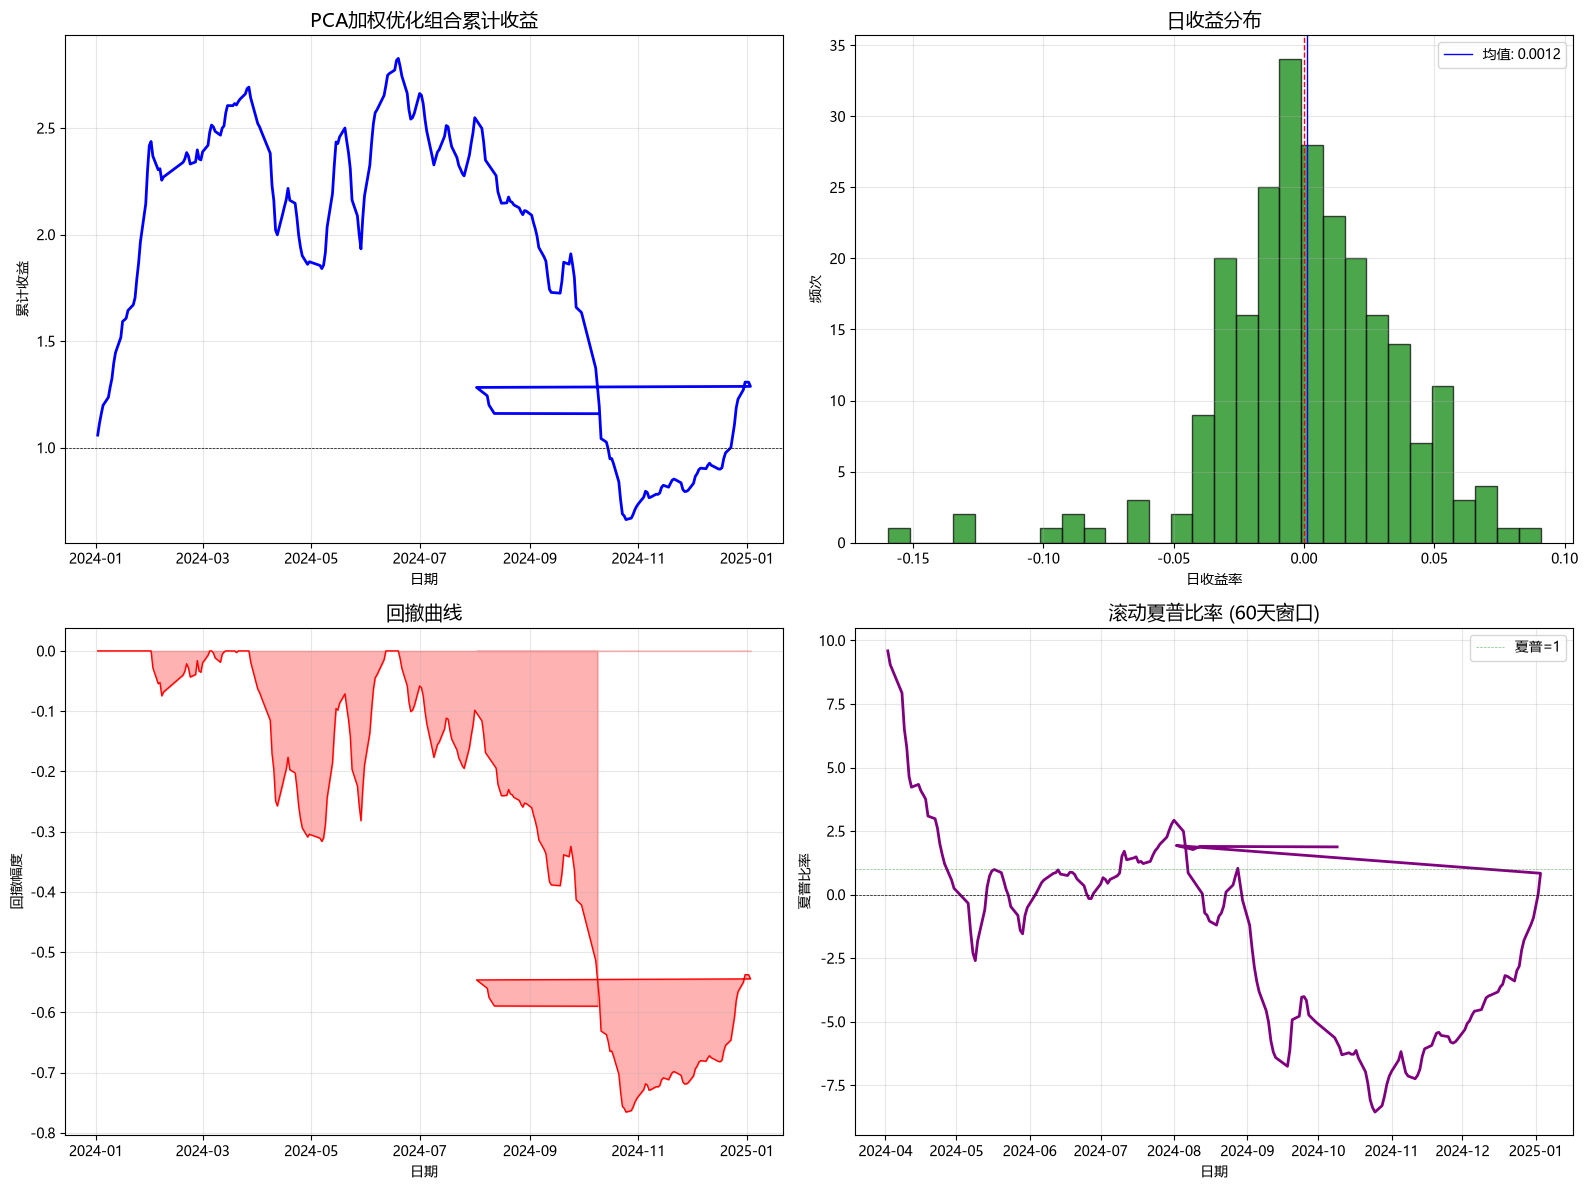


12. 分组收益分析


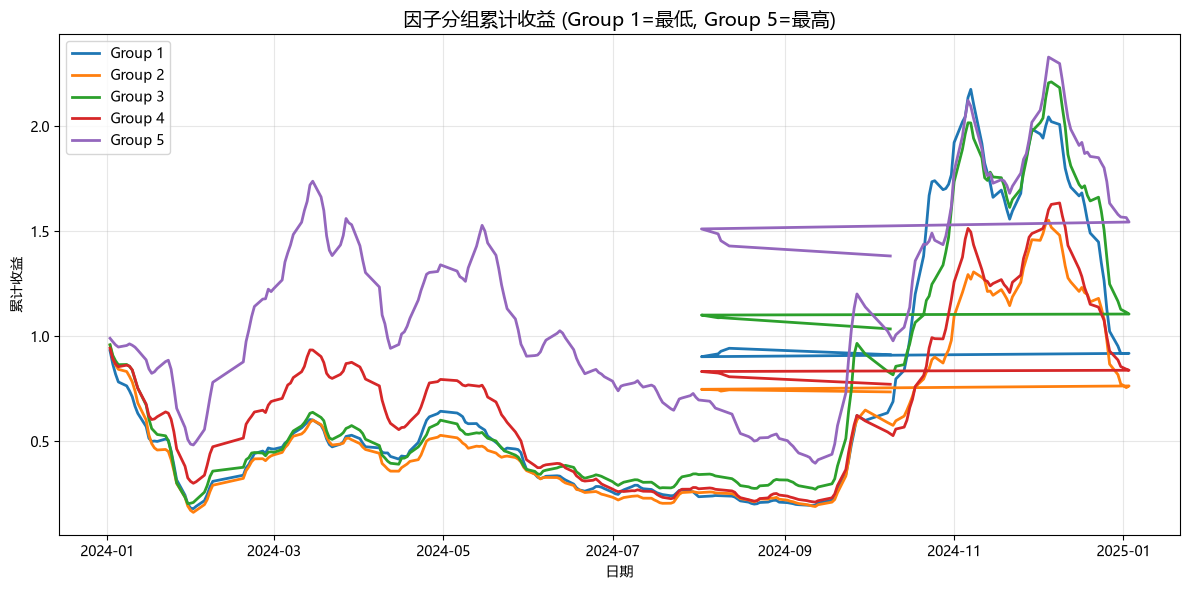


🎉 全部完成！


In [15]:
# ==================== 优化方案：IC筛选 + PCA权重优化 ====================
print("\n" + "=" * 80)
print("8. 优化方案：IC筛选 + PCA权重优化")
print("=" * 80)

# 第一步：选择IC最高的前N个因子（不进行PCA分组）
IC_TOP_N = 30  # 选择IC最高的30个因子

# 获取IC最高的因子
top_ic_factors = ic_df.nlargest(IC_TOP_N, 'ic_abs')['factor'].tolist()
print(f"选择IC最高的 {len(top_ic_factors)} 个因子")

# 提取这些因子的原始名称
top_ic_factors_original = [f.replace('_processed', '') for f in top_ic_factors]

# 显示选中的因子
print("\nIC最高的30个因子:")
for i, f in enumerate(top_ic_factors[:30]):
    ic_info = ic_df[ic_df['factor'] == f]
    ic_val = ic_info['ic'].values[0] if len(ic_info) > 0 else 0
    print(f"  {i+1:2d}. {f[:35]:<35} | IC: {ic_val:.4f}")

# 第二步：对这30个因子进行PCA，提取主成分
print("\n对Top因子进行PCA降维...")

# 准备数据
pca_data_list = []
for factor in top_ic_factors:
    if factor in df.columns:
        pca_data_list.append(df[factor].values.reshape(-1, 1))

if len(pca_data_list) > 1:
    pca_data = np.concatenate(pca_data_list, axis=1)
    pca_data = pd.DataFrame(pca_data, columns=top_ic_factors)
    pca_data = pca_data.replace([np.inf, -np.inf], np.nan).fillna(0)
    
    # 标准化
    scaler_pca = StandardScaler()
    pca_data_scaled = scaler_pca.fit_transform(pca_data)
    
    # 执行PCA，保留主成分数量为原因子数的50%
    n_pcs = min(10, len(top_ic_factors) // 2)
    pca = PCA(n_components=n_pcs)
    pca_result = pca.fit_transform(pca_data_scaled)
    
    print(f"PCA完成，保留 {n_pcs} 个主成分")
    print(f"累计方差贡献率: {np.sum(pca.explained_variance_ratio_):.2%}")
    
    # 获取载荷矩阵，用于后续的因子权重计算
    loadings = pd.DataFrame(
        pca.components_.T,
        index=top_ic_factors,
        columns=[f'PC{i+1}' for i in range(n_pcs)]
    )
    
    # 计算每个主成分的IC
    pc_ic_results = []
    for pc_idx in range(n_pcs):
        pc_col = f'PC{pc_idx+1}'
        pc_values = pca_result[:, pc_idx]
        
        # 计算与未来收益的IC
        valid_mask = ~np.isnan(pc_values) & ~np.isnan(df['future_5d_return'].values)
        if valid_mask.sum() > 20:
            ic = stats.spearmanr(pc_values[valid_mask], df['future_5d_return'].values[valid_mask])[0]
            if not np.isnan(ic):
                pc_ic_results.append({
                    'pc': pc_col,
                    'ic': ic,
                    'ic_abs': abs(ic),
                    'explained_variance': pca.explained_variance_ratio_[pc_idx]
                })
    
    pc_ic_df = pd.DataFrame(pc_ic_results).sort_values('ic_abs', ascending=False)
    print("\n主成分IC排名:")
    for idx, row in pc_ic_df.iterrows():
        print(f"  {row['pc']}: IC={row['ic']:.4f}, 解释方差={row['explained_variance']:.2%}")
    
    # 第三步：选择IC最高的前K个主成分
    K = min(5, len(pc_ic_df))
    selected_pcs = pc_ic_df.head(K)['pc'].tolist()
    print(f"\n选择IC最高的 {K} 个主成分: {selected_pcs}")
    
    # 第四步：使用选中的主成分构建组合
    # 获取选中主成分的载荷，计算因子权重
    selected_loadings = loadings[selected_pcs]
    
    # 计算每个因子的综合权重（载荷加权）
    factor_weights = {}
    for factor in top_ic_factors:
        # 使用IC绝对值作为权重，结合载荷
        ic_abs = ic_df[ic_df['factor'] == factor]['ic_abs'].values[0] if len(ic_df[ic_df['factor'] == factor]) > 0 else 0
        load_sum = selected_loadings.loc[factor].abs().sum()
        factor_weights[factor] = ic_abs * load_sum
    
    # 归一化权重
    total_weight = sum(factor_weights.values())
    if total_weight > 0:
        factor_weights = {k: v / total_weight for k, v in factor_weights.items()}
    
    print("\n因子权重（Top 10）:")
    sorted_weights = sorted(factor_weights.items(), key=lambda x: x[1], reverse=True)
    for factor, weight in sorted_weights[:10]:
        ic_info = ic_df[ic_df['factor'] == factor]
        ic_val = ic_info['ic'].values[0] if len(ic_info) > 0 else 0
        print(f"  {factor[:35]:<35} | 权重: {weight:.4f} | IC: {ic_val:.4f}")
    
    # 第五步：使用加权因子进行回测
    print("\n" + "=" * 80)
    print("9. PCA优化加权回测")
    print("=" * 80)
    
    # 使用选中的因子进行回测（加权组合）
    selected_factors_processed = top_ic_factors
    
    print(f"使用 {len(selected_factors_processed)} 个因子进行回测")
    print("构建PCA加权因子组合...")
    
    factor_returns = []
    
    for date in df['trade_date'].unique():
        date_mask = df['trade_date'] == date
        if date_mask.sum() == 0:
            continue
        
        date_df = df[date_mask].copy()
        
        composite_score = np.zeros(len(date_df))
        total_weight = 0
        valid_factors = []
        
        for factor in selected_factors_processed:
            if factor in date_df.columns and factor in factor_weights:
                factor_values = date_df[factor].values
                factor_mean = np.nanmean(factor_values)
                factor_std = np.nanstd(factor_values)
                if factor_std > 0:
                    factor_zscore = (factor_values - factor_mean) / factor_std
                    weight = factor_weights[factor]
                    # 使用IC符号确定方向
                    ic_info = ic_df[ic_df['factor'] == factor]
                    direction = 1 if len(ic_info) > 0 and ic_info['ic'].values[0] > 0 else -1
                    composite_score += direction * weight * factor_zscore
                    total_weight += weight
                    valid_factors.append(factor)
        
        if len(valid_factors) == 0 or total_weight == 0:
            continue
        
        composite_score = composite_score / total_weight
        
        score_df = pd.DataFrame({
            'ts_code': date_df['ts_code'].values,
            'composite_score': composite_score,
            'future_return': date_df['future_5d_return'].values
        }).dropna()
        
        if len(score_df) > 10:
            try:
                score_df['group'] = pd.qcut(score_df['composite_score'], q=5, labels=False, duplicates='drop')
                group_returns = score_df.groupby('group')['future_return'].mean()
                
                if len(group_returns) >= 5:
                    long_short_return = group_returns.iloc[4] - group_returns.iloc[0]
                    factor_returns.append({
                        'date': date,
                        'long_short_return': long_short_return,
                        'group_returns': group_returns.tolist()
                    })
            except Exception as e:
                continue
    
    # 转换为DataFrame
    factor_returns_df = pd.DataFrame(factor_returns)
    
    if len(factor_returns_df) == 0:
        print("❌ 没有有效的回测结果")
    else:
        print(f"回测期间: {factor_returns_df['date'].min()} 至 {factor_returns_df['date'].max()}")
        print(f"回测天数: {len(factor_returns_df)}")
        
        # ==================== 回测指标计算 ====================
        print("\n" + "=" * 80)
        print("10. 回测指标计算")
        print("=" * 80)
        
        factor_returns_df['cumulative_return'] = (1 + factor_returns_df['long_short_return']).cumprod()
        
        total_days = len(factor_returns_df)
        total_return = factor_returns_df['cumulative_return'].iloc[-1] - 1
        annualized_return = (1 + total_return) ** (252 / total_days) - 1
        annualized_volatility = factor_returns_df['long_short_return'].std() * np.sqrt(252)
        sharpe_ratio = annualized_return / annualized_volatility if annualized_volatility > 0 else 0
        
        cumulative = factor_returns_df['cumulative_return'].values
        running_max = np.maximum.accumulate(cumulative)
        drawdown = (cumulative - running_max) / running_max
        max_drawdown = drawdown.min()
        
        win_rate = (factor_returns_df['long_short_return'] > 0).mean()
        positive_returns = factor_returns_df[factor_returns_df['long_short_return'] > 0]['long_short_return']
        negative_returns = factor_returns_df[factor_returns_df['long_short_return'] < 0]['long_short_return']
        profit_loss_ratio = positive_returns.mean() / abs(negative_returns.mean()) if len(negative_returns) > 0 else np.inf
        
        print("\n📊 PCA优化加权回测指标:")
        print(f"  年化收益率: {annualized_return:.2%}")
        print(f"  年化波动率: {annualized_volatility:.2%}")
        print(f"  夏普比率: {sharpe_ratio:.2f}")
        print(f"  最大回撤: {max_drawdown:.2%}")
        print(f"  胜率: {win_rate:.2%}")
        print(f"  盈亏比: {profit_loss_ratio:.2f}")
        print(f"  累计收益: {total_return:.2%}")
        
        # ==================== 绘制回测曲线 ====================
        print("\n" + "=" * 80)
        print("11. 绘制回测曲线")
        print("=" * 80)
        
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        ax1 = axes[0, 0]
        ax1.plot(factor_returns_df['date'], factor_returns_df['cumulative_return'], linewidth=2, color='blue')
        ax1.axhline(y=1, color='black', linestyle='--', linewidth=0.5)
        ax1.set_title('PCA加权优化组合累计收益', fontsize=14)
        ax1.set_xlabel('日期')
        ax1.set_ylabel('累计收益')
        ax1.grid(True, alpha=0.3)
        
        ax2 = axes[0, 1]
        ax2.hist(factor_returns_df['long_short_return'], bins=30, alpha=0.7, color='green', edgecolor='black')
        ax2.axvline(x=0, color='red', linestyle='--', linewidth=1)
        ax2.axvline(x=factor_returns_df['long_short_return'].mean(), color='blue', linestyle='-', linewidth=1, 
                    label=f'均值: {factor_returns_df["long_short_return"].mean():.4f}')
        ax2.set_title('日收益分布', fontsize=14)
        ax2.set_xlabel('日收益率')
        ax2.set_ylabel('频次')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        ax3 = axes[1, 0]
        ax3.fill_between(factor_returns_df['date'], 0, drawdown, alpha=0.3, color='red')
        ax3.plot(factor_returns_df['date'], drawdown, color='red', linewidth=1)
        ax3.set_title('回撤曲线', fontsize=14)
        ax3.set_xlabel('日期')
        ax3.set_ylabel('回撤幅度')
        ax3.grid(True, alpha=0.3)
        
        ax4 = axes[1, 1]
        rolling_sharpe = factor_returns_df['long_short_return'].rolling(60).apply(
            lambda x: x.mean() / (x.std() + 1e-6) * np.sqrt(252) if len(x) > 20 else np.nan
        )
        ax4.plot(factor_returns_df['date'], rolling_sharpe, linewidth=2, color='purple')
        ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
        ax4.axhline(y=1, color='green', linestyle='--', linewidth=0.5, alpha=0.5, label='夏普=1')
        ax4.set_title('滚动夏普比率 (60天窗口)', fontsize=14)
        ax4.set_xlabel('日期')
        ax4.set_ylabel('夏普比率')
        ax4.legend()
        ax4.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # ==================== 分组收益分析 ====================
        print("\n" + "=" * 80)
        print("12. 分组收益分析")
        print("=" * 80)
        
        if 'group_returns' in factor_returns_df.columns:
            group_returns_matrix = np.array(factor_returns_df['group_returns'].tolist())
            
            fig, ax = plt.subplots(figsize=(12, 6))
            for i in range(5):
                cum_ret = (1 + group_returns_matrix[:, i]).cumprod()
                ax.plot(factor_returns_df['date'], cum_ret, label=f'Group {i+1}', linewidth=2)
            
            ax.set_title('因子分组累计收益 (Group 1=最低, Group 5=最高)', fontsize=14)
            ax.set_xlabel('日期')
            ax.set_ylabel('累计收益')
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

print("\n🎉 全部完成！")

In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import warnings
warnings.filterwarnings('ignore')

# 读取数据
file_path = '../extracted_data/selected_factors_with_data1.csv'
df = pd.read_csv(file_path)

# 定义因变量和自变量
target = 'daily_return'
features = ['auto_volatility_60', 'auto_std_60_1', 'auto_amount_ma_30', 
            'auto_open_ratio_60', 'auto_quantile_0.75_30']

# 检查数据中是否存在这些列
available_features = [col for col in features if col in df.columns]
available_target = target if target in df.columns else None

if available_target is None:
    print(f"错误: 因变量 '{target}' 不存在于数据中")
    print(f"可用的列: {df.columns.tolist()}")
    exit()

print(f"因变量: {available_target}")
print(f"自变量: {available_features}")
print(f"数据形状: {df.shape}")
print("\n" + "="*60)

# 方法1: 使用statsmodels的variance_inflation_factor函数
def calculate_vif_using_statsmodels(data, features):
    """使用statsmodels计算VIF"""
    # 添加常数项
    X = add_constant(data[features])
    
    # 计算每个特征的VIF
    vif_data = pd.DataFrame()
    vif_data['Variable'] = features
    vif_data['VIF'] = [variance_inflation_factor(X.values, i+1) for i in range(len(features))]
    
    return vif_data

# 方法2: 手动计算VIF
def calculate_vif_manually(data, features):
    """手动计算VIF"""
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import r2_score
    
    vif_results = []
    
    for i, feature in enumerate(features):
        # 当前特征作为因变量
        y = data[feature].values.reshape(-1, 1)
        
        # 其他特征作为自变量
        other_features = [f for j, f in enumerate(features) if j != i]
        X = data[other_features].values
        
        # 处理缺失值
        mask = ~(np.isnan(y).flatten() | np.isnan(X).any(axis=1))
        y_clean = y[mask]
        X_clean = X[mask]
        
        if len(y_clean) == 0 or X_clean.shape[0] == 0:
            vif_results.append({
                'Variable': feature,
                'VIF': np.nan,
                'R2': np.nan,
                'Status': '数据不足'
            })
            continue
        
        # 拟合线性回归
        lr = LinearRegression()
        lr.fit(X_clean, y_clean)
        y_pred = lr.predict(X_clean)
        
        # 计算R²
        r2 = r2_score(y_clean, y_pred)
        
        # 计算VIF
        vif = 1 / (1 - r2) if r2 < 1 else np.inf
        
        vif_results.append({
            'Variable': feature,
            'VIF': vif,
            'R2': r2,
            'Status': '正常' if vif < 100 else '高共线性'
        })
    
    return pd.DataFrame(vif_results)

# 处理缺失值 - 删除包含NaN的行
df_clean = df[available_features + [available_target]].dropna()
print(f"原始数据行数: {len(df)}")
print(f"清理后数据行数: {len(df_clean)}")

if len(df_clean) < len(features) + 1:
    print("警告: 清理后数据量不足，可能无法进行有效的VIF计算")
    print("请检查数据质量")

# 计算VIF - 使用两种方法对比
print("\n" + "="*60)
print("VIF共线性诊断结果")
print("="*60)

# 方法1: statsmodels
vif_statsmodels = calculate_vif_using_statsmodels(df_clean, available_features)
vif_statsmodels['VIF_Status'] = vif_statsmodels['VIF'].apply(
    lambda x: '无共线性' if x < 5 else ('弱共线性' if x < 10 else ('中等共线性' if x < 100 else '严重共线性'))
)

print("\n方法1: 使用statsmodels计算VIF")
print("-"*60)
print(vif_statsmodels.to_string(index=False))
print("-"*60)

# 方法2: 手动计算
vif_manual = calculate_vif_manually(df_clean, available_features)
vif_manual['VIF_Status'] = vif_manual['VIF'].apply(
    lambda x: '无共线性' if x < 5 else ('弱共线性' if x < 10 else ('中等共线性' if x < 100 else '严重共线性'))
)

print("\n方法2: 手动计算VIF (使用R²方法)")
print("-"*60)
print(vif_manual.to_string(index=False))
print("-"*60)

# 按VIF排序
print("\n按VIF值排序 (从高到低):")
print("-"*60)
vif_sorted = vif_statsmodels.sort_values('VIF', ascending=False)
print(vif_sorted[['Variable', 'VIF', 'VIF_Status']].to_string(index=False))
print("-"*60)

# 输出共线性诊断总结
print("\n" + "="*60)
print("共线性诊断总结")
print("="*60)

high_vif_vars = vif_statsmodels[vif_statsmodels['VIF'] >= 10]
if len(high_vif_vars) > 0:
    print(f"发现 {len(high_vif_vars)} 个变量存在中等以上共线性:")
    for _, row in high_vif_vars.iterrows():
        print(f"  - {row['Variable']}: VIF = {row['VIF']:.2f} ({row['VIF_Status']})")
else:
    print("所有变量的VIF < 10，共线性问题不严重")

# 建议
print("\n建议:")
print("-"*60)
if len(high_vif_vars) > 0:
    print("1. 考虑删除VIF最高的变量，或使用主成分分析(PCA)降维")
    print("2. 可以考虑使用岭回归(Ridge Regression)等正则化方法")
    print("3. 检查变量间的业务逻辑关系，考虑是否真的需要同时包含这些变量")
else:
    print("1. 共线性问题不严重，可以直接进行回归分析")
    print("2. 如果VIF在5-10之间，建议留意但可能不需要特殊处理")

# 可选: 保存结果到CSV
# vif_statsmodels.to_csv('vif_results.csv', index=False)
# print("\nVIF结果已保存到 'vif_results.csv'")

# 额外: 计算pearson相关系数作为补充
print("\n" + "="*60)
print("补充: Pearson相关系数矩阵")
print("="*60)
corr_matrix = df_clean[available_features].corr()
print(corr_matrix.round(3))

因变量: daily_return
自变量: ['auto_volatility_60', 'auto_std_60_1', 'auto_amount_ma_30', 'auto_open_ratio_60', 'auto_quantile_0.75_30']
数据形状: (23979, 36)

原始数据行数: 23979
清理后数据行数: 23979

VIF共线性诊断结果

方法1: 使用statsmodels计算VIF
------------------------------------------------------------
             Variable      VIF VIF_Status
   auto_volatility_60 1.521663       无共线性
        auto_std_60_1 3.091797       无共线性
    auto_amount_ma_30 1.061100       无共线性
   auto_open_ratio_60 1.420943       无共线性
auto_quantile_0.75_30 2.808844       无共线性
------------------------------------------------------------

方法2: 手动计算VIF (使用R²方法)
------------------------------------------------------------
             Variable      VIF       R2 Status VIF_Status
   auto_volatility_60 1.189262 0.159143     正常       无共线性
        auto_std_60_1 2.647297 0.622256     正常       无共线性
    auto_amount_ma_30 1.061100 0.057582     正常       无共线性
   auto_open_ratio_60 1.109928 0.099041     正常       无共线性
auto_quantile_0.75_30 2.606217 0.616

数据量: 23979

1. 全样本线性回归结果
R²: 0.001020
MSE: 0.00080271
RMSE: 0.02833208
MAE: 0.02143043

特征重要性 (标准化系数):
                   特征        系数    系数绝对值
   auto_volatility_60 -0.000781 0.000781
auto_quantile_0.75_30 -0.000335 0.000335
    auto_amount_ma_30 -0.000305 0.000305
        auto_std_60_1  0.000214 0.000214
   auto_open_ratio_60 -0.000075 0.000075

截距: -0.0009182753266461355

2. 时间序列交叉验证 (5折滚动)
Fold 1: R²=-0.005597, RMSE=0.02694319, MAE=0.02031931
Fold 2: R²=-0.002221, RMSE=0.03114868, MAE=0.02420346
Fold 3: R²=-0.000317, RMSE=0.02575850, MAE=0.01895776
Fold 4: R²=0.000573, RMSE=0.02684222, MAE=0.02039116
Fold 5: R²=-0.000851, RMSE=0.03109674, MAE=0.02385453

交叉验证平均值:
R²: -0.001683 (±0.002157)
RMSE: 0.02835787 (±0.00229544)
MAE: 0.02154524 (±0.00209422)

3. 因子收益贡献分析
组合模型R²: 0.001020
调整后R²: 0.000811

各因子单独解释力:
                   因子     单独R²      贡献占比
   auto_volatility_60 0.000832 81.626925
   auto_open_ratio_60 0.000334 32.765314
    auto_amount_ma_30 0.000209 20.506016
        auto_std

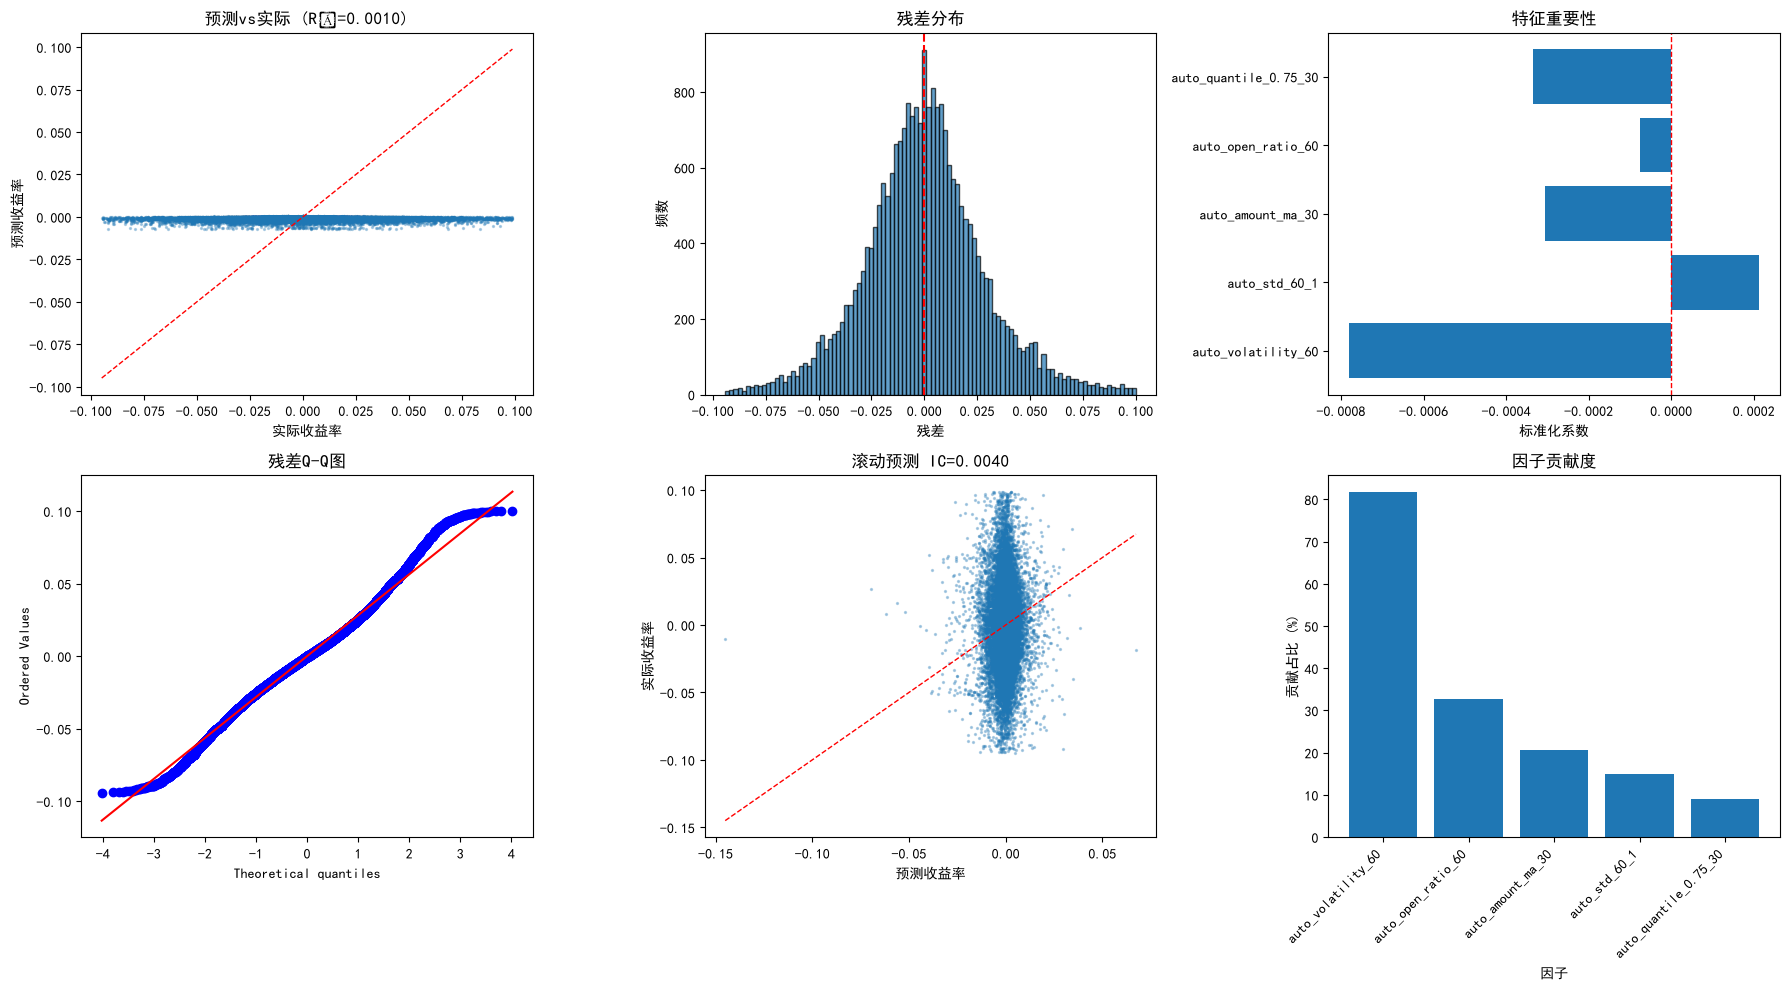


6. 模型诊断总结

回归模型诊断报告

一、模型整体表现:
- R²: 0.001020 (解释0.10%的收益率变化)
- 调整后R²: 0.000811
- RMSE: 0.02833208 (日均收益率误差)
- MAE: 0.02143043 (日均收益率绝对误差)

二、特征重要性排名:

  1. auto_volatility_60: -0.000781 (绝对值: 0.000781)
  5. auto_quantile_0.75_30: -0.000335 (绝对值: 0.000335)
  3. auto_amount_ma_30: -0.000305 (绝对值: 0.000305)
  2. auto_std_60_1: 0.000214 (绝对值: 0.000214)
  4. auto_open_ratio_60: -0.000075 (绝对值: 0.000075)

三、交叉验证表现:
- 平均R²: -0.001683 (±0.002157)
- 平均RMSE: 0.02835787

四、因子单独解释力:

  auto_volatility_60: 0.000832 (占组合81.6%)
  auto_open_ratio_60: 0.000334 (占组合32.8%)
  auto_amount_ma_30: 0.000209 (占组合20.5%)
  auto_std_60_1: 0.000152 (占组合14.9%)
  auto_quantile_0.75_30: 0.000093 (占组合9.1%)

五、滚动预测表现:
- 测试R²: -0.028199
- IC: 0.003999
- 预测稳定性: 需改进

六、结论与建议:
1. 模型R²为0.001020，解释能力较弱 
2. 最重要的因子是: auto_volatility_60
3. 建议可考虑加入更多因子
4. 滚动预测IC为0.003999，预测能力较弱



In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 读取数据
file_path = '../extracted_data/selected_factors_with_data1.csv'
df = pd.read_csv(file_path)

# 定义变量
target = 'daily_return'
features = ['auto_volatility_60', 'auto_std_60_1', 'auto_amount_ma_30', 
            'auto_open_ratio_60', 'auto_quantile_0.75_30']

# 检查列是否存在
available_features = [col for col in features if col in df.columns]
available_target = target if target in df.columns else None

if available_target is None:
    print(f"错误: 因变量 '{target}' 不存在")
    print(f"可用列: {df.columns.tolist()}")
    exit()

# 数据清洗
df_clean = df[available_features + [available_target]].dropna()
print(f"数据量: {len(df_clean)}")

# 1. 简单线性回归 (全样本)
print("\n" + "="*60)
print("1. 全样本线性回归结果")
print("="*60)

X = df_clean[available_features]
y = df_clean[available_target]

# 标准化特征
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 拟合模型
lr = LinearRegression()
lr.fit(X_scaled, y)

# 预测
y_pred = lr.predict(X_scaled)

# 计算指标
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"R²: {r2:.6f}")
print(f"MSE: {mse:.8f}")
print(f"RMSE: {rmse:.8f}")
print(f"MAE: {mae:.8f}")

# 显示系数
coef_df = pd.DataFrame({
    '特征': available_features,
    '系数': lr.coef_,
    '系数绝对值': np.abs(lr.coef_)
}).sort_values('系数绝对值', ascending=False)

print("\n特征重要性 (标准化系数):")
print(coef_df.to_string(index=False))

print("\n截距:", lr.intercept_)

# 2. 时间序列交叉验证
print("\n" + "="*60)
print("2. 时间序列交叉验证 (5折滚动)")
print("="*60)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores = {
    'R²': [],
    'RMSE': [],
    'MAE': []
}

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):
    X_train, X_test = X_scaled[train_idx], X_scaled[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # 训练
    model = LinearRegression()
    model.fit(X_train, y_train)
    
    # 预测
    y_pred_cv = model.predict(X_test)
    
    # 评估
    r2_cv = r2_score(y_test, y_pred_cv)
    rmse_cv = np.sqrt(mean_squared_error(y_test, y_pred_cv))
    mae_cv = mean_absolute_error(y_test, y_pred_cv)
    
    cv_scores['R²'].append(r2_cv)
    cv_scores['RMSE'].append(rmse_cv)
    cv_scores['MAE'].append(mae_cv)
    
    print(f"Fold {fold}: R²={r2_cv:.6f}, RMSE={rmse_cv:.8f}, MAE={mae_cv:.8f}")

print("\n交叉验证平均值:")
print(f"R²: {np.mean(cv_scores['R²']):.6f} (±{np.std(cv_scores['R²']):.6f})")
print(f"RMSE: {np.mean(cv_scores['RMSE']):.8f} (±{np.std(cv_scores['RMSE']):.8f})")
print(f"MAE: {np.mean(cv_scores['MAE']):.8f} (±{np.std(cv_scores['MAE']):.8f})")

# 3. 因子收益贡献分析
print("\n" + "="*60)
print("3. 因子收益贡献分析")
print("="*60)

# 计算每个因子的贡献
factor_contributions = {}
for i, feature in enumerate(available_features):
    # 单独使用每个因子进行回归
    X_single = X_scaled[:, i].reshape(-1, 1)
    model_single = LinearRegression()
    model_single.fit(X_single, y)
    y_pred_single = model_single.predict(X_single)
    r2_single = r2_score(y, y_pred_single)
    factor_contributions[feature] = r2_single

# 组合因子的R²
r2_combined = r2_score(y, y_pred)
r2_combined_adj = 1 - (1 - r2_combined) * (len(y) - 1) / (len(y) - len(available_features) - 1)

contribution_df = pd.DataFrame({
    '因子': list(factor_contributions.keys()),
    '单独R²': list(factor_contributions.values()),
    '贡献占比': [v/r2_combined*100 for v in factor_contributions.values()]
}).sort_values('贡献占比', ascending=False)

print(f"组合模型R²: {r2_combined:.6f}")
print(f"调整后R²: {r2_combined_adj:.6f}")
print("\n各因子单独解释力:")
print(contribution_df.to_string(index=False))

# 4. 回测策略模拟 (因子选股)
print("\n" + "="*60)
print("4. 因子选股回测模拟")
print("="*60)

# 假设按日期排序
if 'date' in df.columns:
    df_clean_sorted = df_clean.sort_values('date')
else:
    df_clean_sorted = df_clean  # 假设已按时间顺序

# 滚动预测 - 每个时间点用历史数据预测未来
n_train = 500  # 初始训练样本数
predicted_returns = []
actual_returns = []

for i in range(n_train, len(df_clean_sorted) - 1):
    # 训练数据: 过去n_train个交易日
    train_data = df_clean_sorted.iloc[i-n_train:i]
    X_train_roll = train_data[available_features]
    y_train_roll = train_data[available_target]
    
    # 测试数据: 下一天
    X_test_roll = df_clean_sorted.iloc[i:i+1][available_features]
    y_test_roll = df_clean_sorted.iloc[i:i+1][available_target]
    
    # 标准化
    scaler_roll = StandardScaler()
    X_train_scaled = scaler_roll.fit_transform(X_train_roll)
    X_test_scaled = scaler_roll.transform(X_test_roll)
    
    # 训练预测
    model_roll = LinearRegression()
    model_roll.fit(X_train_scaled, y_train_roll)
    pred = model_roll.predict(X_test_scaled)[0]
    
    predicted_returns.append(pred)
    actual_returns.append(y_test_roll.values[0])

# 转换为数组
predicted_returns = np.array(predicted_returns)
actual_returns = np.array(actual_returns)

# 回测指标
test_r2 = r2_score(actual_returns, predicted_returns)
test_rmse = np.sqrt(mean_squared_error(actual_returns, predicted_returns))
test_mae = mean_absolute_error(actual_returns, predicted_returns)
ic = np.corrcoef(predicted_returns, actual_returns)[0, 1]

print(f"滚动预测结果 (窗口={n_train}):")
print(f"R²: {test_r2:.6f}")
print(f"RMSE: {test_rmse:.8f}")
print(f"MAE: {test_mae:.8f}")
print(f"IC (预测与实际相关系数): {ic:.6f}")

# 5. 可视化
print("\n" + "="*60)
print("5. 可视化分析")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. 预测vs实际散点图
ax1 = axes[0, 0]
ax1.scatter(y, y_pred, alpha=0.3, s=2)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=1)
ax1.set_xlabel('实际收益率')
ax1.set_ylabel('预测收益率')
ax1.set_title(f'预测vs实际 (R²={r2:.4f})')

# 2. 残差分布
ax2 = axes[0, 1]
residuals = y - y_pred
ax2.hist(residuals, bins=100, edgecolor='black', alpha=0.7)
ax2.axvline(0, color='red', linestyle='--')
ax2.set_xlabel('残差')
ax2.set_ylabel('频数')
ax2.set_title('残差分布')

# 3. 特征系数
ax3 = axes[0, 2]
ax3.barh(available_features, lr.coef_)
ax3.axvline(0, color='red', linestyle='--', lw=1)
ax3.set_xlabel('标准化系数')
ax3.set_title('特征重要性')

# 4. Q-Q图 (检验残差正态性)
ax4 = axes[1, 0]
from scipy import stats
stats.probplot(residuals, dist="norm", plot=ax4)
ax4.set_title('残差Q-Q图')

# 5. 滚动预测表现
ax5 = axes[1, 1]
ax5.scatter(predicted_returns, actual_returns, alpha=0.3, s=2)
ax5.plot([predicted_returns.min(), predicted_returns.max()], 
         [predicted_returns.min(), predicted_returns.max()], 'r--', lw=1)
ax5.set_xlabel('预测收益率')
ax5.set_ylabel('实际收益率')
ax5.set_title(f'滚动预测 IC={ic:.4f}')

# 6. 因子贡献
ax6 = axes[1, 2]
ax6.bar(contribution_df['因子'], contribution_df['贡献占比'])
ax6.set_xlabel('因子')
ax6.set_ylabel('贡献占比 (%)')
ax6.set_title('因子贡献度')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
# plt.savefig('regression_analysis_results.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. 模型诊断
print("\n" + "="*60)
print("6. 模型诊断总结")
print("="*60)

print(f"""
回归模型诊断报告
{'='*60}

一、模型整体表现:
- R²: {r2:.6f} (解释{100*r2:.2f}%的收益率变化)
- 调整后R²: {r2_combined_adj:.6f}
- RMSE: {rmse:.8f} (日均收益率误差)
- MAE: {mae:.8f} (日均收益率绝对误差)

二、特征重要性排名:
""")

for i, row in coef_df.iterrows():
    print(f"  {i+1}. {row['特征']}: {row['系数']:.6f} (绝对值: {row['系数绝对值']:.6f})")

print(f"""
三、交叉验证表现:
- 平均R²: {np.mean(cv_scores['R²']):.6f} (±{np.std(cv_scores['R²']):.6f})
- 平均RMSE: {np.mean(cv_scores['RMSE']):.8f}

四、因子单独解释力:
""")

for _, row in contribution_df.iterrows():
    print(f"  {row['因子']}: {row['单独R²']:.6f} (占组合{row['贡献占比']:.1f}%)")

print(f"""
五、滚动预测表现:
- 测试R²: {test_r2:.6f}
- IC: {ic:.6f}
- 预测稳定性: {'较好' if test_r2 > 0 else '需改进'}

六、结论与建议:
1. 模型R²为{r2:.6f}，{'解释能力较好' if r2 > 0.1 else '解释能力较弱'} 
2. 最重要的因子是: {coef_df.iloc[0]['特征']}
3. 建议{'可考虑加入更多因子' if r2 < 0.1 else '当前模型可用'}
4. 滚动预测IC为{ic:.6f}，{'预测能力较强' if abs(ic) > 0.05 else '预测能力较弱'}
""")